In [83]:
!pip install astropy --upgrade
!pip install photutils

import numpy as np
import math
import matplotlib.pyplot as plt
import os
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
import glob
import warnings
warnings.filterwarnings("ignore")
from matplotlib.gridspec import GridSpec

In [84]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import os

Mounted at /content/drive


In [85]:
fl = glob.glob('drive/MyDrive/Astro_Data/*FLAT*.fits')

for fn in fl:
  print(fn)
  for ii in range(4):
    try:
      X = fits.getdata(fn, 1+ii)
      print(X.shape)
    except:
      print(f"Error with {fn}")
      continue

drive/MyDrive/Astro_Data/0015.FLAT.fits
Error with drive/MyDrive/Astro_Data/0015.FLAT.fits
Error with drive/MyDrive/Astro_Data/0015.FLAT.fits
Error with drive/MyDrive/Astro_Data/0015.FLAT.fits
Error with drive/MyDrive/Astro_Data/0015.FLAT.fits
drive/MyDrive/Astro_Data/0017.FLAT.fits
Error with drive/MyDrive/Astro_Data/0017.FLAT.fits
Error with drive/MyDrive/Astro_Data/0017.FLAT.fits
Error with drive/MyDrive/Astro_Data/0017.FLAT.fits
Error with drive/MyDrive/Astro_Data/0017.FLAT.fits
drive/MyDrive/Astro_Data/0014.FLAT.fits
Error with drive/MyDrive/Astro_Data/0014.FLAT.fits
Error with drive/MyDrive/Astro_Data/0014.FLAT.fits
Error with drive/MyDrive/Astro_Data/0014.FLAT.fits
Error with drive/MyDrive/Astro_Data/0014.FLAT.fits
drive/MyDrive/Astro_Data/0012.FLAT.fits
Error with drive/MyDrive/Astro_Data/0012.FLAT.fits
Error with drive/MyDrive/Astro_Data/0012.FLAT.fits
Error with drive/MyDrive/Astro_Data/0012.FLAT.fits
Error with drive/MyDrive/Astro_Data/0012.FLAT.fits
drive/MyDrive/Astro_Data

Reading in the bias frames now
Created the master bias
Reading in the flat frames now


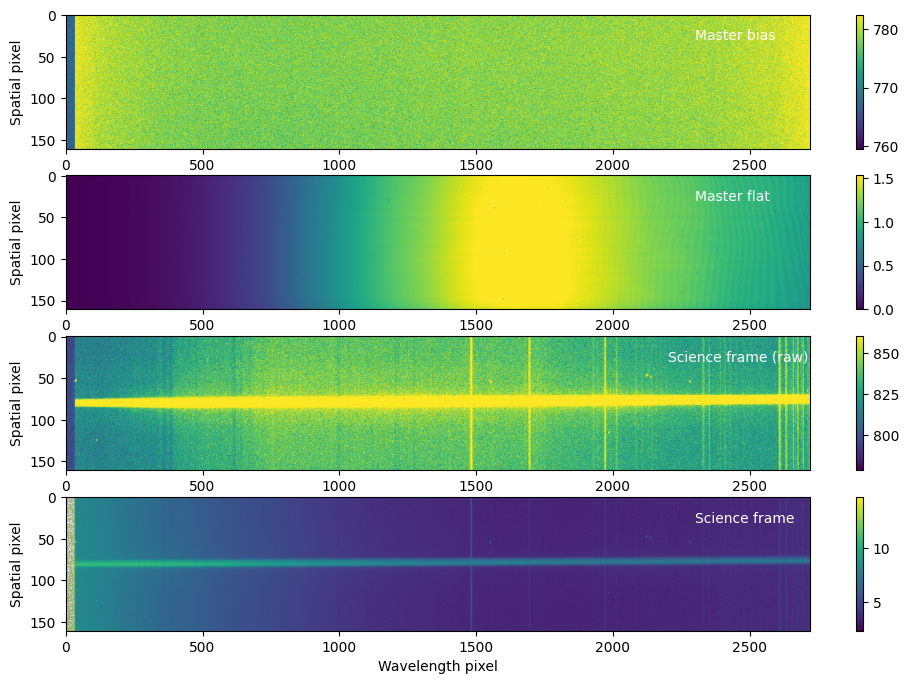

In [86]:
fl = glob.glob('drive/MyDrive/Astro_Data/*BIAS*.fits')# Obtain 2d spectra

master_bias = []

print("Reading in the bias frames now")
for fn in fl:
  data = fits.getdata(fn)
  master_bias.append(data[None])

master_bias = np.concatenate(master_bias, axis=0)
master_bias = np.median(master_bias, axis=0)
print("Created the master bias")

fl = glob.glob('drive/MyDrive/Astro_Data/*FLAT*.fits')

master_flat = []

print("Reading in the flat frames now")

for fn in fl:
  data = fits.getdata(fn)
  data = data - master_bias
  master_flat.append(data[None])

master_flat = np.concatenate(master_flat, axis=0)
master_flat = np.median(master_flat, axis=0)
master_flat = master_flat / np.median(master_flat)

fig = plt.figure(figsize=(12,8))

plt.subplot(411)
plt.imshow(master_bias, aspect='auto', vmax=np.percentile(master_bias, 90))
plt.colorbar()
plt.text(2300, 30, 'Master bias', color='white')
plt.ylabel('Spatial pixel')

plt.subplot(412)
plt.imshow(master_flat, aspect='auto', vmax=np.percentile(master_flat, 90))
plt.colorbar()
plt.text(2300, 30, 'Master flat', color='white')
plt.ylabel('Spatial pixel')

plt.subplot(413)
fl = glob.glob('drive/MyDrive/Astro_Data/*BDp332642*.fits')
fn = fl[0]
data = fits.getdata(fn)
plt.imshow(data, aspect='auto', vmax=np.percentile(data, 90))
plt.text(2200, 30, 'Science frame (raw)', color='white')
plt.colorbar()
plt.ylabel('Spatial pixel')

plt.subplot(414)
data = data - master_bias
data = data / master_flat

plt.imshow(np.log(data), aspect='auto', )
plt.xlabel('Wavelength pixel')
plt.ylabel('Spatial pixel')
plt.text(2300, 30, 'Science frame', color='white')
plt.colorbar()

[]

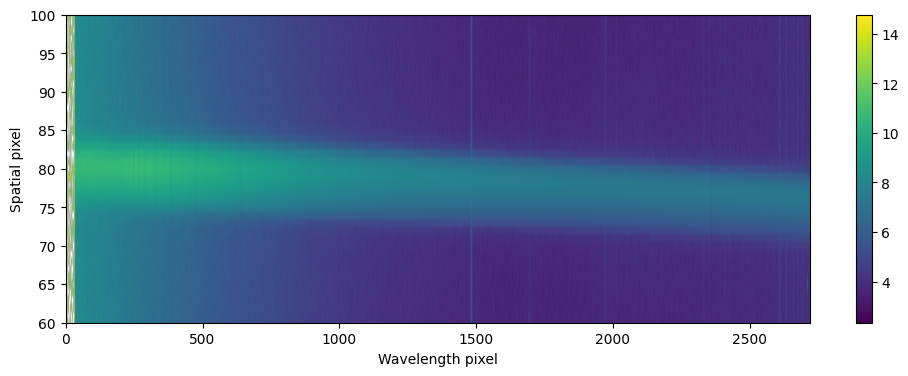

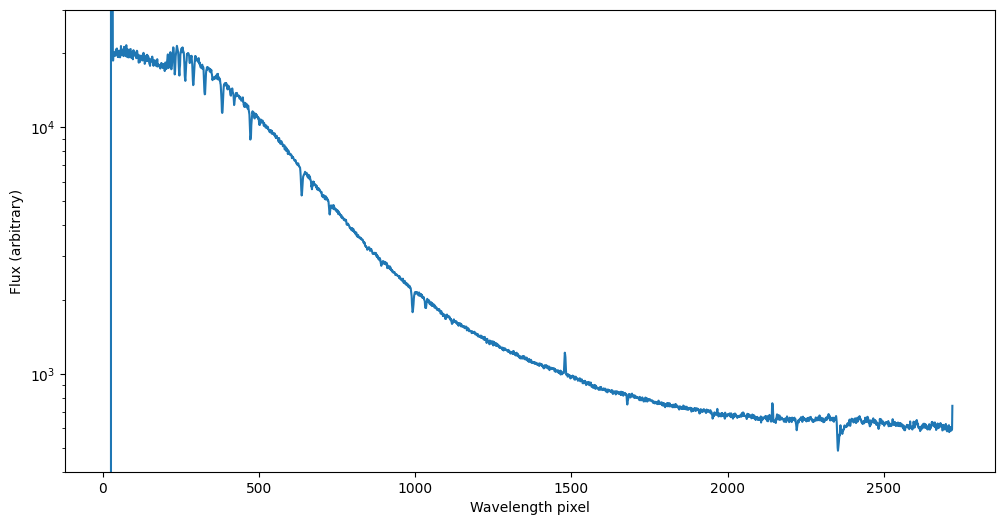

In [87]:
fig = plt.figure(figsize=(12,4))
plt.imshow(np.log(data), aspect='auto', )
plt.ylim(60, 100)
plt.xlabel('Wavelength pixel')
plt.ylabel('Spatial pixel')
plt.colorbar()

plt.figure(figsize=(12,6))
plt.plot(data[73:84].mean(0))
plt.xlabel('Wavelength pixel')
plt.ylabel('Flux (arbitrary)')
plt.ylim(4e2, 3e4)
plt.semilogy()             #Extract 1D spectra

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from scipy.interpolate import interp1d


In [89]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.visualization import astropy_mpl_style
from os import listdir
from scipy.ndimage import shift


['0015.FLAT.fits', '0017.FLAT.fits', '0014.FLAT.fits', '0012.FLAT.fits', '0020.FLAT.fits', '0019.FLAT.fits', '0021.FLAT.fits', '0011.FLAT.fits', '0018.FLAT.fits', '0013.FLAT.fits', '0016.FLAT.fits']
Matched bias files: ['0002.BIAS.fits', '0004.BIAS.fits', '0010.BIAS.fits', '0005.BIAS.fits', '0008.BIAS.fits', '0007.BIAS.fits', '0006.BIAS.fits', '0009.BIAS.fits', '0001.BIAS.fits', '0003.BIAS.fits']
Matched flat files: ['0015.FLAT.fits', '0017.FLAT.fits', '0014.FLAT.fits', '0012.FLAT.fits', '0020.FLAT.fits', '0019.FLAT.fits', '0021.FLAT.fits', '0011.FLAT.fits', '0018.FLAT.fits', '0013.FLAT.fits', '0016.FLAT.fits']
Combined bias shape: (161, 2720)
Combined flat shape: (161, 2720)
All files in directory:
0002.BIAS.fits
0004.BIAS.fits
0010.BIAS.fits
0063.COMP.fits
0062.3C273.fits
0005.BIAS.fits
0069.NGC4151.fits
0015.FLAT.fits
0017.FLAT.fits
0070.COMP.fits
0008.BIAS.fits
0014.FLAT.fits
0012.FLAT.fits
0007.BIAS.fits
0006.BIAS.fits
0048.COMP.fits
0020.FLAT.fits
0019.FLAT.fits
0021.FLAT.fits
00

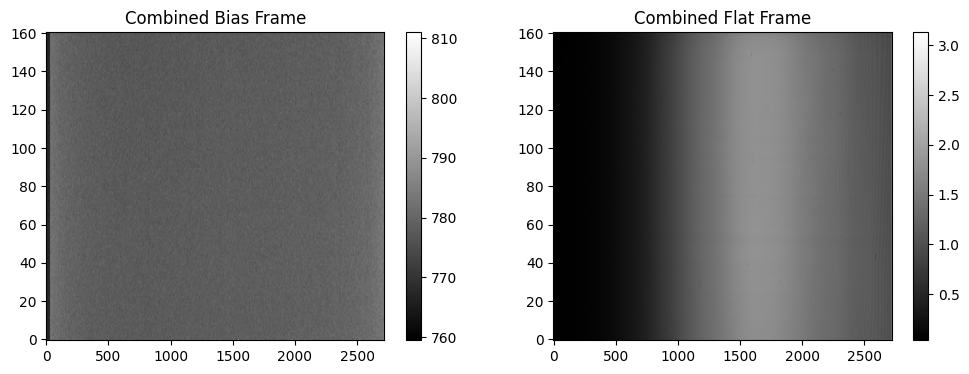

In [90]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Define the directory and file patterns
directory = 'drive/MyDrive/Astro_Data/'
bias_file_pattern = 'BIAS'
flat_file_pattern = 'FLAT'

# Specific file numbers to include
bias_numbers = {'0001','0002','0003', '0004','0005','0006','0007','0008','0009','0010'}
flat_numbers = {'0011','0012','0013','0014', '0015','0016', '0017', '0018','0019','0020','0021'}

# List and filter all files in the directory
all_files = os.listdir(directory)
bias_files = [file for file in all_files if file.split('.')[0] in bias_numbers and 'BIAS' in file]
flat_files = [file for file in all_files if file.split('.')[0] in flat_numbers and 'FLAT' in file]
print(flat_files)

print("Matched bias files:", bias_files)
print("Matched flat files:", flat_files)

# Load and trim the top BIAS files
bias_data = []
for file in bias_files:
    file_path = os.path.join(directory, file)
    with fits.open(file_path) as hdul:
        trimmed_data = hdul[0].data[:, :]  # Trim each bias file
        bias_data.append(trimmed_data)

# Combine all bias data by taking the median
combined_bias = np.median(np.array(bias_data), axis=0)

# Load and combine the top FLAT files, normalized and trimmed
flat_data = []
for file in flat_files:
    file_path = os.path.join(directory, file)
    with fits.open(file_path) as hdul:
        trimmed_flat_data = hdul[0].data[:, :]  # Apply trimming
        flat_data.append(trimmed_flat_data / np.mean(trimmed_flat_data))

# Combine all flat data by taking the median
combined_flat = np.median(np.array(flat_data), axis=0)

# Combine all flat data by taking the median across the array
combined_flat = np.median(np.array(flat_data), axis=0)

# Prepare pixel range for trimmed data
pixels = np.arange(0, combined_flat.shape[-1])

# Calculate the mean flat for polynomial fitting
mean_flat = np.mean(combined_flat, axis=0)

# Iteratively find the best polynomial degree (without weighting)
min_residual = np.inf
best_degree = 0

for degree in range(1, 10):  # Test polynomial degrees from 1 to 9
    p = np.polynomial.Polynomial.fit(pixels, mean_flat, degree)
    poly_fit = p(pixels)
    residual = np.sum((mean_flat - poly_fit) ** 2)  # Sum of squared residuals

    if residual < min_residual:
        min_residual = residual
        best_degree = degree

# Use the best degree found
p_best = np.polynomial.Polynomial.fit(pixels, mean_flat, best_degree)
poly_fit_best = p_best(pixels)

# Normalize the flat field
normalized_flat = combined_flat / (mean_flat / poly_fit_best)


# Function to process science images with bias subtraction, flat correction, and trimming
def process_science_image(science_file, combined_bias, combined_flat):
    with fits.open(science_file) as hdul:
        # Trim the science image to match the bias and flat dimensions
        science_image = hdul[0].data[:, :]

        # Subtract bias and apply flat-field correction
        bias_subtracted_image = science_image - combined_bias
        flat_corrected_image = bias_subtracted_image / combined_flat

        return flat_corrected_image, science_image


# Visualization for combined bias and flat frames
def plot_bias_and_flat(combined_bias, combined_flat):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(combined_bias, cmap='gray', origin='lower', aspect='auto')
    plt.colorbar()
    plt.title('Combined Bias Frame')

    plt.subplot(1, 2, 2)
    plt.imshow(combined_flat, cmap='gray', origin='lower', aspect='auto')
    plt.colorbar()
    plt.title('Combined Flat Frame')

    plt.show()


# Function to raw plot 1D spectrum from a specific region in the image
def plot_1d_spectrum_raw(image_data, y_start=80, y_end=88):
    spectrum_1d = np.sum(image_data[y_start:y_end], axis=0)

    # Plot the extracted 1D spectrum
    plt.figure(figsize=(10, 4))
    plt.plot(np.arange(len(spectrum_1d)), spectrum_1d, color='black')
    plt.title('Extracted 1D Spectrum')
    plt.xlabel('X Pixel')
    plt.ylabel('Summed Intensity')
    plt.show()

# Function to plot 1D spectrum from a specific region in the image
def plot_1d_spectrum(image_data, y_start=80, y_end=88):
    spectrum_1d = np.sum(image_data[y_start:y_end], axis=0)

    # Plot the 2D science image with highlighted region
    plt.figure(figsize=(12, 4))
    plt.imshow(image_data, cmap='gray', origin='lower', aspect='auto')
    plt.colorbar(label='Intensity')
    plt.axhline(y=y_start, color='red', linestyle='--', label='Extraction Start')
    plt.axhline(y=y_end, color='red', linestyle='--', label='Extraction End')
    plt.title('Science Image with Spectrum Extraction Region')
    plt.xlabel('X Pixel')
    plt.ylabel('Y Pixel')
    plt.ylim(78,100)
    plt.legend()
    plt.show()

    # Plot the extracted 1D spectrum
    plt.figure(figsize=(10, 5))
    plt.plot(np.arange(len(spectrum_1d)), spectrum_1d, color='black')
    plt.title('Extracted 1D Spectrum')
    plt.xlabel('X Pixel')
    plt.ylabel('Summed Intensity')
    plt.show()

# Function to visualize raw and corrected science images
def plot_science_images(raw_image, corrected_image):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(raw_image, cmap='gray', origin='lower', aspect='auto')
    plt.colorbar()
    plt.ylim(80,100)
    plt.title('Raw Science Image')

    plt.subplot(1, 2, 2)
    plt.imshow(corrected_image, cmap='gray', origin='lower', aspect='auto')
    plt.colorbar()
    plt.ylim(80,100)
    plt.title('Corrected Science Image')

    plt.show()

science_file = os.path.join("drive/MyDrive/Astro_Data/0074.BDp332642.fits")

print("Combined bias shape:", combined_bias.shape)
print("Combined flat shape:", combined_flat.shape)

print("All files in directory:")
for file in all_files:
    print(file)

plot_bias_and_flat(combined_bias, combined_flat)

# corrected_science_image, raw_science_image = process_science_image(science_file, combined_bias, combined_flat)
# plot_science_images(raw_science_image, corrected_science_image)


Viewing FITS file: drive/MyDrive/Astro_Data/0092.COMP.fits
Header:
SIMPLE  =                    T / Primary FITS image array                       
BITPIX  =                   16                                                  
NAXIS   =                    2 / NUMBER OF AXES                                 
NAXIS1  =                 2720 / CHIP WIDTH                                     
NAXIS2  =                  161 / CHIP HEIGHT                                    
EXTEND  =                    F / Fits standard                                  
OBJECT  = 'COMP              ' / OBJECT NAME                                    
NAMPS   =                    1                                                  
DATE    = '2025-03-20T12:06:12' / UT date/time at start                         
DATE-OBS= '2025-03-20        ' / UT date/time at start                          
RA      = '14:17:59.5        ' / RA                                             
DEC     = '25:08:12.45       ' / DEC     

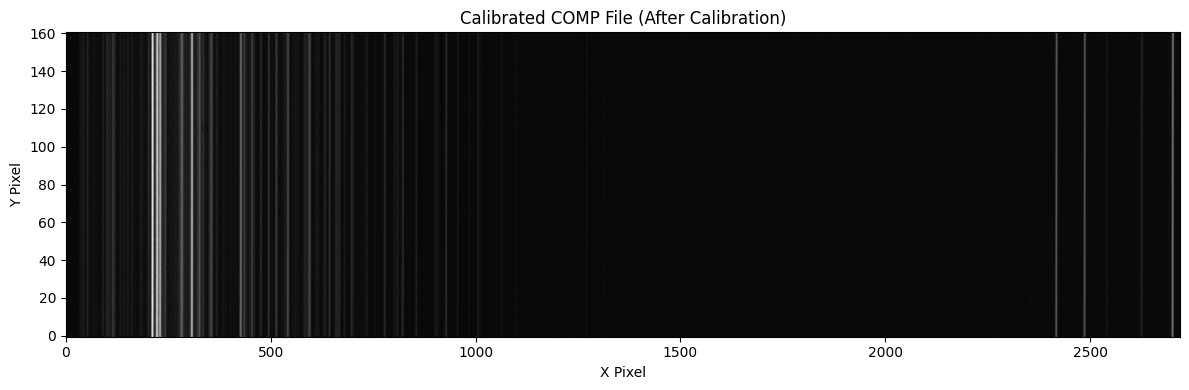

In [91]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.signal import find_peaks

# Define the directory and specific file
directory = 'drive/MyDrive/Astro_Data/'
comp_file = '0092.COMP.fits'  # Specify the COMP file you want to process

# Load the COMP file (before calibration)
comp_file_path = os.path.join(directory, comp_file)
with fits.open(comp_file_path) as hdul:
    comp_data_raw = hdul[0].data

    print(f"\nViewing FITS file: {comp_file_path}")
    print("Header:")
    print(repr(hdul[0].header))
    print("\nData shape:")
    print(hdul[0].data.shape)

# Trim the raw data (same trimming as for bias and flat)
comp_data_trimmed = comp_data_raw[:, :]

# Normalize and subtract bias (using combined bias data)
bias_subtracted_comp = comp_data_trimmed - combined_bias

# Trim both the bias-subtracted COMP data and the normalized flat to match the smaller size
min_width = min(bias_subtracted_comp.shape[1], normalized_flat.shape[1])

bias_subtracted_comp_trimmed = bias_subtracted_comp[:, :min_width]
normalized_flat_trimmed = normalized_flat[:, :min_width]

# Apply flat correction (normalize by combined flat)
calibrated_comp = bias_subtracted_comp_trimmed / normalized_flat_trimmed

# Plot the raw, trimmed, and calibrated COMP image
fig, axs = plt.subplots(1, 1, figsize=(12, 4))

# Display the calibrated COMP file
axs.imshow(calibrated_comp, cmap='gray', origin='lower', aspect='auto')
axs.set_title('Calibrated COMP File (After Calibration)')
axs.set_xlabel('X Pixel')
axs.set_ylabel('Y Pixel')

plt.tight_layout()
plt.show()

# Create a 1D spectrum by summing over the spatial dimension (Y-axis)
comp_spectrum_1d = np.sum(calibrated_comp, axis=0)



30


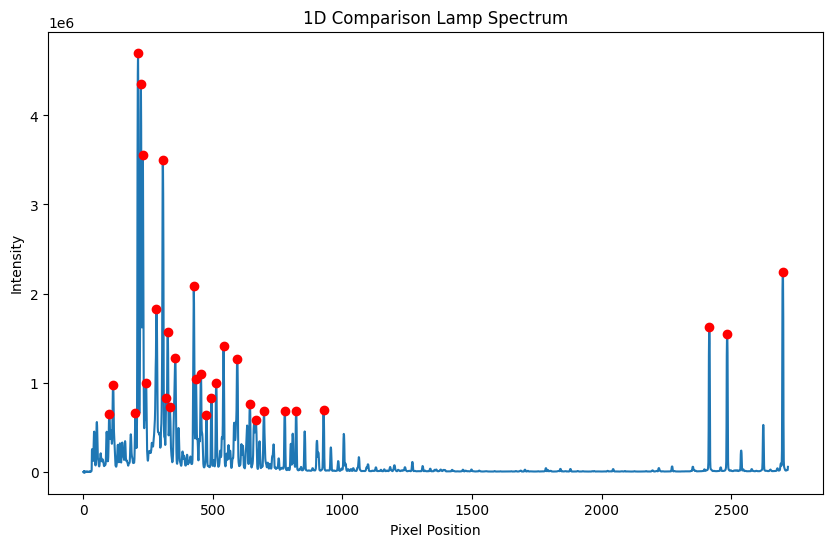

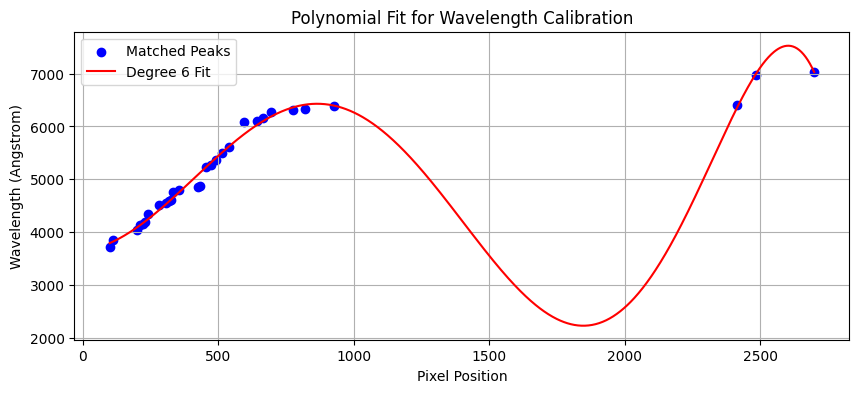

In [92]:
from numpy.polynomial import Polynomial
from scipy.signal import find_peaks

peaks, properties = find_peaks(comp_spectrum_1d)

# Sort peaks by intensity and select the 10 most intense peaks
peak_intensities = properties['peak_heights'] = comp_spectrum_1d[peaks]
top_peaks_idx = np.argsort(peak_intensities)[-30:]  # Indices of the 10 highest peaks
top_peaks = peaks[top_peaks_idx]  # Pixel positions of the 10 highest peaks
top_peaks_intensity = comp_spectrum_1d[top_peaks]  # Intensities of the 10 highest peaks

sorted_peak_pixels = np.sort(top_peaks)

# known wavelengths in Angstroms
wavelengths = np.array([
3719.935, 3859.400, 4045.450,4131.830, 4158.590, 4199.860, 4348.064,4510.733,
4545.080, 4589.900, 4609.560,4764.890, 4806.070,4847.820,4879.900, 5227.300,
5269.650,5371.489,5496.210, 5606.732,6074.338,6096.1630,6163.594,6266.495,
6304.850,6334.428,6382.991 ,6402.246,6965.4300,7032.4127
])

sorted_known_wavelengths = np.sort(wavelengths)

print(len(sorted_peak_pixels))


# Plot the 1D comparison spectrum with the 10 most intense peaks marked
plt.figure(figsize=(10, 6))
plt.plot(comp_spectrum_1d, label='Comparison Spectrum')
plt.plot(top_peaks, top_peaks_intensity, 'ro', label='Top 10 Intense Peaks')
plt.xlabel('Pixel Position')
plt.ylabel('Intensity')
plt.title('1D Comparison Lamp Spectrum')



# 3. Fit a polynomial (linear or quadratic depending on distortion)
fit_poly = Polynomial.fit(sorted_peak_pixels, sorted_known_wavelengths, deg=6)  # Use deg=2 if needed

# 4. Apply the mapping to convert pixels to wavelengths
pixel_indices = np.arange(len(comp_spectrum_1d))
calibrated_wavelengths = fit_poly(pixel_indices)

plt.figure(figsize=(10, 4))

# Scatter of known data points
plt.scatter(sorted_peak_pixels, sorted_known_wavelengths, color='blue', label='Matched Peaks')

# Polynomial fit curve
x_fit = np.linspace(min(sorted_peak_pixels), max(sorted_peak_pixels), 1000)
y_fit = fit_poly(x_fit)
plt.plot(x_fit, y_fit, color='red', label=f'Degree {fit_poly.degree()} Fit')

plt.xlabel("Pixel Position")
plt.ylabel("Wavelength (Angstrom)")
plt.title("Polynomial Fit for Wavelength Calibration")
plt.grid(True)
plt.legend()
plt.show()


In [93]:
def plot_wavelength_pixel_solution(
    spectrum, pixel_positions, wavelength_values, wavelength_labels=None, annotate=True,
    figsize=(12, 5), invert_x=False, xlim=None, ylim=None
):

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(spectrum*150, label='1D Spectrum')
    ax.set_xlabel("Pixel Position")
    ax.set_ylabel("Intensity")
    ax.set_title("1D Spectrum with Known Line Positions")
    ax.grid(True)

    for i, pix in enumerate(pixel_positions):
        wl = wavelength_values[i]
        label = f"{wl:.1f} "
        if wavelength_labels is not None:
            label += f" ({wavelength_labels[i]})"
        ax.axvline(pix, color='red', linestyle='--', alpha=0.5)
        if annotate:
            ax.text(pix, spectrum[int(pix)] -2000000, label,
                    rotation=90, ha='right', va='bottom', fontsize=12, color='red')

    if invert_x:
        ax.invert_xaxis()
    if xlim:
        ax.set_xlim(*xlim)
    if ylim:
        ax.set_ylim(*ylim)

    plt.tight_layout()
    plt.show()


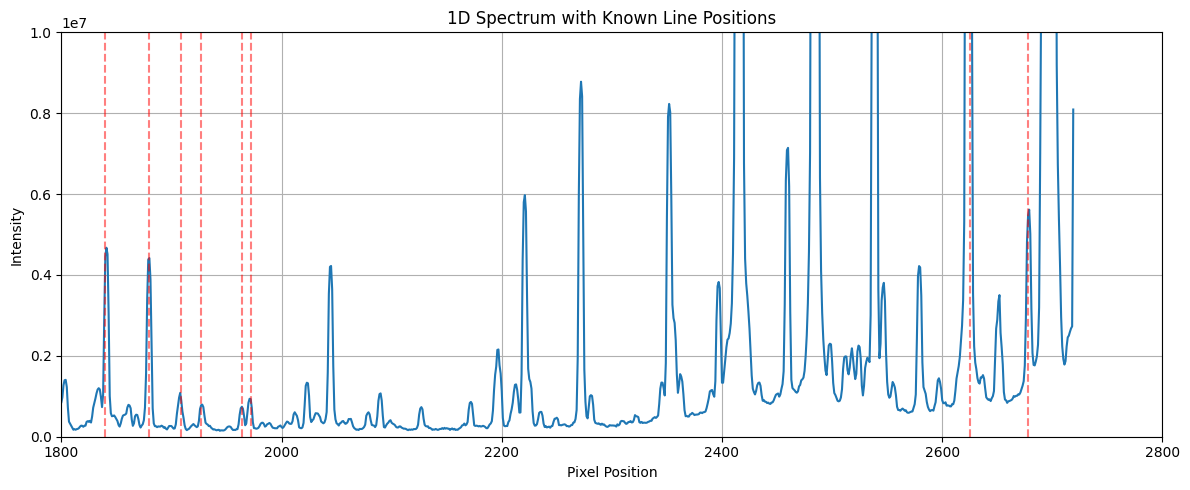

In [94]:
pixels_solution = np.array([210, 306, 435, 495, 512,540, 643,755,777,808,822,927,955,985,1005,1240,1270,1338,1422,
                            1497,1785, 1793,1840,1880,1909,1927,1964,1972,2625,2678])
wavelength_solution = np.array([3719.935, 3859.400, 4045.450,4131.830, 4158.590, 4199.860, 4348.064,4510.733,
                                4545.080, 4589.900, 4609.560,4764.890, 4806.070,4847.820,4879.900, 5227.300,
                                5269.650,5371.489,5496.210, 5606.732,6074.338,6096.1630,6163.594,6266.495,
                               6304.850,6334.428,6382.991 ,6402.246,6965.4300,7032.4127 ])#7383.980, 7514.651])
wavelength_label = np.array(["FeI", "FeI", "FeI" ,"ArII","ArI", "ArI","FeI", "ArII", "ArII", "AII","AII","AII","AII",
                             "AII","AII","AII", "AII","FeI","FeI","FeI", "AI","NeI","NeI","NeI","NeI","NeI","NeI",
                            "NeI","NeI","AI"])

plot_wavelength_pixel_solution(
    comp_spectrum_1d,
    pixels_solution,
    wavelength_solution,
    wavelength_labels=wavelength_label,
    annotate=False,
    invert_x=False,
    xlim=(1800,2800),
    ylim=(0,10e6)
)


Polynomial coefficients: [-1.68082161e-07  6.07623135e-04  8.74859751e-01  3.55690971e+03]


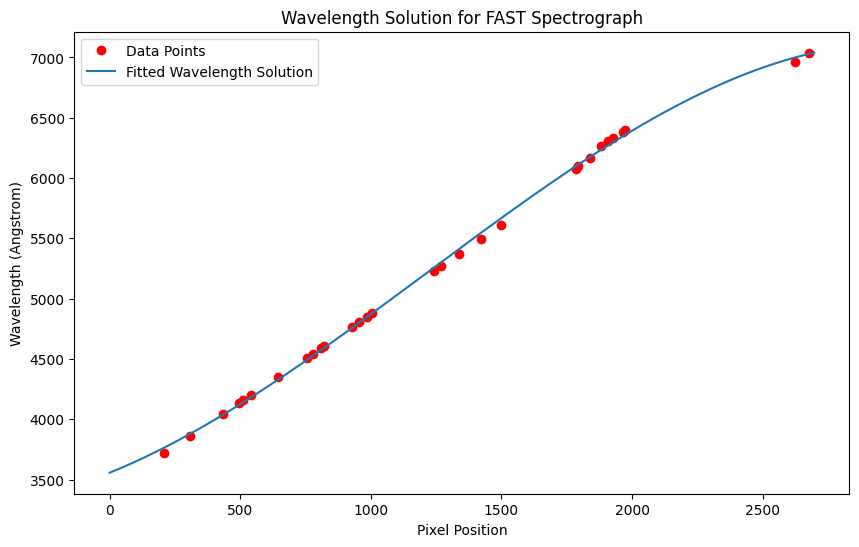

In [95]:
# Define a polynomial function to fit the data
from scipy.optimize import curve_fit

def polynomial(x, a, b, c, d):
    return  a * x**3 + b * x**2 + c * x + d

# Fit the polynomial to the data
popt, pcov = curve_fit(polynomial, pixels_solution, wavelength_solution,)
a, b, c, d = popt

# Print out the polynomial coefficients
print("Polynomial coefficients:", popt)

# Generate wavelengths using the polynomial solution across the full pixel range
pixel_range = np.arange(0, max(pixels_solution) +20)
calibrated_wavelengths = polynomial(pixel_range, *popt)

# Plot the original data points and the fitted polynomial solution
plt.figure(figsize=(10, 6))
plt.plot(pixels_solution, wavelength_solution, 'ro', label='Data Points')
plt.plot(pixel_range, calibrated_wavelengths, label='Fitted Wavelength Solution')
plt.xlabel('Pixel Position')
plt.ylabel('Wavelength (Angstrom)')
plt.title('Wavelength Solution for FAST Spectrograph')
plt.legend()
plt.show()

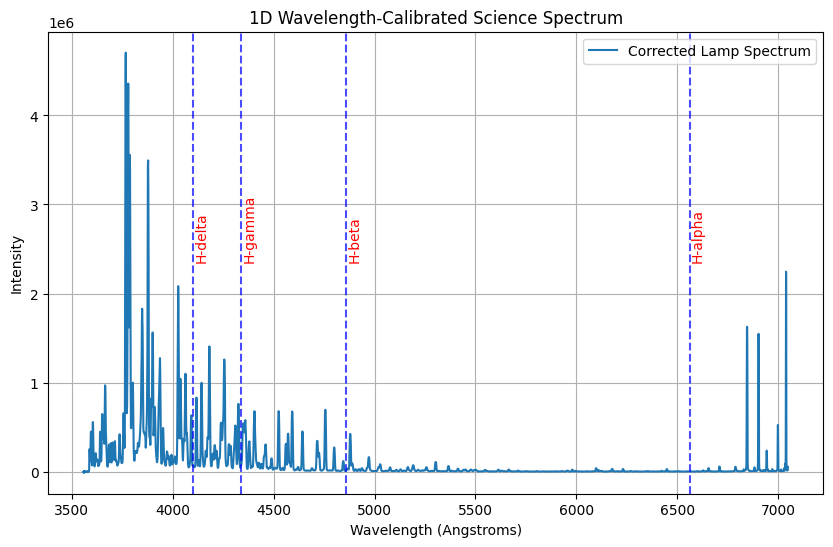

In [96]:
coeffs = [-1.68082148e-07, 6.07623080e-04, 8.74859821e-01, 3.55690968e+03]  # Replace a, b, c, d with the values from your polynomial fit

def apply_wavelength_solution(pixels, coeffs):
    return np.polyval(coeffs, pixels)



science_file = os.path.join("drive/MyDrive/Astro_Data/0074.BDp332642.fits")

corrected_science_image, raw_science_image = process_science_image(science_file, combined_bias, combined_flat)
science_spectrum_1d = np.sum(corrected_science_image, axis=0)
pixels = np.arange(len(comp_spectrum_1d))

wavelength_solution_adjusted = apply_wavelength_solution(pixels, coeffs)
wavelength_solution_adjusted_science = apply_wavelength_solution(pixels, coeffs)

# Define only the H-alpha spectral line
lines = {
    'H-alpha': 6563,
    'H-beta': 4861,
    'H-gamma': 4340,
    'H-delta': 4101
}

def plot_1d_spectrum_with_lines(wavelengths, spectrum_1d):
    plt.figure(figsize=(10, 6))

    # Plot the 1D spectrum
    plt.plot(wavelengths, spectrum_1d, label='Corrected Lamp Spectrum')
    plt.xlabel('Wavelength (Angstroms)')
    plt.ylabel('Intensity')
    plt.title('1D Wavelength-Calibrated Science Spectrum')
    plt.grid(True)

    # Plot the vertical line for the H-alpha line
    for line_name, line_wavelength in lines.items():
        plt.axvline(x=line_wavelength, color='blue', linestyle='--', alpha=0.7)
        plt.text(line_wavelength +5, np.max(spectrum_1d) * 0.5, line_name, rotation=90, verticalalignment='bottom', color='red')

    plt.legend()
    plt.show()

# Plot the 1D spectrum with only the H-alpha line using the wavelength solution
plot_1d_spectrum_with_lines(wavelength_solution_adjusted, comp_spectrum_1d)

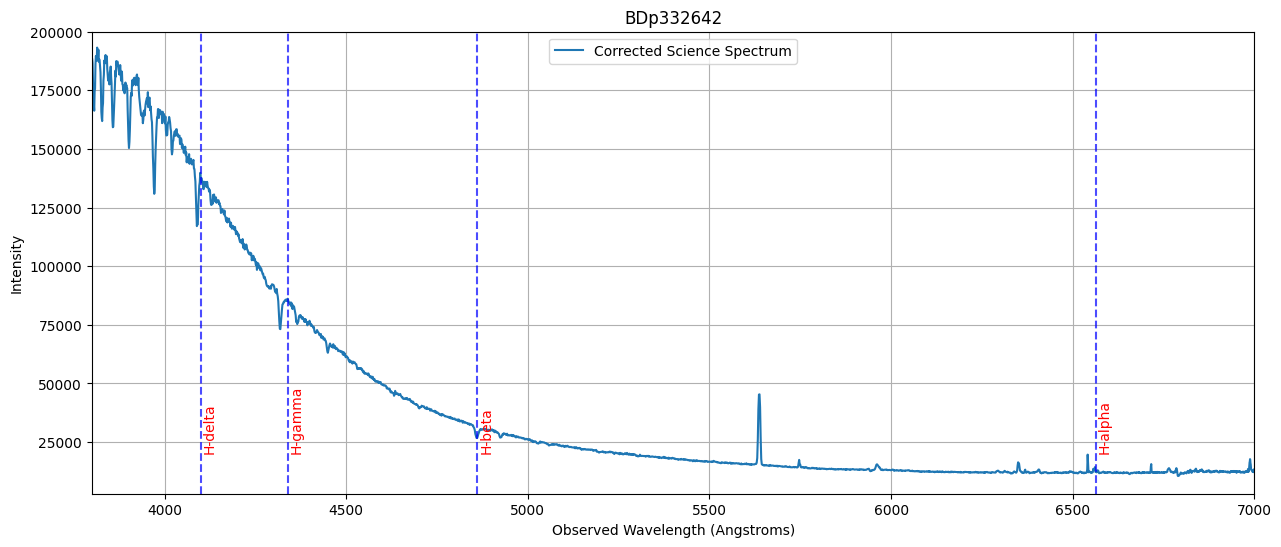

In [97]:
def plot_1d_spectrum_with_lines(wavelengths, spectrum_1d):
    plt.figure(figsize=(15, 6))

    # Plot the 1D spectrum
    plt.plot(wavelengths, spectrum_1d, label='Corrected Science Spectrum')
    plt.xlabel('Observed Wavelength (Angstroms)')
    plt.ylabel('Intensity')
    plt.title('BDp332642')
    plt.grid(True)

    # Plot the vertical lines for emission/absorption lines
    for line_name, line_wavelength in lines.items():
        plt.axvline(x=line_wavelength, color='blue', linestyle='--', alpha=0.7)
        plt.text(line_wavelength + 5, 20000, line_name, rotation=90,
                 verticalalignment='bottom', color='red')  # 20000 = halfway between 0 and 40000

    plt.ylim(3000, 200000)
    plt.xlim(3800, 7000)
    plt.legend()
    plt.show()

# Call the function
plot_1d_spectrum_with_lines(wavelength_solution_adjusted_science, science_spectrum_1d)

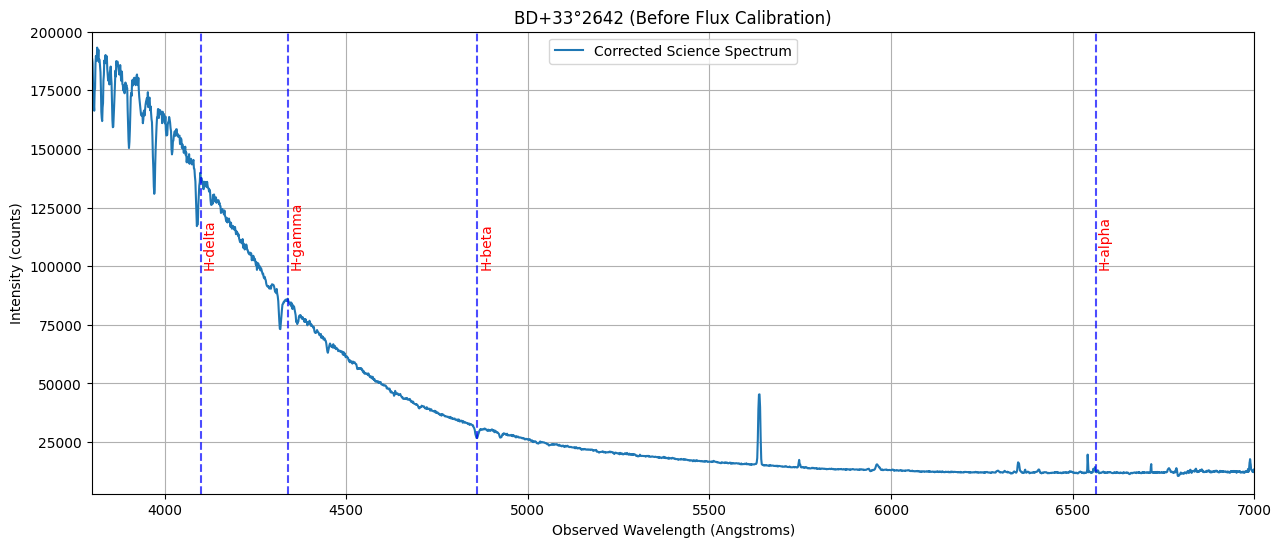

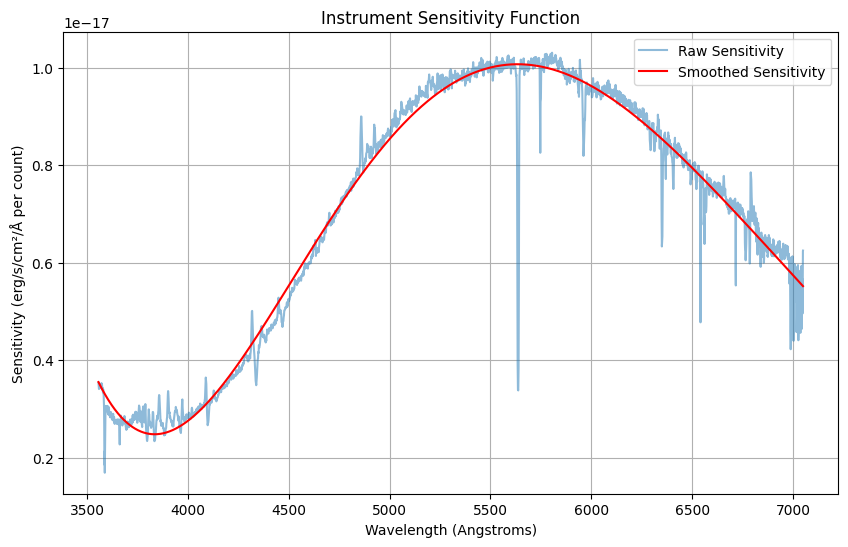

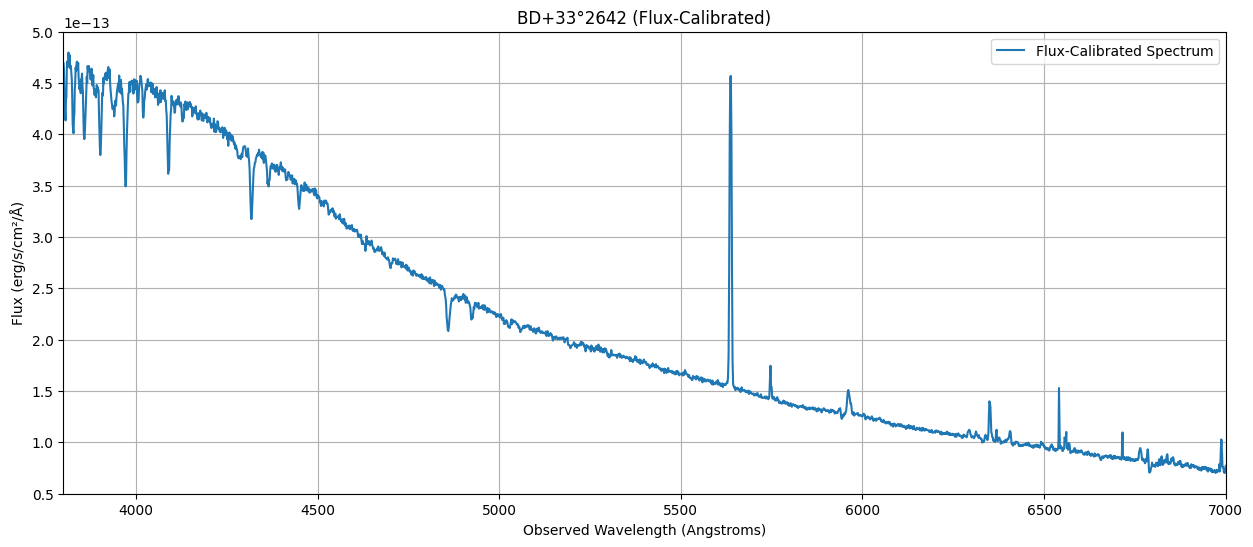

In [98]:
import numpy as np
import matplotlib.pyplot as plt
import os
from astropy.io import fits
from scipy.interpolate import interp1d

# Wavelength Calibration Coefficients ---
coeffs = [-1.68082148e-07, 6.07623080e-04, 8.74859821e-01, 3.55690968e+03]

def apply_wavelength_solution(pixels, coeffs):
    return np.polyval(coeffs, pixels)

# Load Science Image ---
science_file = os.path.join("drive/MyDrive/Astro_Data/0074.BDp332642.fits")

corrected_science_image, raw_science_image = process_science_image(science_file, combined_bias, combined_flat)
science_spectrum_1d = np.sum(corrected_science_image, axis=0)
pixels = np.arange(len(science_spectrum_1d))

# Apply wavelength solution
wavelength_solution_adjusted = apply_wavelength_solution(pixels, coeffs)

# Define important lines
lines = {
    'H-alpha': 6563,
    'H-beta': 4861,
    'H-gamma': 4340,
    'H-delta': 4101
}

def plot_1d_spectrum_with_lines(wavelengths, spectrum_1d, title='Spectrum', ylimit=(3000, 200000)):
    plt.figure(figsize=(15, 6))
    plt.plot(wavelengths, spectrum_1d, label='Corrected Science Spectrum')
    plt.xlabel('Observed Wavelength (Angstroms)')
    plt.ylabel('Intensity (counts)')
    plt.title(title)
    plt.grid(True)
    for line_name, line_wavelength in lines.items():
        plt.axvline(x=line_wavelength, color='blue', linestyle='--', alpha=0.7)
        plt.text(line_wavelength + 5, 0.5 * (ylimit[1] - ylimit[0]), line_name,
                 rotation=90, verticalalignment='bottom', color='red')
    plt.ylim(ylimit)
    plt.xlim(3800, 7000)
    plt.legend()
    plt.show()

# Plot your raw science spectrum
plot_1d_spectrum_with_lines(wavelength_solution_adjusted, science_spectrum_1d, title="BD+33°2642 (Before Flux Calibration)")

# Load CALSPEC standard star (BD+33°2642)
calspec_file = 'drive/MyDrive/Astro_Data/bd_33d2642_004.fits'

with fits.open(calspec_file) as hdul:
    calspec_data = hdul[1].data
    cal_wave = calspec_data['WAVELENGTH']  # Angstroms
    cal_flux = calspec_data['FLUX']         # erg/s/cm²/Å

# Interpolate CALSPEC Flux onto your observed wavelengths
calspec_interp = interp1d(cal_wave, cal_flux, bounds_error=False, fill_value="extrapolate")
cal_flux_resampled = calspec_interp(wavelength_solution_adjusted)

# Compute Sensitivity Function
# sensitivity = (known physical flux) / (observed counts)
sensitivity = cal_flux_resampled / science_spectrum_1d

# Remove any NaNs or infs (caused by division by zero if needed)
sensitivity = np.nan_to_num(sensitivity, nan=0.0, posinf=0.0, neginf=0.0)

# Smooth Sensitivity
coeffs_sens = np.polyfit(wavelength_solution_adjusted, sensitivity, deg=5)
sensitivity_smoothed = np.polyval(coeffs_sens, wavelength_solution_adjusted)

#  Plot Sensitivity Curve
plt.figure(figsize=(10,6))
plt.plot(wavelength_solution_adjusted, sensitivity, label='Raw Sensitivity', alpha=0.5)
plt.plot(wavelength_solution_adjusted, sensitivity_smoothed, color='red', label='Smoothed Sensitivity')
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Sensitivity (erg/s/cm²/Å per count)')
plt.title('Instrument Sensitivity Function')
plt.grid(True)
plt.legend()
plt.show()

# Apply Sensitivity to Calibrate Flux
science_flux_calibrated = science_spectrum_1d * sensitivity_smoothed

# Plot Calibrated Spectrum
plt.figure(figsize=(15,6))
plt.plot(wavelength_solution_adjusted, science_flux_calibrated, label='Flux-Calibrated Spectrum')
plt.xlabel('Observed Wavelength (Angstroms)')
plt.ylabel('Flux (erg/s/cm²/Å)')
plt.title('BD+33°2642 (Flux-Calibrated)')
plt.grid(True)
plt.ylim(0.05e-12, 0.5e-12)
plt.xlim(3800, 7000)
plt.legend()
plt.show()


# Save Calibrated Spectrum (Optional)
np.savetxt('flux_calibrated_BDp332642.txt', np.column_stack((wavelength_solution_adjusted, science_flux_calibrated)),
           header='Wavelength (Angstroms)    Flux (erg/s/cm^2/Angstrom)')





Reading in the bias frames now
Created the master bias
Reading in the flat frames now


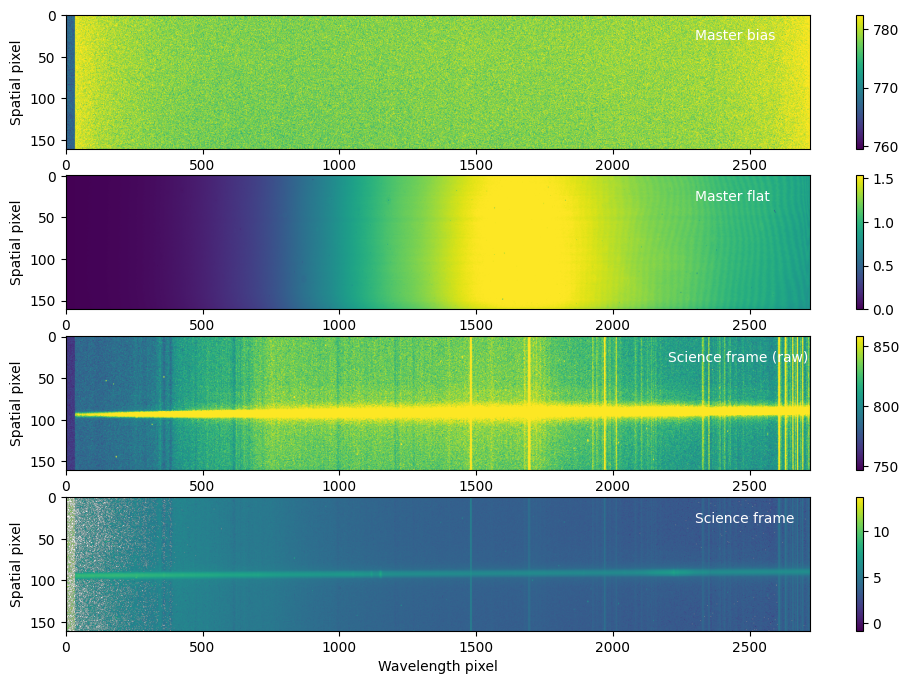

In [99]:
fl = glob.glob('drive/MyDrive/Astro_Data/*BIAS*.fits')

master_bias = []

print("Reading in the bias frames now")
for fn in fl:
  data = fits.getdata(fn)
  master_bias.append(data[None])

master_bias = np.concatenate(master_bias, axis=0)
master_bias = np.median(master_bias, axis=0)
print("Created the master bias")

fl = glob.glob('drive/MyDrive/Astro_Data/*FLAT*.fits')

master_flat = []

print("Reading in the flat frames now")

for fn in fl:
  data = fits.getdata(fn)
  data = data - master_bias
  master_flat.append(data[None])

master_flat = np.concatenate(master_flat, axis=0)
master_flat = np.median(master_flat, axis=0)
master_flat = master_flat / np.median(master_flat)

fig = plt.figure(figsize=(12,8))

plt.subplot(411)
plt.imshow(master_bias, aspect='auto', vmax=np.percentile(master_bias, 90))
plt.colorbar()
plt.text(2300, 30, 'Master bias', color='white')
plt.ylabel('Spatial pixel')

plt.subplot(412)
plt.imshow(master_flat, aspect='auto', vmax=np.percentile(master_flat, 90))
plt.colorbar()
plt.text(2300, 30, 'Master flat', color='white')
plt.ylabel('Spatial pixel')

plt.subplot(413)
fl = glob.glob('drive/MyDrive/Astro_Data/*NGC5548*.fits')
fn = fl[0]
data = fits.getdata(fn)
plt.imshow(data, aspect='auto', vmax=np.percentile(data, 90))
plt.text(2200, 30, 'Science frame (raw)', color='white')
plt.colorbar()
plt.ylabel('Spatial pixel')

plt.subplot(414)
data = data - master_bias
data = data / master_flat

plt.imshow(np.log(data), aspect='auto', )
plt.xlabel('Wavelength pixel')
plt.ylabel('Spatial pixel')
plt.text(2300, 30, 'Science frame', color='white')
plt.colorbar()

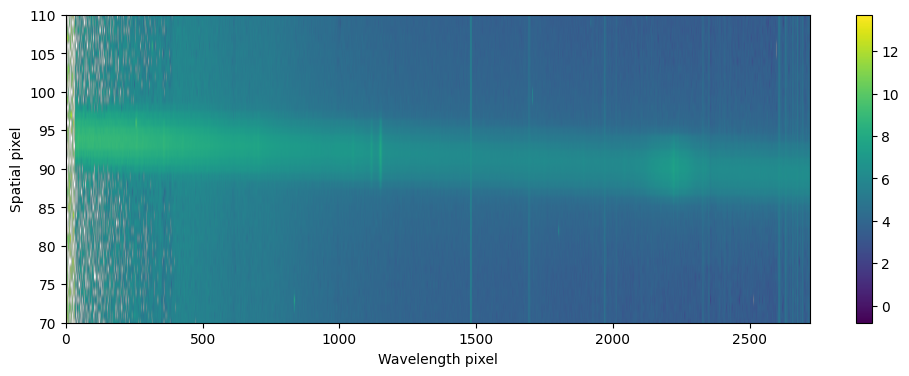

In [100]:
fig = plt.figure(figsize=(12,4))
plt.imshow(np.log(data), aspect='auto', )
plt.ylim(70, 110)
plt.xlabel('Wavelength pixel')
plt.ylabel('Spatial pixel')
plt.colorbar()

[]

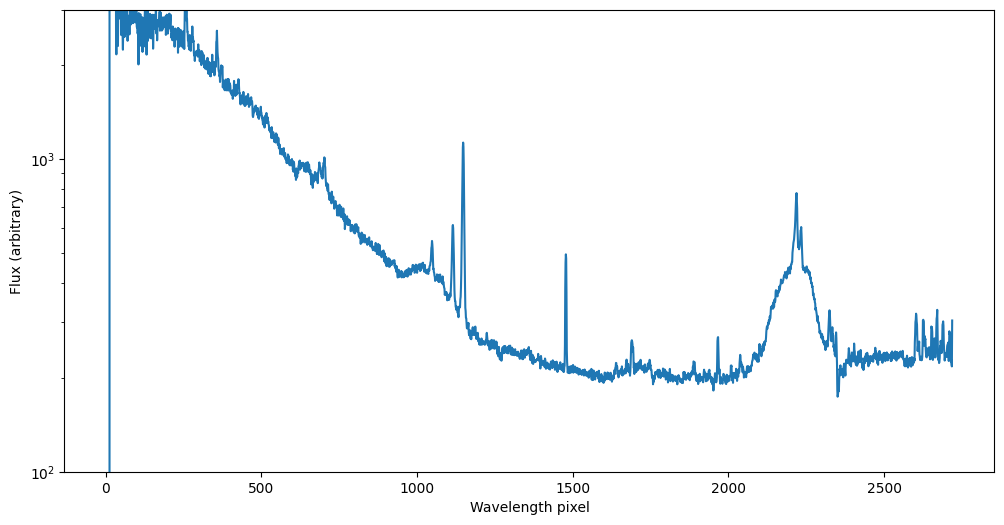

In [101]:
plt.figure(figsize=(12,6))
plt.plot(data[85:98].mean(0))
plt.xlabel('Wavelength pixel')
plt.ylabel('Flux (arbitrary)')
plt.ylim(1e2, 3e3)
plt.semilogy()

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from scipy.interpolate import interp1d


In [103]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.visualization import astropy_mpl_style
from os import listdir
from scipy.ndimage import shift


['0015.FLAT.fits', '0017.FLAT.fits', '0014.FLAT.fits', '0012.FLAT.fits', '0020.FLAT.fits', '0019.FLAT.fits', '0021.FLAT.fits', '0011.FLAT.fits', '0018.FLAT.fits', '0013.FLAT.fits', '0016.FLAT.fits']
Matched bias files: ['0002.BIAS.fits', '0004.BIAS.fits', '0010.BIAS.fits', '0005.BIAS.fits', '0008.BIAS.fits', '0007.BIAS.fits', '0006.BIAS.fits', '0009.BIAS.fits', '0001.BIAS.fits', '0003.BIAS.fits']
Matched flat files: ['0015.FLAT.fits', '0017.FLAT.fits', '0014.FLAT.fits', '0012.FLAT.fits', '0020.FLAT.fits', '0019.FLAT.fits', '0021.FLAT.fits', '0011.FLAT.fits', '0018.FLAT.fits', '0013.FLAT.fits', '0016.FLAT.fits']
Combined bias shape: (161, 2720)
Combined flat shape: (161, 2720)
All files in directory:
0002.BIAS.fits
0004.BIAS.fits
0010.BIAS.fits
0063.COMP.fits
0062.3C273.fits
0005.BIAS.fits
0069.NGC4151.fits
0015.FLAT.fits
0017.FLAT.fits
0070.COMP.fits
0008.BIAS.fits
0014.FLAT.fits
0012.FLAT.fits
0007.BIAS.fits
0006.BIAS.fits
0048.COMP.fits
0020.FLAT.fits
0019.FLAT.fits
0021.FLAT.fits
00

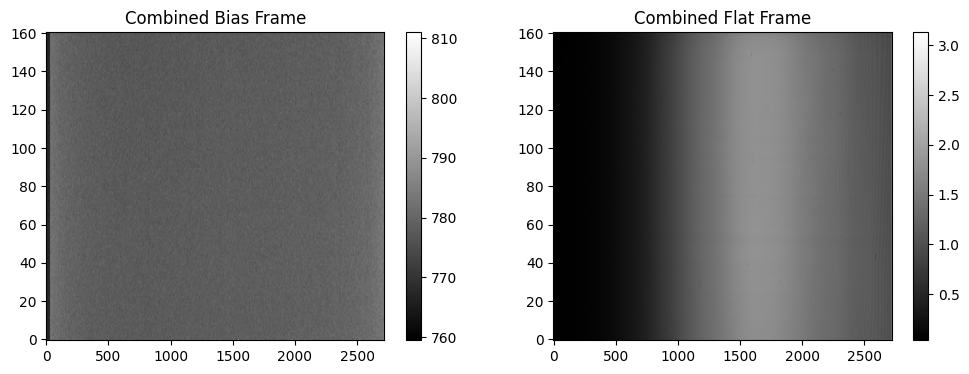

In [104]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Define the directory and file patterns
directory = 'drive/MyDrive/Astro_Data/'
bias_file_pattern = 'BIAS'
flat_file_pattern = 'FLAT'

# Specific file numbers to include
bias_numbers = {'0001','0002','0003', '0004','0005','0006','0007','0008','0009','0010'}
flat_numbers = {'0011','0012','0013','0014', '0015','0016', '0017', '0018','0019','0020','0021'}

# List and filter all files in the directory
all_files = os.listdir(directory)
bias_files = [file for file in all_files if file.split('.')[0] in bias_numbers and 'BIAS' in file]
flat_files = [file for file in all_files if file.split('.')[0] in flat_numbers and 'FLAT' in file]
print(flat_files)

print("Matched bias files:", bias_files)
print("Matched flat files:", flat_files)

# Load and trim the top BIAS files
bias_data = []
for file in bias_files:
    file_path = os.path.join(directory, file)
    with fits.open(file_path) as hdul:
        trimmed_data = hdul[0].data[:, :]  # Trim each bias file
        bias_data.append(trimmed_data)

# Combine all bias data by taking the median
combined_bias = np.median(np.array(bias_data), axis=0)

# Load and combine the top FLAT files, normalized and trimmed
flat_data = []
for file in flat_files:
    file_path = os.path.join(directory, file)
    with fits.open(file_path) as hdul:
        trimmed_flat_data = hdul[0].data[:, :]  # Apply trimming
        flat_data.append(trimmed_flat_data / np.mean(trimmed_flat_data))

# Combine all flat data by taking the median
combined_flat = np.median(np.array(flat_data), axis=0)

# Combine all flat data by taking the median across the array
combined_flat = np.median(np.array(flat_data), axis=0)

# Prepare pixel range for trimmed data
pixels = np.arange(0, combined_flat.shape[-1])

# Calculate the mean flat for polynomial fitting
mean_flat = np.mean(combined_flat, axis=0)

# Iteratively find the best polynomial degree (without weighting)
min_residual = np.inf
best_degree = 0

for degree in range(1, 10):  # Test polynomial degrees from 1 to 9
    p = np.polynomial.Polynomial.fit(pixels, mean_flat, degree)
    poly_fit = p(pixels)
    residual = np.sum((mean_flat - poly_fit) ** 2)  # Sum of squared residuals

    if residual < min_residual:
        min_residual = residual
        best_degree = degree

# Use the best degree found
p_best = np.polynomial.Polynomial.fit(pixels, mean_flat, best_degree)
poly_fit_best = p_best(pixels)

# Normalize the flat field
normalized_flat = combined_flat / (mean_flat / poly_fit_best)


# Function to process science images with bias subtraction, flat correction, and trimming
def process_science_image(science_file, combined_bias, combined_flat):
    with fits.open(science_file) as hdul:
        # Trim the science image to match the bias and flat dimensions
        science_image = hdul[0].data[:, :]

        # Subtract bias and apply flat-field correction
        bias_subtracted_image = science_image - combined_bias
        flat_corrected_image = bias_subtracted_image / combined_flat

        return flat_corrected_image, science_image


# Visualization for combined bias and flat frames
def plot_bias_and_flat(combined_bias, combined_flat):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(combined_bias, cmap='gray', origin='lower', aspect='auto')
    plt.colorbar()
    plt.title('Combined Bias Frame')

    plt.subplot(1, 2, 2)
    plt.imshow(combined_flat, cmap='gray', origin='lower', aspect='auto')
    plt.colorbar()
    plt.title('Combined Flat Frame')

    plt.show()


# Function to raw plot 1D spectrum from a specific region in the image
def plot_1d_spectrum_raw(image_data, y_start=80, y_end=88):
    spectrum_1d = np.sum(image_data[y_start:y_end], axis=0)

    # Plot the extracted 1D spectrum
    plt.figure(figsize=(10, 4))
    plt.plot(np.arange(len(spectrum_1d)), spectrum_1d, color='black')
    plt.title('Extracted 1D Spectrum')
    plt.xlabel('X Pixel')
    plt.ylabel('Summed Intensity')
    plt.show()

# Function to plot 1D spectrum from a specific region in the image
def plot_1d_spectrum(image_data, y_start=80, y_end=88):
    spectrum_1d = np.sum(image_data[y_start:y_end], axis=0)

    # Plot the 2D science image with highlighted region
    plt.figure(figsize=(12, 4))
    plt.imshow(image_data, cmap='gray', origin='lower', aspect='auto')
    plt.colorbar(label='Intensity')
    plt.axhline(y=y_start, color='red', linestyle='--', label='Extraction Start')
    plt.axhline(y=y_end, color='red', linestyle='--', label='Extraction End')
    plt.title('Science Image with Spectrum Extraction Region')
    plt.xlabel('X Pixel')
    plt.ylabel('Y Pixel')
    plt.ylim(78,100)
    plt.legend()
    plt.show()

    # Plot the extracted 1D spectrum
    plt.figure(figsize=(10, 5))
    plt.plot(np.arange(len(spectrum_1d)), spectrum_1d, color='black')
    plt.title('Extracted 1D Spectrum')
    plt.xlabel('X Pixel')
    plt.ylabel('Summed Intensity')
    plt.show()

# Function to visualize raw and corrected science images
def plot_science_images(raw_image, corrected_image):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(raw_image, cmap='gray', origin='lower', aspect='auto')
    plt.colorbar()
    plt.ylim(80,100)
    plt.title('Raw Science Image')

    plt.subplot(1, 2, 2)
    plt.imshow(corrected_image, cmap='gray', origin='lower', aspect='auto')
    plt.colorbar()
    plt.ylim(80,100)
    plt.title('Corrected Science Image')

    plt.show()

science_file = os.path.join("drive/MyDrive/Astro_Data/0091.NGC5548.fits")

print("Combined bias shape:", combined_bias.shape)
print("Combined flat shape:", combined_flat.shape)

print("All files in directory:")
for file in all_files:
    print(file)

plot_bias_and_flat(combined_bias, combined_flat)

# corrected_science_image, raw_science_image = process_science_image(science_file, combined_bias, combined_flat)                      #done
# plot_science_images(raw_science_image, corrected_science_image)


Viewing FITS file: drive/MyDrive/Astro_Data/0092.COMP.fits
Header:
SIMPLE  =                    T / Primary FITS image array                       
BITPIX  =                   16                                                  
NAXIS   =                    2 / NUMBER OF AXES                                 
NAXIS1  =                 2720 / CHIP WIDTH                                     
NAXIS2  =                  161 / CHIP HEIGHT                                    
EXTEND  =                    F / Fits standard                                  
OBJECT  = 'COMP              ' / OBJECT NAME                                    
NAMPS   =                    1                                                  
DATE    = '2025-03-20T12:06:12' / UT date/time at start                         
DATE-OBS= '2025-03-20        ' / UT date/time at start                          
RA      = '14:17:59.5        ' / RA                                             
DEC     = '25:08:12.45       ' / DEC     

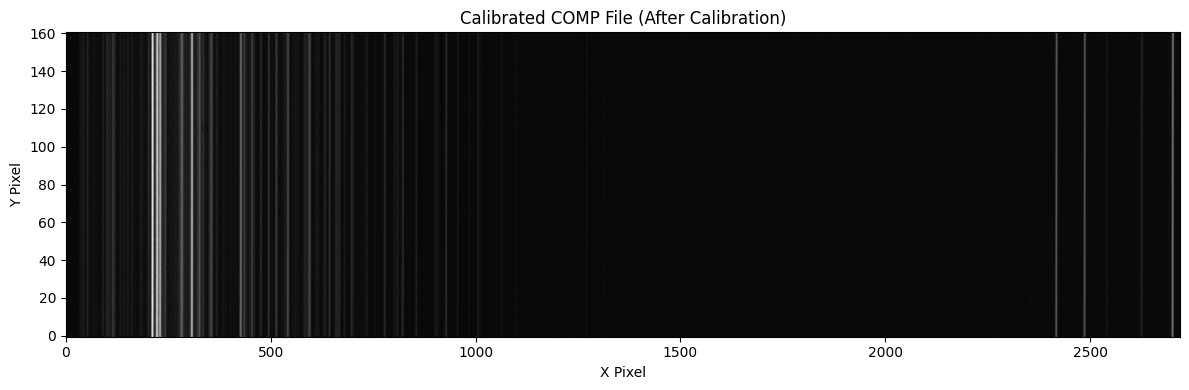

In [105]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.signal import find_peaks

# Define the directory and specific file
directory = 'drive/MyDrive/Astro_Data/'
comp_file = '0092.COMP.fits'  # Specify the COMP file you want to process                     done

# Load the COMP file (before calibration)
comp_file_path = os.path.join(directory, comp_file)
with fits.open(comp_file_path) as hdul:
    comp_data_raw = hdul[0].data

    print(f"\nViewing FITS file: {comp_file_path}")
    print("Header:")
    print(repr(hdul[0].header))
    print("\nData shape:")
    print(hdul[0].data.shape)

# Trim the raw data (same trimming as for bias and flat)
comp_data_trimmed = comp_data_raw[:, :]

# Normalize and subtract bias (using combined bias data)
bias_subtracted_comp = comp_data_trimmed - combined_bias

# Trim both the bias-subtracted COMP data and the normalized flat to match the smaller size
min_width = min(bias_subtracted_comp.shape[1], normalized_flat.shape[1])

bias_subtracted_comp_trimmed = bias_subtracted_comp[:, :min_width]
normalized_flat_trimmed = normalized_flat[:, :min_width]

# Apply flat correction (normalize by combined flat)
calibrated_comp = bias_subtracted_comp_trimmed / normalized_flat_trimmed

# Plot the raw, trimmed, and calibrated COMP image
fig, axs = plt.subplots(1, 1, figsize=(12, 4))

# Display the calibrated COMP file
axs.imshow(calibrated_comp, cmap='gray', origin='lower', aspect='auto')
axs.set_title('Calibrated COMP File (After Calibration)')
axs.set_xlabel('X Pixel')
axs.set_ylabel('Y Pixel')

plt.tight_layout()
plt.show()

# Create a 1D spectrum by summing over the spatial dimension (Y-axis)
comp_spectrum_1d = np.sum(calibrated_comp, axis=0)



30


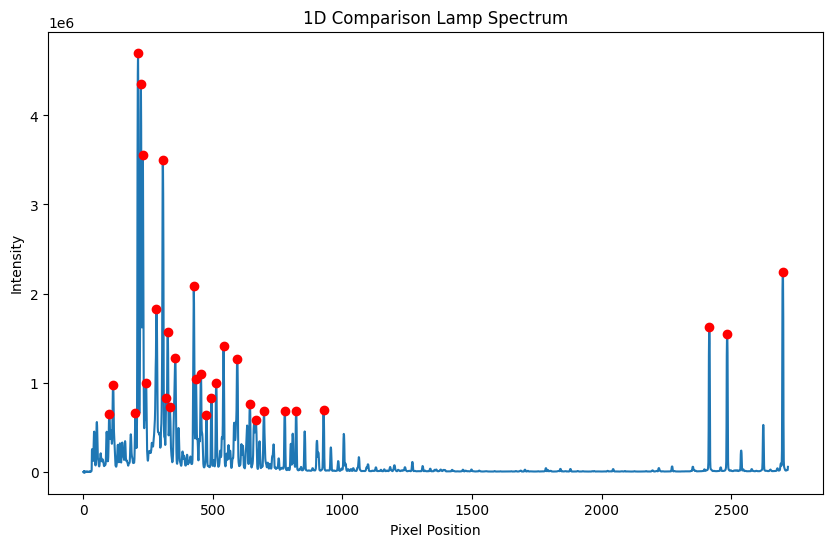

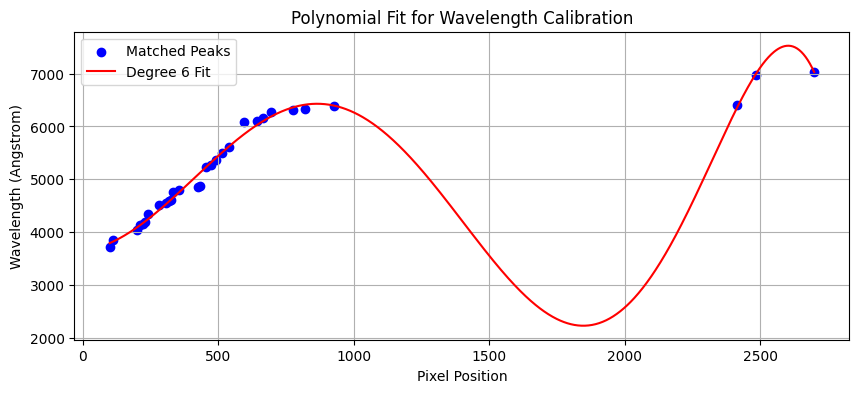

In [106]:
from numpy.polynomial import Polynomial
from scipy.signal import find_peaks

peaks, properties = find_peaks(comp_spectrum_1d)

# Sort peaks by intensity and select the 10 most intense peaks                                      done
peak_intensities = properties['peak_heights'] = comp_spectrum_1d[peaks]
top_peaks_idx = np.argsort(peak_intensities)[-30:]  # Indices of the 10 highest peaks
top_peaks = peaks[top_peaks_idx]  # Pixel positions of the 10 highest peaks
top_peaks_intensity = comp_spectrum_1d[top_peaks]  # Intensities of the 10 highest peaks

sorted_peak_pixels = np.sort(top_peaks)

# known wavelengths in Angstroms
wavelengths = np.array([
3719.935, 3859.400, 4045.450,4131.830, 4158.590, 4199.860, 4348.064,4510.733,
4545.080, 4589.900, 4609.560,4764.890, 4806.070,4847.820,4879.900, 5227.300,
5269.650,5371.489,5496.210, 5606.732,6074.338,6096.1630,6163.594,6266.495,
6304.850,6334.428,6382.991 ,6402.246,6965.4300,7032.4127
])

sorted_known_wavelengths = np.sort(wavelengths)

print(len(sorted_peak_pixels))


# Plot the 1D comparison spectrum with the 10 most intense peaks marked
plt.figure(figsize=(10, 6))
plt.plot(comp_spectrum_1d, label='Comparison Spectrum')
plt.plot(top_peaks, top_peaks_intensity, 'ro', label='Top 10 Intense Peaks')
plt.xlabel('Pixel Position')
plt.ylabel('Intensity')
plt.title('1D Comparison Lamp Spectrum')



# Fit a polynomial (linear or quadratic depending on distortion)
fit_poly = Polynomial.fit(sorted_peak_pixels, sorted_known_wavelengths, deg=6)
# Apply the mapping to convert pixels to wavelengths
pixel_indices = np.arange(len(comp_spectrum_1d))
calibrated_wavelengths = fit_poly(pixel_indices)

plt.figure(figsize=(10, 4))

# Scatter of known data points
plt.scatter(sorted_peak_pixels, sorted_known_wavelengths, color='blue', label='Matched Peaks')

# Polynomial fit curve
x_fit = np.linspace(min(sorted_peak_pixels), max(sorted_peak_pixels), 1000)
y_fit = fit_poly(x_fit)
plt.plot(x_fit, y_fit, color='red', label=f'Degree {fit_poly.degree()} Fit')

plt.xlabel("Pixel Position")
plt.ylabel("Wavelength (Angstrom)")
plt.title("Polynomial Fit for Wavelength Calibration")
plt.grid(True)
plt.legend()
plt.show()


In [107]:
def plot_wavelength_pixel_solution(
    spectrum, pixel_positions, wavelength_values, wavelength_labels=None, annotate=True,
    figsize=(12, 5), invert_x=False, xlim=None, ylim=None
):

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(spectrum*150, label='1D Spectrum')
    ax.set_xlabel("Pixel Position")
    ax.set_ylabel("Intensity")
    ax.set_title("1D Spectrum with Known Line Positions")
    ax.grid(True)

    for i, pix in enumerate(pixel_positions):
        wl = wavelength_values[i]
        label = f"{wl:.1f} "
        if wavelength_labels is not None:
            label += f" ({wavelength_labels[i]})"
        ax.axvline(pix, color='red', linestyle='--', alpha=0.5)
        if annotate:
            ax.text(pix, spectrum[int(pix)] -2000000, label,
                    rotation=90, ha='right', va='bottom', fontsize=12, color='red')

    if invert_x:
        ax.invert_xaxis()
    if xlim:
        ax.set_xlim(*xlim)
    if ylim:
        ax.set_ylim(*ylim)

    plt.tight_layout()
    plt.show()                                                                              #done


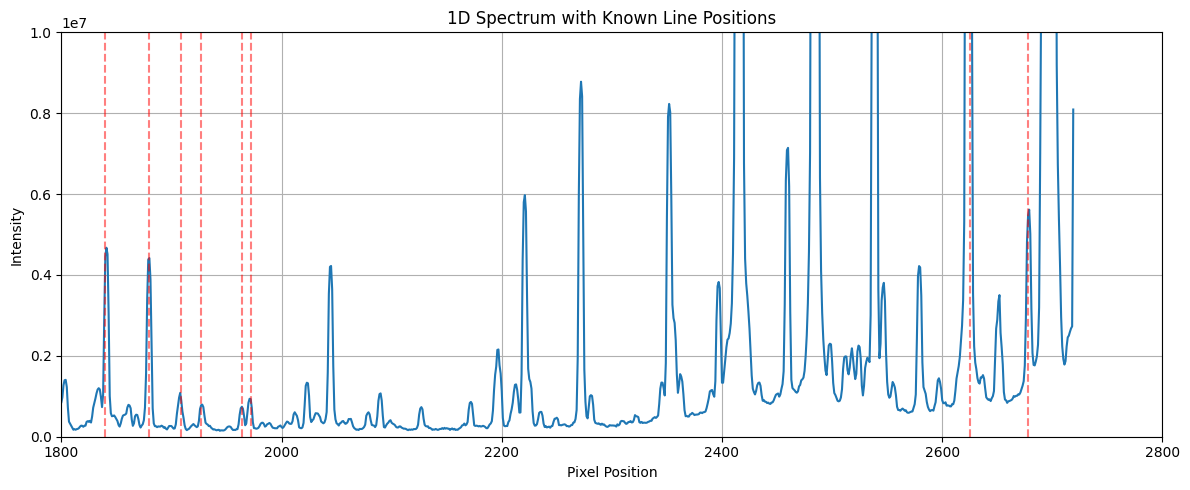

In [108]:
pixels_solution = np.array([210, 306, 435, 495, 512,540, 643,755,777,808,822,927,955,985,1005,1240,1270,1338,1422,
                            1497,1785, 1793,1840,1880,1909,1927,1964,1972,2625,2678])
wavelength_solution = np.array([3719.935, 3859.400, 4045.450,4131.830, 4158.590, 4199.860, 4348.064,4510.733,
                                4545.080, 4589.900, 4609.560,4764.890, 4806.070,4847.820,4879.900, 5227.300,
                                5269.650,5371.489,5496.210, 5606.732,6074.338,6096.1630,6163.594,6266.495,
                               6304.850,6334.428,6382.991 ,6402.246,6965.4300,7032.4127 ])#7383.980, 7514.651])
wavelength_label = np.array(["FeI", "FeI", "FeI" ,"ArII","ArI", "ArI","FeI", "ArII", "ArII", "AII","AII","AII","AII",
                             "AII","AII","AII", "AII","FeI","FeI","FeI", "AI","NeI","NeI","NeI","NeI","NeI","NeI",
                            "NeI","NeI","AI"])

plot_wavelength_pixel_solution(
    comp_spectrum_1d,
    pixels_solution,
    wavelength_solution,
    wavelength_labels=wavelength_label,
    annotate=False,
    invert_x=False,
    xlim=(1800,2800),
    ylim=(0,10e6)                                                                       #done
)


Polynomial coefficients: [-1.68082161e-07  6.07623135e-04  8.74859751e-01  3.55690971e+03]


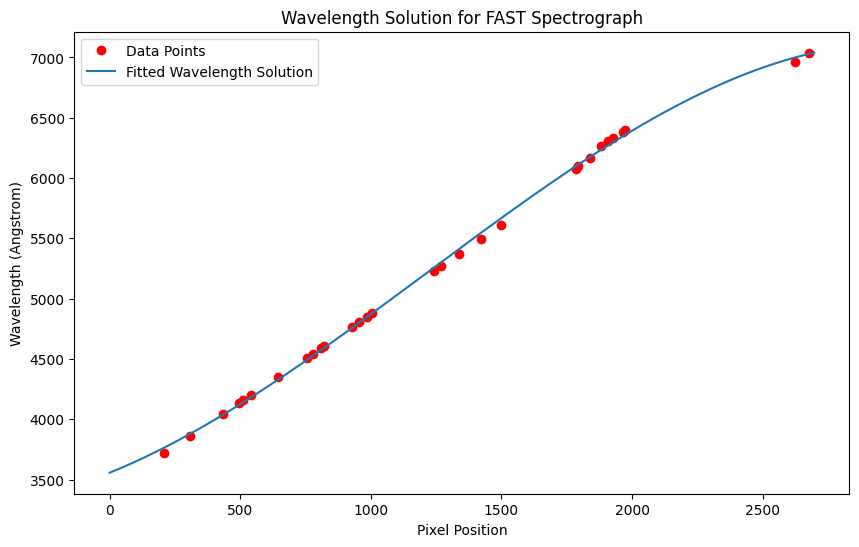

In [109]:
# Define a polynomial function to fit the data                                                                    done
from scipy.optimize import curve_fit

def polynomial(x, a, b, c, d):
    return  a * x**3 + b * x**2 + c * x + d

# Fit the polynomial to the data
popt, pcov = curve_fit(polynomial, pixels_solution, wavelength_solution,)
a, b, c, d = popt

# Print out the polynomial coefficients
print("Polynomial coefficients:", popt)

# Generate wavelengths using the polynomial solution across the full pixel range
pixel_range = np.arange(0, max(pixels_solution) +20)
calibrated_wavelengths = polynomial(pixel_range, *popt)

# Plot the original data points and the fitted polynomial solution
plt.figure(figsize=(10, 6))
plt.plot(pixels_solution, wavelength_solution, 'ro', label='Data Points')
plt.plot(pixel_range, calibrated_wavelengths, label='Fitted Wavelength Solution')
plt.xlabel('Pixel Position')
plt.ylabel('Wavelength (Angstrom)')
plt.title('Wavelength Solution for FAST Spectrograph')
plt.legend()
plt.show()

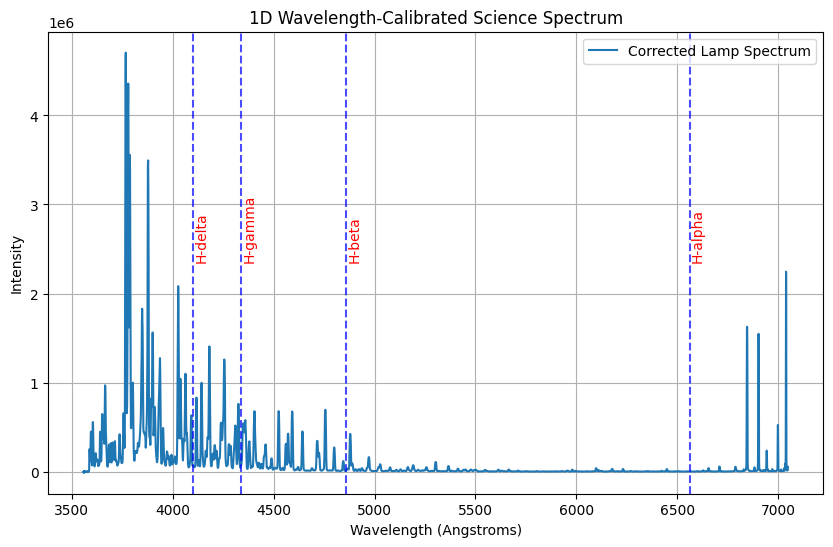

In [110]:
coeffs = [-1.68082148e-07, 6.07623080e-04, 8.74859821e-01, 3.55690968e+03]

def apply_wavelength_solution(pixels, coeffs):
    return np.polyval(coeffs, pixels)



science_file = os.path.join("drive/MyDrive/Astro_Data/0091.NGC5548.fits")

corrected_science_image, raw_science_image = process_science_image(science_file, combined_bias, combined_flat)
science_spectrum_1d = np.sum(corrected_science_image, axis=0)
pixels = np.arange(len(comp_spectrum_1d))

wavelength_solution_adjusted = apply_wavelength_solution(pixels, coeffs)
wavelength_solution_adjusted_science = apply_wavelength_solution(pixels, coeffs)

# Define only the H-alpha spectral line
lines = {
    'H-alpha': 6563,
    'H-beta': 4861,
    'H-gamma': 4340,
    'H-delta': 4101
}

def plot_1d_spectrum_with_lines(wavelengths, spectrum_1d):
    plt.figure(figsize=(10, 6))

    # Plot the 1D spectrum
    plt.plot(wavelengths, spectrum_1d, label='Corrected Lamp Spectrum')
    plt.xlabel('Wavelength (Angstroms)')
    plt.ylabel('Intensity')
    plt.title('1D Wavelength-Calibrated Science Spectrum')
    plt.grid(True)

    # Plot the vertical line for the H-alpha line
    for line_name, line_wavelength in lines.items():
        plt.axvline(x=line_wavelength, color='blue', linestyle='--', alpha=0.7)
        plt.text(line_wavelength +5, np.max(spectrum_1d) * 0.5, line_name, rotation=90, verticalalignment='bottom', color='red')

    plt.legend()
    plt.show()

# Plot the 1D spectrum with only the H-alpha line using the wavelength solution
plot_1d_spectrum_with_lines(wavelength_solution_adjusted, comp_spectrum_1d)

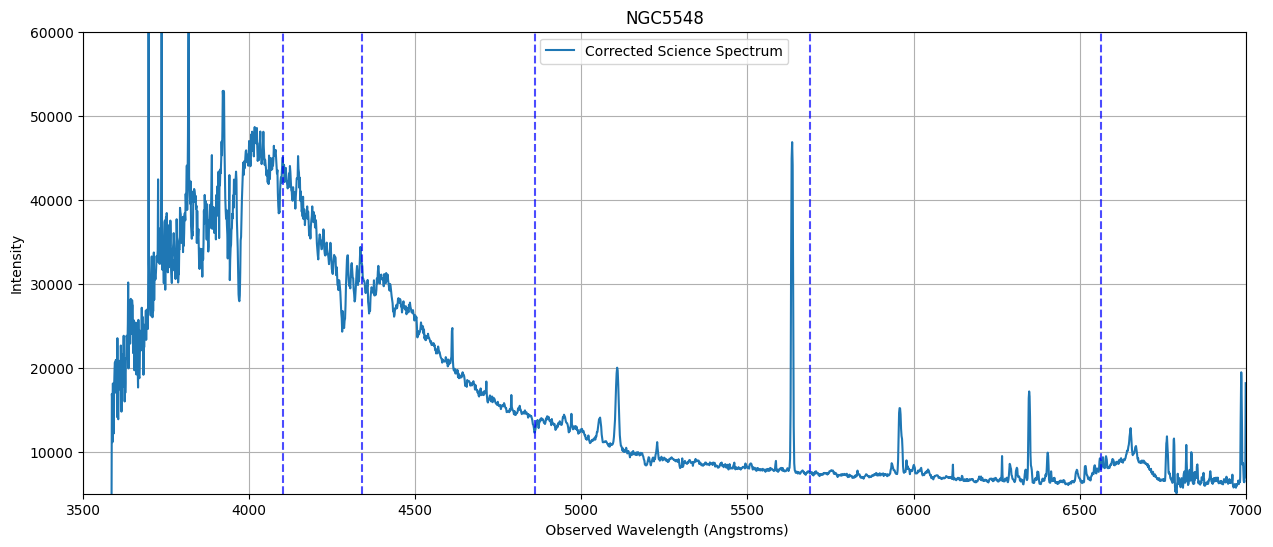

In [111]:
def plot_1d_spectrum_with_lines(wavelengths, spectrum_1d):
    plt.figure(figsize=(15, 6))

    # Plot the 1D spectrum                                                                done.
    plt.plot(wavelengths, spectrum_1d, label='Corrected Science Spectrum')
    plt.xlabel(' Observed Wavelength (Angstroms)')
    plt.ylabel('Intensity')
    plt.title('NGC5548')
    plt.grid(True)

    # Plot the vertical line for the H-alpha line
    for line_name, line_wavelength in lines.items():
        plt.axvline(x=line_wavelength, color='blue', linestyle='--', alpha=0.7)


    plt.axvline(x=5688, color='blue', linestyle='--', alpha=0.7)
    plt.xlim(3500, 7000)
    plt.ylim(5000, 60000)
    plt.legend()
    plt.show()



plot_1d_spectrum_with_lines(wavelength_solution_adjusted_science, science_spectrum_1d)

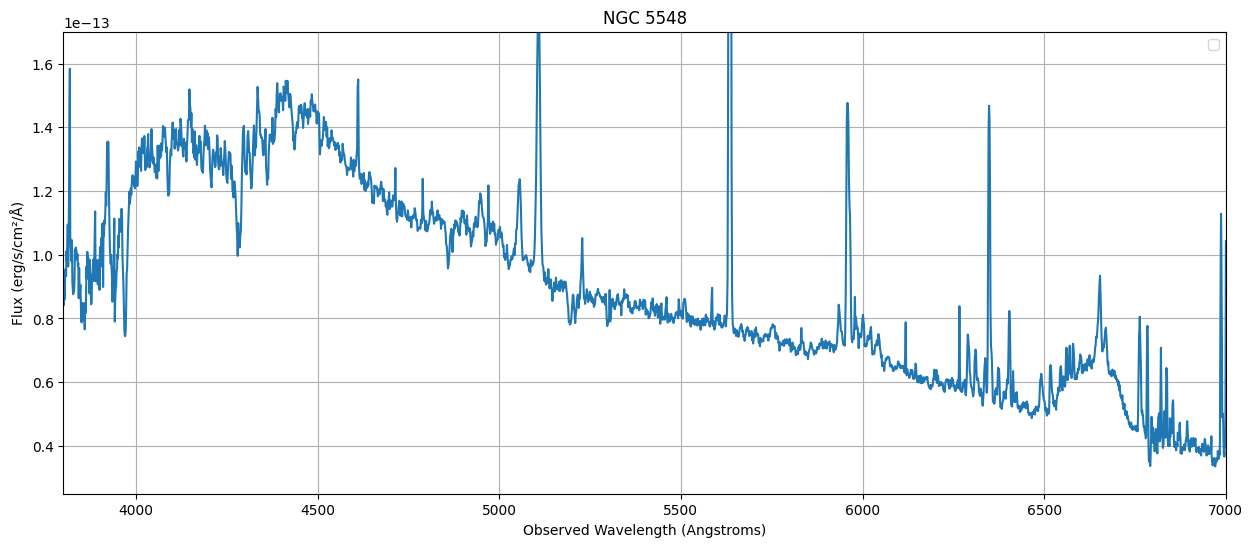

In [112]:
def plot_1d_spectrum_with_lines(wavelengths, spectrum_1d, ylimit=None):
    plt.figure(figsize=(15, 6))

    # Plot the 1D spectrum                                                          done.
    plt.plot(wavelengths, spectrum_1d)
    plt.xlabel('Observed Wavelength (Angstroms)')
    plt.ylabel('Flux (erg/s/cm²/Å)')
    plt.title('NGC 5548')
    plt.grid(True)

    # Plot the vertical line for the H-alpha line
    #for line_name, line_wavelength in lines.items():
        #plt.axvline(x=line_wavelength, color='red', linestyle='--', alpha=0.7)
    plt.xlim(3800, 7000)

    # If ylimit is provided, use it for the y-axis limits
    if ylimit:
        plt.ylim(ylimit)

    plt.legend()
    plt.show()

    # 1. Apply the same smoothed sensitivity function
science_flux_calibrated = science_spectrum_1d * sensitivity_smoothed

# 2. Plot the flux-calibrated spectrum with custom y-limits
plot_1d_spectrum_with_lines(wavelength_solution_adjusted_science, science_flux_calibrated, ylimit=(0.25e-13, 1.70e-13))

# 3. Save to file
np.savetxt('flux_calibrated_5548.txt',
           np.column_stack((wavelength_solution_adjusted_science, science_flux_calibrated)),
           header='Wavelength (Angstroms)    Flux (erg/s/cm^2/Angstrom)')

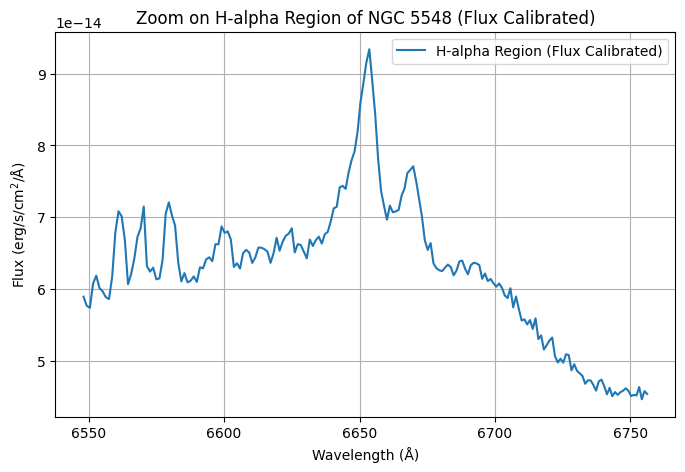

In [113]:
# Define the zoom-in region around H-alpha
hbeta_center = 6563 * (1 + 0.01356)  # Apply small redshift correction
window = 105  # +/- 80 Å window

# Find indices corresponding to the H-beta region
mask = (wavelength_solution_adjusted_science > hbeta_center - window) & \
       (wavelength_solution_adjusted_science < hbeta_center + window)

wavelength_halpha = wavelength_solution_adjusted_science[mask]
spectrum_halpha = science_flux_calibrated[mask]  # <-- Now use flux-calibrated spectrum

# Plot to check
plt.figure(figsize=(8, 5))
plt.plot(wavelength_halpha, spectrum_halpha, label='H-alpha Region (Flux Calibrated)')
plt.xlabel('Wavelength (Å)')
plt.ylabel(r'Flux (erg/s/cm$^2$/Å)')
plt.title('Zoom on H-alpha Region of NGC 5548 (Flux Calibrated)')
plt.grid(True)
plt.legend()
plt.show()

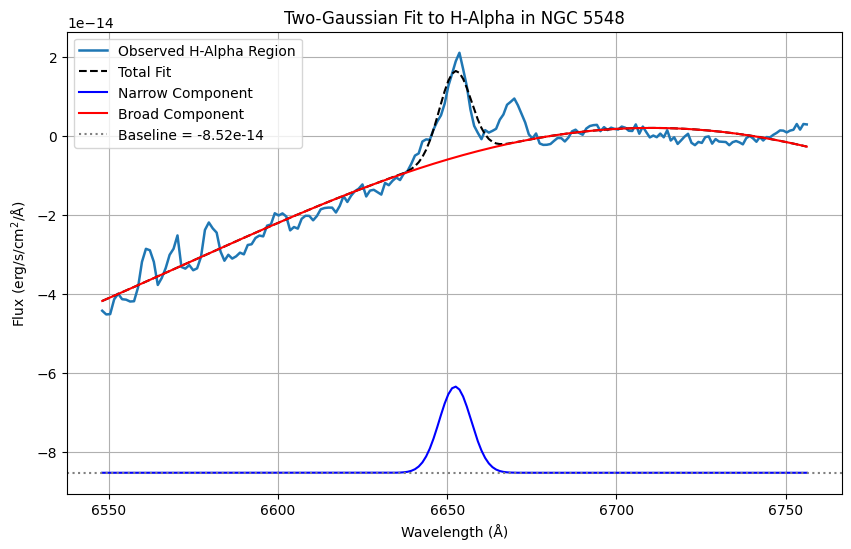

In [114]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

# Define model for emission lines                                                                               done
def two_gaussians_plus_baseline(wavelength, amp1, cen1, sigma1, amp2, cen2, sigma2, baseline):
    gauss1 = amp1 * np.exp(-(wavelength - cen1)**2 / (2 * sigma1**2))  # narrow
    gauss2 = amp2 * np.exp(-(wavelength - cen2)**2 / (2 * sigma2**2))  # broad
    return gauss1 + gauss2 + baseline

# Observed H-beta center
hb_obs = 6563 * (1 + 0.01356)

# Set variables for clarity
wave_fit = wavelength_halpha
flux_fit = spectrum_halpha

# Estimate and subtract the continuum:
# - Here we assume a simple linear continuum model for simplicity.
def estimate_continuum(wavelength, flux):
    # Fit a linear continuum model to regions away from the emission line
    mask = (wavelength < 6500) | (wavelength > 6700)  # Mask the region around H-beta (assumed)
    continuum_params = np.polyfit(wavelength[mask], flux[mask], 1)  # Fit a linear function
    continuum = np.polyval(continuum_params, wavelength)  # Evaluate the continuum over the entire range
    return continuum

# Estimate and subtract continuum from the spectrum
continuum = estimate_continuum(wave_fit, flux_fit)
flux_fit_subtracted = flux_fit - continuum  # Subtracted spectrum

# Initial parameter guesses for emission line fitting
amp1_guess = np.max(flux_fit_subtracted)
cen1_guess = hb_obs
sigma1_guess = 2

amp2_guess = np.max(flux_fit_subtracted) / 2
cen2_guess = hb_obs
sigma2_guess = 10

# Set the baseline to the desired value
baseline_guess = -0.8  # <-- Set baseline guess to -0.8

# Initial guess for parameters
initial_guess = [amp1_guess, cen1_guess, sigma1_guess, amp2_guess, cen2_guess, sigma2_guess, baseline_guess]

# Perform fit with increased maxfev
popt, pcov = curve_fit(two_gaussians_plus_baseline, wave_fit, flux_fit_subtracted, p0=initial_guess, maxfev=5000)

# Extract parameters
amp1, cen1, sigma1, amp2, cen2, sigma2, baseline = popt

# Build fit curves
fit_curve = two_gaussians_plus_baseline(wave_fit, *popt)
gauss_narrow = amp1 * np.exp(-(wave_fit - cen1)**2 / (2 * sigma1**2))
gauss_broad = amp2 * np.exp(-(wave_fit - cen2)**2 / (2 * sigma2**2))

# Plot result
plt.figure(figsize=(10, 6))
plt.plot(wave_fit, flux_fit_subtracted, label='Observed H-Alpha Region', linewidth=1.8)
plt.plot(wave_fit, fit_curve, '--', color='black', label='Total Fit')
plt.plot(wave_fit, gauss_narrow + baseline, label='Narrow Component', color='blue')
plt.plot(wave_fit, gauss_broad + baseline, label='Broad Component', color='red')
plt.axhline(baseline, color='gray', linestyle=':', label=f'Baseline = {baseline:.2e}')
plt.xlabel('Wavelength (Å)')
plt.ylabel(r'Flux (erg/s/cm$^2$/Å)')
plt.title('Two-Gaussian Fit to H-Alpha in NGC 5548')
plt.legend()
plt.grid(True)
plt.show()

In [115]:
# --- Calculate FWHM of the Broad Component (sigma2 comes from the broad Gaussian)                                    done

# FWHM in Angstroms (Gaussian relation: FWHM = 2.355 * sigma)
fwhm_angstroms = 2.355 * sigma2

# Rest-frame wavelength of H-alpha
ha_rest = 6563  # Angstroms

# Convert FWHM from Angstroms to km/s using Doppler formula
fwhm_kms = (fwhm_angstroms / ha_rest) * 3e5  # 3e5 km/s is speed of light

# Print results
print(f"Broad Component FWHM ≈ {fwhm_angstroms:.2f} Å ≈ {fwhm_kms:.0f} km/s")

Broad Component FWHM ≈ 323.72 Å ≈ 14798 km/s


In [116]:

#Define a window around 5100 Å
window_center = 5100 * (1 + 0.01356)  # Redshifted center
window_width = 50  # +/- 50 Å

mask_5100 = (wavelength_solution_adjusted_science > window_center - window_width) & \
            (wavelength_solution_adjusted_science < window_center + window_width)

wave_5100 = wavelength_solution_adjusted_science[mask_5100]
flux_5100 = science_flux_calibrated[mask_5100]

# Average flux density f_lambda (in erg/s/cm²/Å)
f_lambda_5100 = np.mean(flux_5100)

# Luminosity Distance D_L
DL_Mpc = 75  # Mpc
DL_cm = DL_Mpc * 3.086e24  # convert to cm

# Monochromatic luminosity at 5100 Å
L_5100 = 4 * np.pi * DL_cm**2 * f_lambda_5100  # erg/s/Å

print(f"f_lambda(5100) = {f_lambda_5100:.2e} erg/s/cm^2/Å")
print(f"L_lambda(5100) = {L_5100:.2e} erg/s/Å")

f_lambda(5100) = 8.82e-14 erg/s/cm^2/Å
L_lambda(5100) = 5.94e+40 erg/s/Å


In [117]:
# Black hole mass calculation                                                                                       done

# Constants from empirical relation
a = 6.91
b = 0.5

# Compute log values
log_L = np.log10(L_5100 / 1e44)
log_FWHM = np.log10(fwhm_kms / 1000)

# Final formula
log_M_BH = a + b * log_L + 2 * log_FWHM
M_BH = 10**log_M_BH

print(f"Log(M_BH/M_sun) = {log_M_BH:.2f}")
print(f"M_BH ≈ {M_BH:.2e} M_sun")

# Include 0.4 dex uncertainty
dex_uncertainty = 0.4

# Upper and lower limits in log space
log_M_BH_upper = log_M_BH + dex_uncertainty
log_M_BH_lower = log_M_BH - dex_uncertainty

# Convert back to linear space
M_BH_upper = 10**log_M_BH_upper
M_BH_lower = 10**log_M_BH_lower

# Report results
print(f"Log(M_BH/M_sun) = {log_M_BH:.2f} ± {dex_uncertainty:.1f} dex")
print(f"M_BH ≈ ({M_BH:.2e}) M_sun")
print(f"Range: ({M_BH_lower:.2e} - {M_BH_upper:.2e}) M_sun")

Log(M_BH/M_sun) = 7.64
M_BH ≈ 4.34e+07 M_sun
Log(M_BH/M_sun) = 7.64 ± 0.4 dex
M_BH ≈ (4.34e+07) M_sun
Range: (1.73e+07 - 1.09e+08) M_sun


In [118]:
# Constants in CGS                                                                                                    done
c = 2.998e10  # Speed of light in cm/s
eta = 0.1  # Radiative efficiency
Msun_g = 1.989e33  # Solar mass in grams
sec_per_year = 3.154e7  # Seconds per year

# Given L5100 (in erg/s)
L5100 = 5.94e40  # erg/s

# Bolometric correction
BC = 5  # Typical for Seyferts
L_bol = L5100 * BC  # erg/s

# Accretion rate in g/s
mdot_g_per_s = L_bol / (eta * c**2)

# Convert to solar masses per year
mdot_msun_per_year = (mdot_g_per_s / Msun_g) * sec_per_year

# Print the result
print(f"Accretion Rate ≈ {mdot_msun_per_year:.8f} M_sun/year")


Accretion Rate ≈ 0.00005240 M_sun/year


Reading in the bias frames now
Created the master bias
Reading in the flat frames now


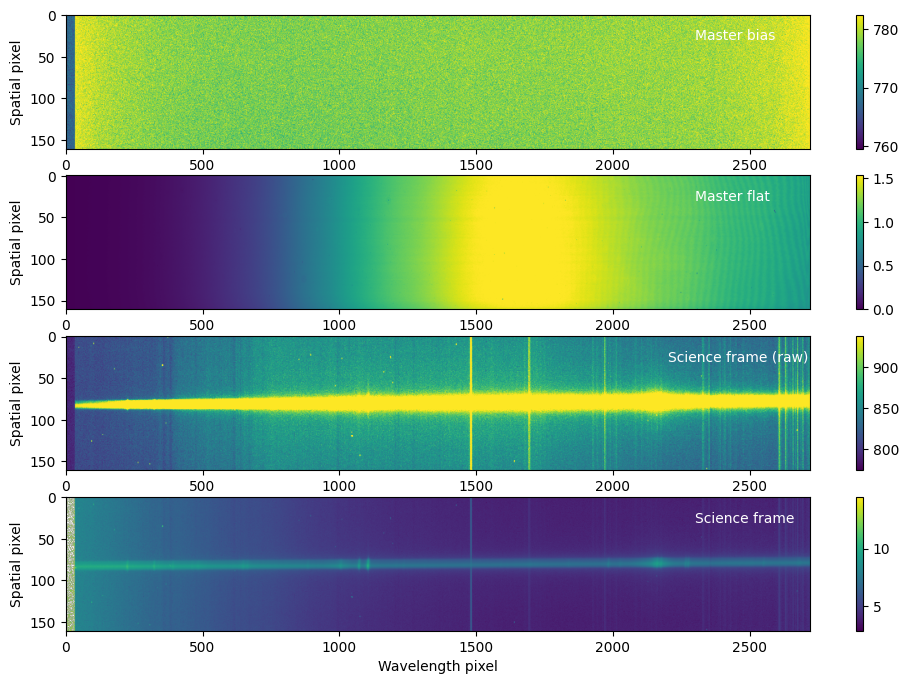

In [119]:
fl = glob.glob('drive/MyDrive/Astro_Data/*BIAS*.fits')

master_bias = []

print("Reading in the bias frames now")
for fn in fl:
  data = fits.getdata(fn)
  master_bias.append(data[None])

master_bias = np.concatenate(master_bias, axis=0)
master_bias = np.median(master_bias, axis=0)
print("Created the master bias")

fl = glob.glob('drive/MyDrive/Astro_Data/*FLAT*.fits')

master_flat = []

print("Reading in the flat frames now")

for fn in fl:
  data = fits.getdata(fn)
  data = data - master_bias
  master_flat.append(data[None])

master_flat = np.concatenate(master_flat, axis=0)
master_flat = np.median(master_flat, axis=0)
master_flat = master_flat / np.median(master_flat)

fig = plt.figure(figsize=(12,8))

plt.subplot(411)
plt.imshow(master_bias, aspect='auto', vmax=np.percentile(master_bias, 90))
plt.colorbar()
plt.text(2300, 30, 'Master bias', color='white')
plt.ylabel('Spatial pixel')

plt.subplot(412)
plt.imshow(master_flat, aspect='auto', vmax=np.percentile(master_flat, 90))
plt.colorbar()
plt.text(2300, 30, 'Master flat', color='white')
plt.ylabel('Spatial pixel')

plt.subplot(413)
fl = glob.glob('drive/MyDrive/Astro_Data/*NGC4151*.fits')
fn = fl[0]
data = fits.getdata(fn)
plt.imshow(data, aspect='auto', vmax=np.percentile(data, 90))
plt.text(2200, 30, 'Science frame (raw)', color='white')
plt.colorbar()
plt.ylabel('Spatial pixel')

plt.subplot(414)
data = data - master_bias
data = data / master_flat

plt.imshow(np.log(data), aspect='auto', )
plt.xlabel('Wavelength pixel')
plt.ylabel('Spatial pixel')
plt.text(2300, 30, 'Science frame', color='white')
plt.colorbar()

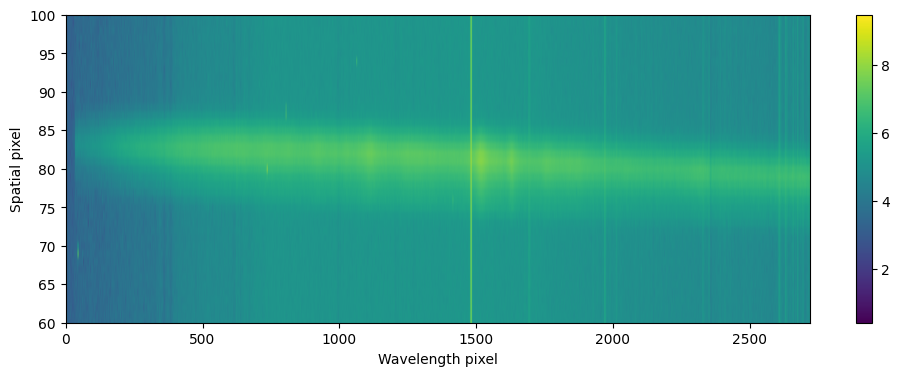

In [120]:
fig = plt.figure(figsize=(12,4))
plt.imshow(np.log(data2), aspect='auto', )
plt.ylim(60, 100)
plt.xlabel('Wavelength pixel')
plt.ylabel('Spatial pixel')
plt.colorbar()

[]

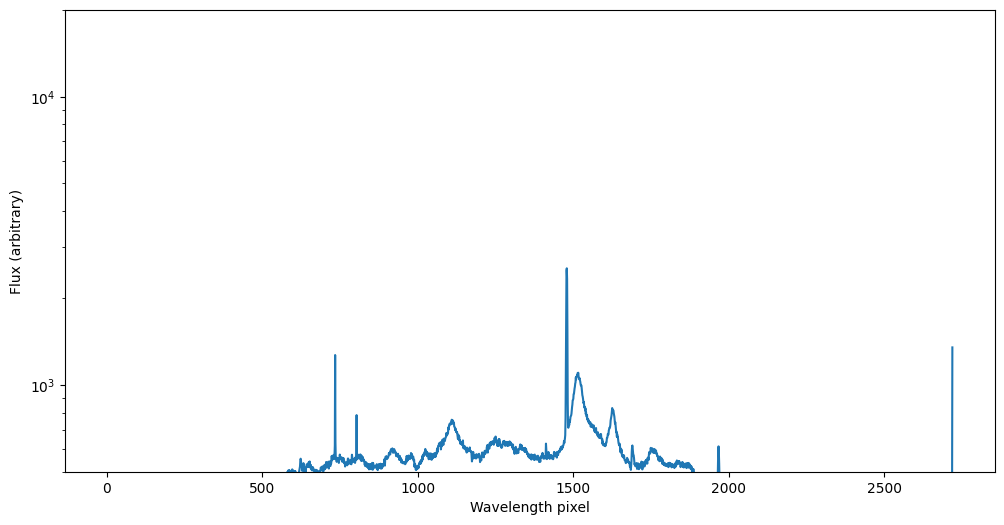

In [121]:
plt.figure(figsize=(12,6))
plt.plot(data2[75:88].mean(0))
plt.xlabel('Wavelength pixel')
plt.ylabel('Flux (arbitrary)')
plt.ylim(5e2, 2e4)
plt.semilogy()

['0015.FLAT.fits', '0017.FLAT.fits', '0014.FLAT.fits', '0012.FLAT.fits', '0020.FLAT.fits', '0019.FLAT.fits', '0021.FLAT.fits', '0011.FLAT.fits', '0018.FLAT.fits', '0013.FLAT.fits', '0016.FLAT.fits']
Matched bias files: ['0002.BIAS.fits', '0004.BIAS.fits', '0010.BIAS.fits', '0005.BIAS.fits', '0008.BIAS.fits', '0007.BIAS.fits', '0006.BIAS.fits', '0009.BIAS.fits', '0001.BIAS.fits', '0003.BIAS.fits']
Matched flat files: ['0015.FLAT.fits', '0017.FLAT.fits', '0014.FLAT.fits', '0012.FLAT.fits', '0020.FLAT.fits', '0019.FLAT.fits', '0021.FLAT.fits', '0011.FLAT.fits', '0018.FLAT.fits', '0013.FLAT.fits', '0016.FLAT.fits']
Combined bias shape: (161, 2720)
Combined flat shape: (161, 2720)
All files in directory:
0002.BIAS.fits
0004.BIAS.fits
0010.BIAS.fits
0063.COMP.fits
0062.3C273.fits
0005.BIAS.fits
0069.NGC4151.fits
0015.FLAT.fits
0017.FLAT.fits
0070.COMP.fits
0008.BIAS.fits
0014.FLAT.fits
0012.FLAT.fits
0007.BIAS.fits
0006.BIAS.fits
0048.COMP.fits
0020.FLAT.fits
0019.FLAT.fits
0021.FLAT.fits
00

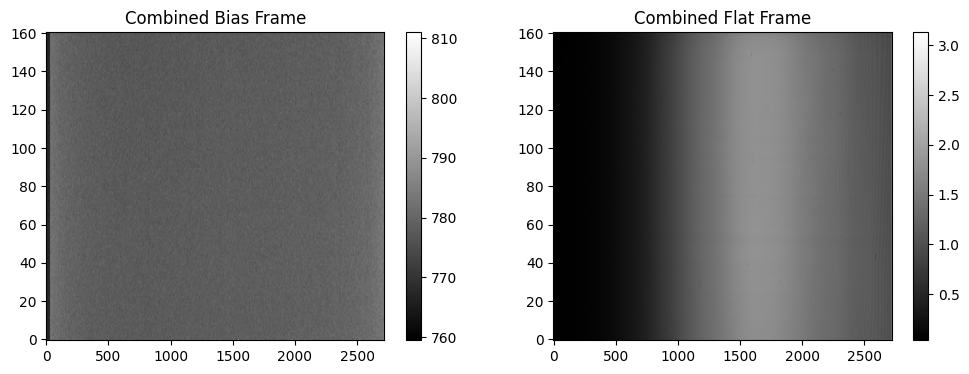

In [122]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Define the directory and file patterns
directory = 'drive/MyDrive/Astro_Data/'
bias_file_pattern = 'BIAS'
flat_file_pattern = 'FLAT'

# Specific file numbers to include
bias_numbers = {'0001','0002','0003', '0004','0005','0006','0007','0008','0009','0010'}
flat_numbers = {'0011','0012','0013','0014', '0015','0016', '0017', '0018','0019','0020','0021'}

# List and filter all files in the directory
all_files = os.listdir(directory)
bias_files = [file for file in all_files if file.split('.')[0] in bias_numbers and 'BIAS' in file]
flat_files = [file for file in all_files if file.split('.')[0] in flat_numbers and 'FLAT' in file]
print(flat_files)

print("Matched bias files:", bias_files)
print("Matched flat files:", flat_files)

# Load and trim the top BIAS files
bias_data = []
for file in bias_files:
    file_path = os.path.join(directory, file)
    with fits.open(file_path) as hdul:
        trimmed_data = hdul[0].data[:, :]  # Trim each bias file
        bias_data.append(trimmed_data)

# Combine all bias data by taking the median
combined_bias = np.median(np.array(bias_data), axis=0)

# Load and combine the top FLAT files, normalized and trimmed
flat_data = []
for file in flat_files:
    file_path = os.path.join(directory, file)
    with fits.open(file_path) as hdul:
        trimmed_flat_data = hdul[0].data[:, :]  # Apply trimming
        flat_data.append(trimmed_flat_data / np.mean(trimmed_flat_data))

# Combine all flat data by taking the median
combined_flat = np.median(np.array(flat_data), axis=0)

# Combine all flat data by taking the median across the array
combined_flat = np.median(np.array(flat_data), axis=0)

# Prepare pixel range for trimmed data
pixels = np.arange(0, combined_flat.shape[-1])

# Calculate the mean flat for polynomial fitting
mean_flat = np.mean(combined_flat, axis=0)

# Iteratively find the best polynomial degree (without weighting)
min_residual = np.inf
best_degree = 0

for degree in range(1, 10):  # Test polynomial degrees from 1 to 9
    p = np.polynomial.Polynomial.fit(pixels, mean_flat, degree)
    poly_fit = p(pixels)
    residual = np.sum((mean_flat - poly_fit) ** 2)  # Sum of squared residuals

    if residual < min_residual:
        min_residual = residual
        best_degree = degree

# Use the best degree found
p_best = np.polynomial.Polynomial.fit(pixels, mean_flat, best_degree)
poly_fit_best = p_best(pixels)

# Normalize the flat field
normalized_flat = combined_flat / (mean_flat / poly_fit_best)


# Function to process science images with bias subtraction, flat correction, and trimming
def process_science_image(science_file, combined_bias, combined_flat):
    with fits.open(science_file) as hdul:
        # Trim the science image to match the bias and flat dimensions
        science_image = hdul[0].data[:, :]

        # Subtract bias and apply flat-field correction
        bias_subtracted_image = science_image - combined_bias
        flat_corrected_image = bias_subtracted_image / combined_flat

        return flat_corrected_image, science_image


# Visualization for combined bias and flat frames
def plot_bias_and_flat(combined_bias, combined_flat):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(combined_bias, cmap='gray', origin='lower', aspect='auto')
    plt.colorbar()
    plt.title('Combined Bias Frame')

    plt.subplot(1, 2, 2)
    plt.imshow(combined_flat, cmap='gray', origin='lower', aspect='auto')
    plt.colorbar()
    plt.title('Combined Flat Frame')

    plt.show()


# Function to raw plot 1D spectrum from a specific region in the image
def plot_1d_spectrum_raw(image_data, y_start=80, y_end=88):
    spectrum_1d = np.sum(image_data[y_start:y_end], axis=0)

    # Plot the extracted 1D spectrum
    plt.figure(figsize=(10, 4))
    plt.plot(np.arange(len(spectrum_1d)), spectrum_1d, color='black')
    plt.title('Extracted 1D Spectrum')
    plt.xlabel('X Pixel')
    plt.ylabel('Summed Intensity')
    plt.show()

# Function to plot 1D spectrum from a specific region in the image
def plot_1d_spectrum(image_data, y_start=80, y_end=88):
    spectrum_1d = np.sum(image_data[y_start:y_end], axis=0)

    # Plot the 2D science image with highlighted region
    plt.figure(figsize=(12, 4))
    plt.imshow(image_data, cmap='gray', origin='lower', aspect='auto')
    plt.colorbar(label='Intensity')
    plt.axhline(y=y_start, color='red', linestyle='--', label='Extraction Start')
    plt.axhline(y=y_end, color='red', linestyle='--', label='Extraction End')
    plt.title('Science Image with Spectrum Extraction Region')
    plt.xlabel('X Pixel')
    plt.ylabel('Y Pixel')
    plt.ylim(78,100)
    plt.legend()
    plt.show()

    # Plot the extracted 1D spectrum
    plt.figure(figsize=(10, 5))
    plt.plot(np.arange(len(spectrum_1d)), spectrum_1d, color='black')
    plt.title('Extracted 1D Spectrum')
    plt.xlabel('X Pixel')
    plt.ylabel('Summed Intensity')
    plt.show()

# Function to visualize raw and corrected science images
def plot_science_images(raw_image, corrected_image):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(raw_image, cmap='gray', origin='lower', aspect='auto')
    plt.colorbar()
    plt.ylim(80,100)
    plt.title('Raw Science Image')

    plt.subplot(1, 2, 2)
    plt.imshow(corrected_image, cmap='gray', origin='lower', aspect='auto')
    plt.colorbar()
    plt.ylim(80,100)
    plt.title('Corrected Science Image')

    plt.show()

science_file = os.path.join("drive/MyDrive/Astro_Data/0069.NGC4151.fits")

print("Combined bias shape:", combined_bias.shape)
print("Combined flat shape:", combined_flat.shape)

print("All files in directory:")
for file in all_files:
    print(file)

plot_bias_and_flat(combined_bias, combined_flat)

# corrected_science_image, raw_science_image = process_science_image(science_file, combined_bias, combined_flat)                      #done
# plot_science_images(raw_science_image, corrected_science_image)


Viewing FITS file: drive/MyDrive/Astro_Data/0092.COMP.fits
Header:
SIMPLE  =                    T / Primary FITS image array                       
BITPIX  =                   16                                                  
NAXIS   =                    2 / NUMBER OF AXES                                 
NAXIS1  =                 2720 / CHIP WIDTH                                     
NAXIS2  =                  161 / CHIP HEIGHT                                    
EXTEND  =                    F / Fits standard                                  
OBJECT  = 'COMP              ' / OBJECT NAME                                    
NAMPS   =                    1                                                  
DATE    = '2025-03-20T12:06:12' / UT date/time at start                         
DATE-OBS= '2025-03-20        ' / UT date/time at start                          
RA      = '14:17:59.5        ' / RA                                             
DEC     = '25:08:12.45       ' / DEC     

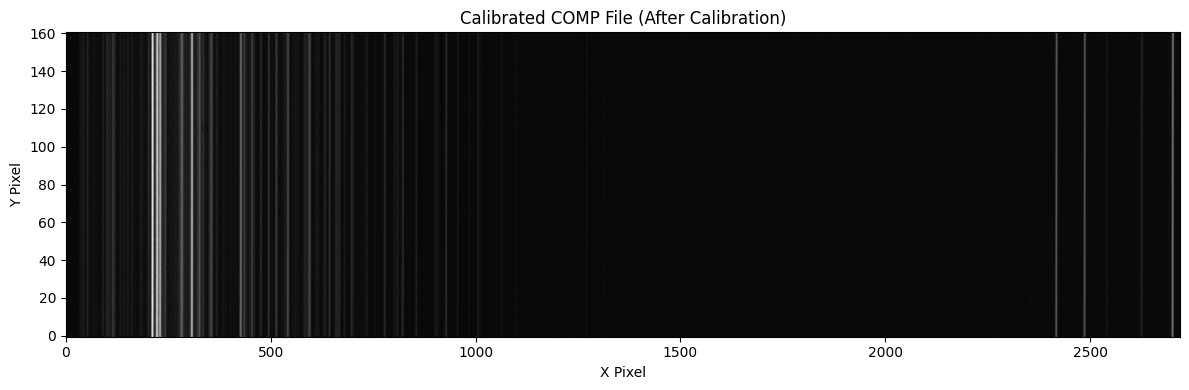

In [123]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.signal import find_peaks

# Define the directory and specific file
directory = 'drive/MyDrive/Astro_Data/'
comp_file = '0092.COMP.fits'  # Specify the COMP file you want to process                     done

# Load the COMP file (before calibration)
comp_file_path = os.path.join(directory, comp_file)
with fits.open(comp_file_path) as hdul:
    comp_data_raw = hdul[0].data

    print(f"\nViewing FITS file: {comp_file_path}")
    print("Header:")
    print(repr(hdul[0].header))
    print("\nData shape:")
    print(hdul[0].data.shape)

# Trim the raw data (same trimming as for bias and flat)
comp_data_trimmed = comp_data_raw[:, :]

# Normalize and subtract bias (using combined bias data)
bias_subtracted_comp = comp_data_trimmed - combined_bias

# Trim both the bias-subtracted COMP data and the normalized flat to match the smaller size
min_width = min(bias_subtracted_comp.shape[1], normalized_flat.shape[1])

bias_subtracted_comp_trimmed = bias_subtracted_comp[:, :min_width]
normalized_flat_trimmed = normalized_flat[:, :min_width]

# Apply flat correction (normalize by combined flat)
calibrated_comp = bias_subtracted_comp_trimmed / normalized_flat_trimmed

# Plot the raw, trimmed, and calibrated COMP image
fig, axs = plt.subplots(1, 1, figsize=(12, 4))

# Display the calibrated COMP file
axs.imshow(calibrated_comp, cmap='gray', origin='lower', aspect='auto')
axs.set_title('Calibrated COMP File (After Calibration)')
axs.set_xlabel('X Pixel')
axs.set_ylabel('Y Pixel')

plt.tight_layout()
plt.show()

# Create a 1D spectrum by summing over the spatial dimension (Y-axis)
comp_spectrum_1d = np.sum(calibrated_comp, axis=0)



30


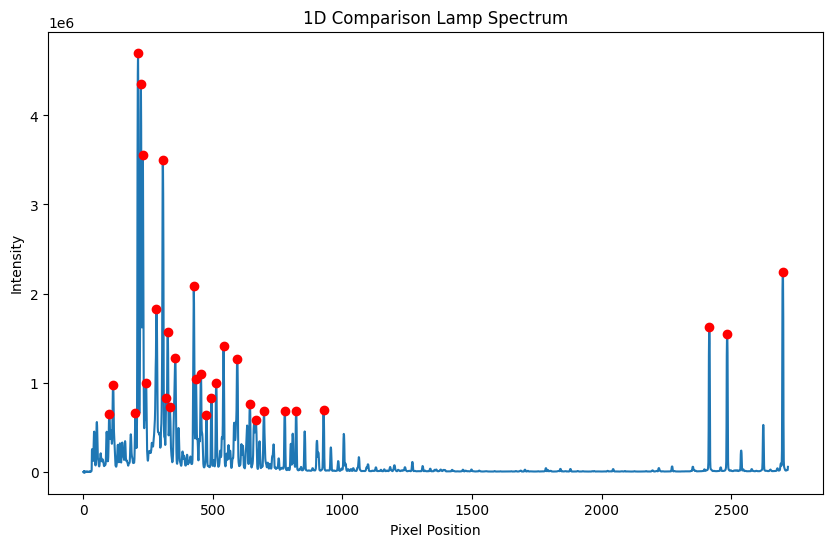

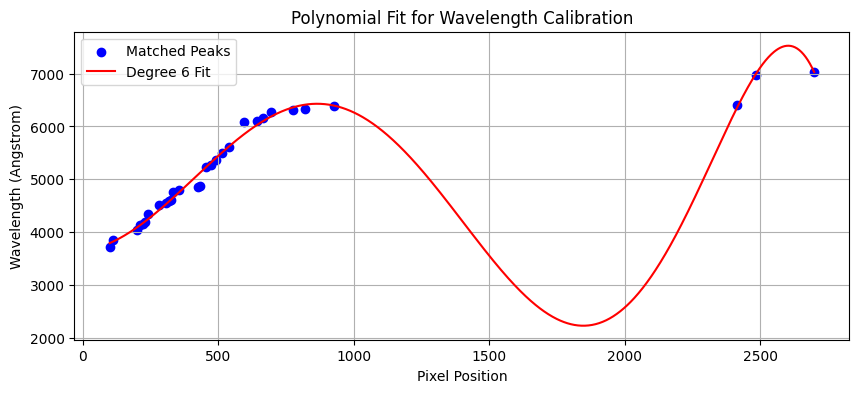

In [124]:
from numpy.polynomial import Polynomial
from scipy.signal import find_peaks

peaks, properties = find_peaks(comp_spectrum_1d)

# Sort peaks by intensity and select the 10 most intense peaks                                      done
peak_intensities = properties['peak_heights'] = comp_spectrum_1d[peaks]
top_peaks_idx = np.argsort(peak_intensities)[-30:]  # Indices of the 10 highest peaks
top_peaks = peaks[top_peaks_idx]  # Pixel positions of the 10 highest peaks
top_peaks_intensity = comp_spectrum_1d[top_peaks]  # Intensities of the 10 highest peaks

sorted_peak_pixels = np.sort(top_peaks)

# known wavelengths in Angstroms
wavelengths = np.array([
3719.935, 3859.400, 4045.450,4131.830, 4158.590, 4199.860, 4348.064,4510.733,
4545.080, 4589.900, 4609.560,4764.890, 4806.070,4847.820,4879.900, 5227.300,
5269.650,5371.489,5496.210, 5606.732,6074.338,6096.1630,6163.594,6266.495,
6304.850,6334.428,6382.991 ,6402.246,6965.4300,7032.4127
])

sorted_known_wavelengths = np.sort(wavelengths)

print(len(sorted_peak_pixels))


# Plot the 1D comparison spectrum with the 10 most intense peaks marked
plt.figure(figsize=(10, 6))
plt.plot(comp_spectrum_1d, label='Comparison Spectrum')
plt.plot(top_peaks, top_peaks_intensity, 'ro', label='Top 10 Intense Peaks')
plt.xlabel('Pixel Position')
plt.ylabel('Intensity')
plt.title('1D Comparison Lamp Spectrum')



# 3. Fit a polynomial (linear or quadratic depending on distortion)
fit_poly = Polynomial.fit(sorted_peak_pixels, sorted_known_wavelengths, deg=6)

# 4. Apply the mapping to convert pixels to wavelengths
pixel_indices = np.arange(len(comp_spectrum_1d))
calibrated_wavelengths = fit_poly(pixel_indices)

plt.figure(figsize=(10, 4))

# Scatter of known data points
plt.scatter(sorted_peak_pixels, sorted_known_wavelengths, color='blue', label='Matched Peaks')

# Polynomial fit curve
x_fit = np.linspace(min(sorted_peak_pixels), max(sorted_peak_pixels), 1000)
y_fit = fit_poly(x_fit)
plt.plot(x_fit, y_fit, color='red', label=f'Degree {fit_poly.degree()} Fit')

plt.xlabel("Pixel Position")
plt.ylabel("Wavelength (Angstrom)")
plt.title("Polynomial Fit for Wavelength Calibration")
plt.grid(True)
plt.legend()
plt.show()


In [125]:
def plot_wavelength_pixel_solution(
    spectrum, pixel_positions, wavelength_values, wavelength_labels=None, annotate=True,
    figsize=(12, 5), invert_x=False, xlim=None, ylim=None
):

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(spectrum*150, label='1D Spectrum')
    ax.set_xlabel("Pixel Position")
    ax.set_ylabel("Intensity")
    ax.set_title("1D Spectrum with Known Line Positions")
    ax.grid(True)

    for i, pix in enumerate(pixel_positions):
        wl = wavelength_values[i]
        label = f"{wl:.1f} "
        if wavelength_labels is not None:
            label += f" ({wavelength_labels[i]})"
        ax.axvline(pix, color='red', linestyle='--', alpha=0.5)
        if annotate:
            ax.text(pix, spectrum[int(pix)] -2000000, label,
                    rotation=90, ha='right', va='bottom', fontsize=12, color='red')

    if invert_x:
        ax.invert_xaxis()
    if xlim:
        ax.set_xlim(*xlim)
    if ylim:
        ax.set_ylim(*ylim)

    plt.tight_layout()
    plt.show()                                                                              #done


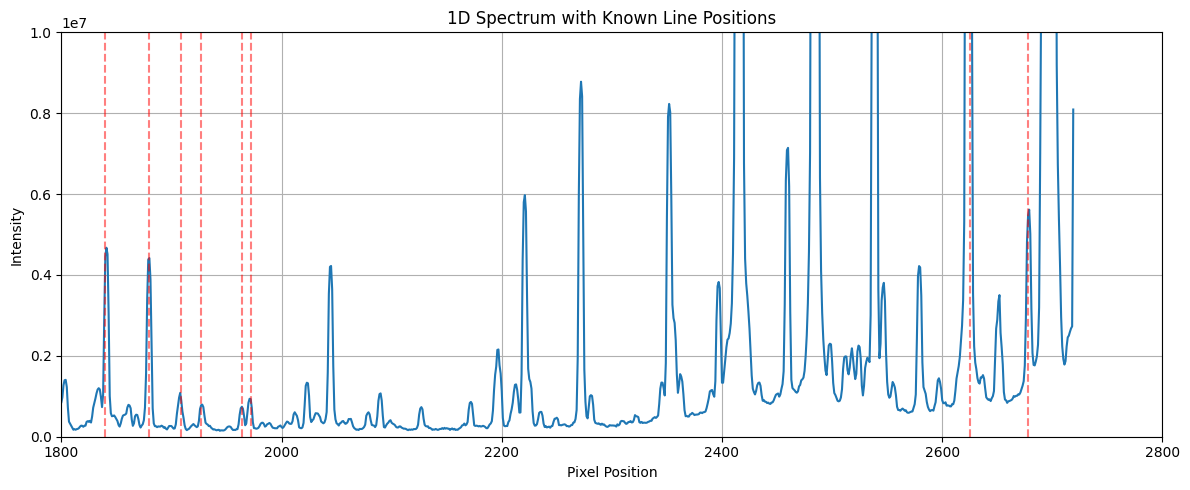

In [126]:
pixels_solution = np.array([210, 306, 435, 495, 512,540, 643,755,777,808,822,927,955,985,1005,1240,1270,1338,1422,
                            1497,1785, 1793,1840,1880,1909,1927,1964,1972,2625,2678])
wavelength_solution = np.array([3719.935, 3859.400, 4045.450,4131.830, 4158.590, 4199.860, 4348.064,4510.733,
                                4545.080, 4589.900, 4609.560,4764.890, 4806.070,4847.820,4879.900, 5227.300,
                                5269.650,5371.489,5496.210, 5606.732,6074.338,6096.1630,6163.594,6266.495,
                               6304.850,6334.428,6382.991 ,6402.246,6965.4300,7032.4127 ])#7383.980, 7514.651])
wavelength_label = np.array(["FeI", "FeI", "FeI" ,"ArII","ArI", "ArI","FeI", "ArII", "ArII", "AII","AII","AII","AII",
                             "AII","AII","AII", "AII","FeI","FeI","FeI", "AI","NeI","NeI","NeI","NeI","NeI","NeI",
                            "NeI","NeI","AI"])

plot_wavelength_pixel_solution(
    comp_spectrum_1d,
    pixels_solution,
    wavelength_solution,
    wavelength_labels=wavelength_label,
    annotate=False,
    invert_x=False,
    xlim=(1800,2800),
    ylim=(0,10e6)                                                                       #done
)


Polynomial coefficients: [-1.68082161e-07  6.07623135e-04  8.74859751e-01  3.55690971e+03]


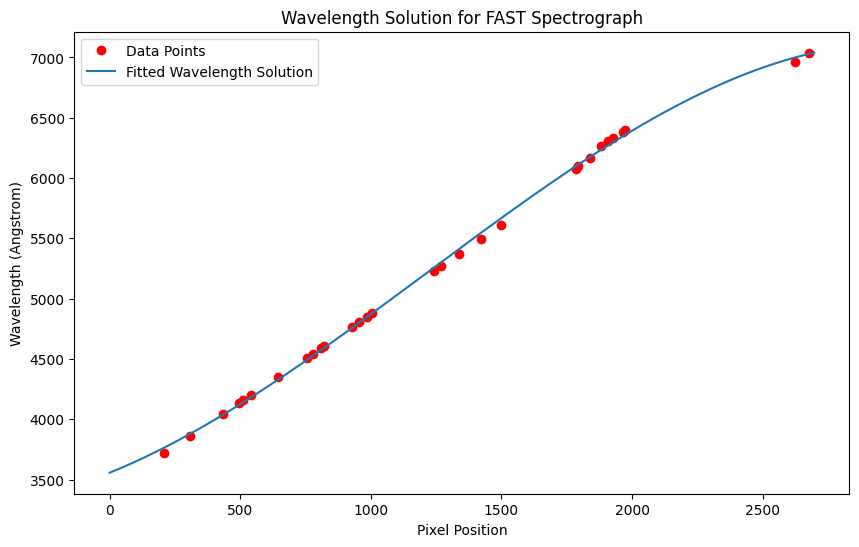

In [127]:
# Define a polynomial function to fit the data                                                                    done
from scipy.optimize import curve_fit

def polynomial(x, a, b, c, d):
    return  a * x**3 + b * x**2 + c * x + d

# Fit the polynomial to the data
popt, pcov = curve_fit(polynomial, pixels_solution, wavelength_solution,)
a, b, c, d = popt

# Print out the polynomial coefficients
print("Polynomial coefficients:", popt)

# Generate wavelengths using the polynomial solution across the full pixel range
pixel_range = np.arange(0, max(pixels_solution) +20)
calibrated_wavelengths = polynomial(pixel_range, *popt)

# Plot the original data points and the fitted polynomial solution
plt.figure(figsize=(10, 6))
plt.plot(pixels_solution, wavelength_solution, 'ro', label='Data Points')
plt.plot(pixel_range, calibrated_wavelengths, label='Fitted Wavelength Solution')
plt.xlabel('Pixel Position')
plt.ylabel('Wavelength (Angstrom)')
plt.title('Wavelength Solution for FAST Spectrograph')
plt.legend()
plt.show()

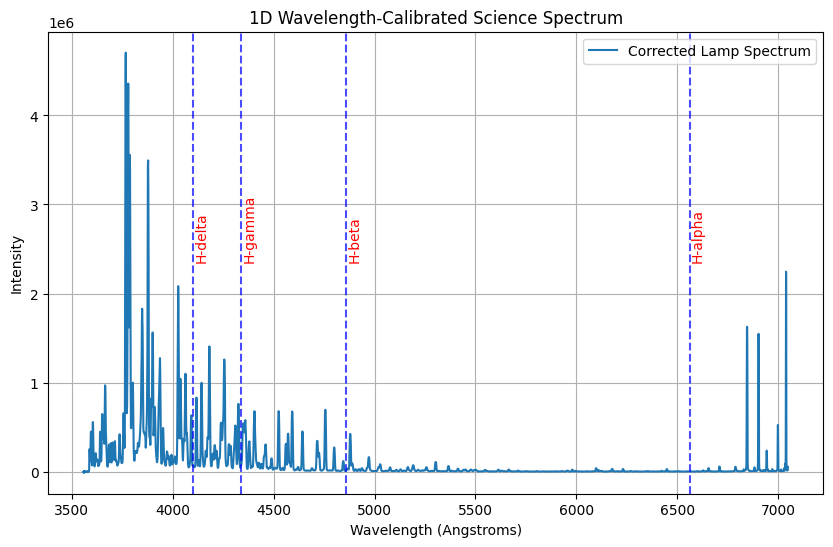

In [128]:
coeffs = [-1.68082148e-07, 6.07623080e-04, 8.74859821e-01, 3.55690968e+03]

def apply_wavelength_solution(pixels, coeffs):
    return np.polyval(coeffs, pixels)



science_file = os.path.join("drive/MyDrive/Astro_Data/0069.NGC4151.fits")

corrected_science_image, raw_science_image = process_science_image(science_file, combined_bias, combined_flat)
science_spectrum_1d = np.sum(corrected_science_image, axis=0)
pixels = np.arange(len(comp_spectrum_1d))

wavelength_solution_adjusted = apply_wavelength_solution(pixels, coeffs)
wavelength_solution_adjusted_science = apply_wavelength_solution(pixels, coeffs)

# Define only the H-alpha spectral line
lines = {
    'H-alpha': 6563,
    'H-beta': 4861,
    'H-gamma': 4340,
    'H-delta': 4101
}

def plot_1d_spectrum_with_lines(wavelengths, spectrum_1d):
    plt.figure(figsize=(10, 6))

    # Plot the 1D spectrum
    plt.plot(wavelengths, spectrum_1d, label='Corrected Lamp Spectrum')
    plt.xlabel('Wavelength (Angstroms)')
    plt.ylabel('Intensity')
    plt.title('1D Wavelength-Calibrated Science Spectrum')
    plt.grid(True)

    # Plot the vertical line for the H-alpha line
    for line_name, line_wavelength in lines.items():
        plt.axvline(x=line_wavelength, color='blue', linestyle='--', alpha=0.7)
        plt.text(line_wavelength +5, np.max(spectrum_1d) * 0.5, line_name, rotation=90, verticalalignment='bottom', color='red')

    plt.legend()
    plt.show()

# Plot the 1D spectrum with only the H-alpha line using the wavelength solution
plot_1d_spectrum_with_lines(wavelength_solution_adjusted, comp_spectrum_1d)

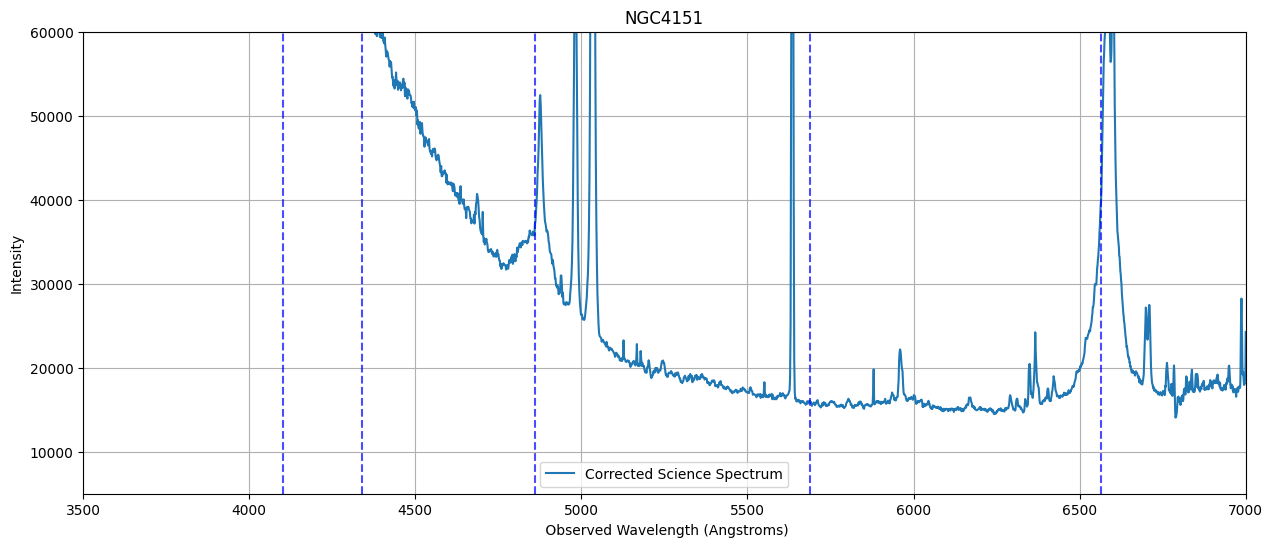

In [129]:
def plot_1d_spectrum_with_lines(wavelengths, spectrum_1d):
    plt.figure(figsize=(15, 6))

    # Plot the 1D spectrum
    plt.plot(wavelengths, spectrum_1d, label='Corrected Science Spectrum')
    plt.xlabel(' Observed Wavelength (Angstroms)')
    plt.ylabel('Intensity')
    plt.title('NGC4151')
    plt.grid(True)

    # Plot the vertical line for the H-alpha line
    for line_name, line_wavelength in lines.items():
        plt.axvline(x=line_wavelength, color='blue', linestyle='--', alpha=0.7)
        #plt.text(line_wavelength +5, np.max(spectrum_1d) * 0.5, line_name, rotation=90, verticalalignment='bottom', color='red')

        #plt.axvline(color='blue', linestyle='--', alpha=0.7, x=4876)
    plt.axvline(x=5688, color='blue', linestyle='--', alpha=0.7)
    plt.xlim(3500, 7000)
    plt.ylim(5000, 60000)
    plt.legend()
    plt.show()



plot_1d_spectrum_with_lines(wavelength_solution_adjusted_science, science_spectrum_1d)

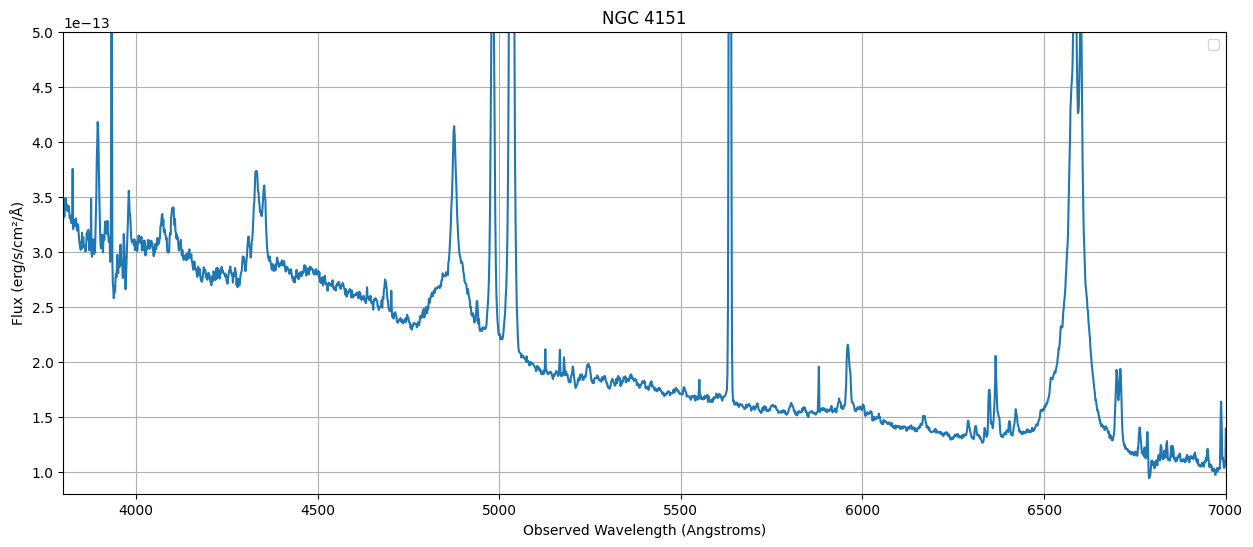

In [130]:
def plot_1d_spectrum_with_lines(wavelengths, spectrum_1d, ylimit=None):
    plt.figure(figsize=(15, 6))

    # Plot the 1D spectrum                                                          done.  next
    plt.plot(wavelengths, spectrum_1d)
    plt.xlabel('Observed Wavelength (Angstroms)')
    plt.ylabel('Flux (erg/s/cm²/Å)')
    plt.title('NGC 4151')
    plt.grid(True)

    # Plot the vertical line for the H-alpha line
    #for line_name, line_wavelength in lines.items():
        #plt.axvline(x=line_wavelength, color='red', linestyle='--', alpha=0.7)
    plt.xlim(3800, 7000)

    # If ylimit is provided, use it for the y-axis limits
    if ylimit:
        plt.ylim(ylimit)

    plt.legend()
    plt.show()

    # 1. Apply the same smoothed sensitivity function
science_flux_calibrated = science_spectrum_1d * sensitivity_smoothed

# 2. Plot the flux-calibrated spectrum with custom y-limits
plot_1d_spectrum_with_lines(wavelength_solution_adjusted_science, science_flux_calibrated, ylimit=(0.8e-13, 5e-13))

# 3. Save to file
np.savetxt('flux_calibrated_4151.txt',
           np.column_stack((wavelength_solution_adjusted_science, science_flux_calibrated)),
           header='Wavelength (Angstroms)    Flux (erg/s/cm^2/Angstrom)')

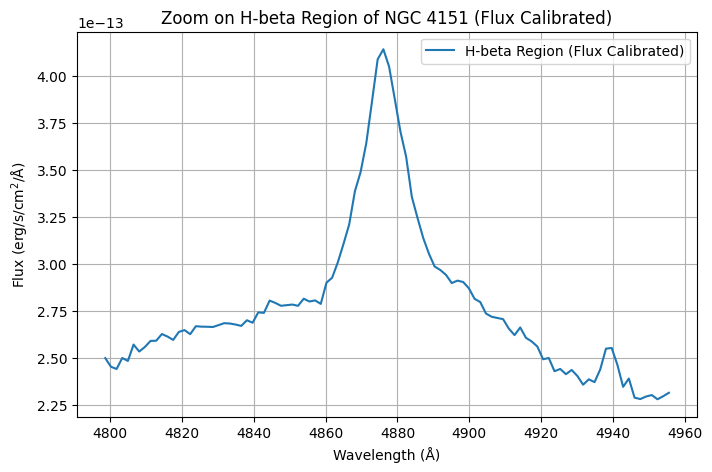

In [131]:
# Define the zoom-in region around H-beta
hbeta_center = 4861 * (1 + 0.0033)  # Apply small redshift correction
window = 80  # +/- 80 Å window

# Find indices corresponding to the H-beta region
mask = (wavelength_solution_adjusted_science > hbeta_center - window) & \
       (wavelength_solution_adjusted_science < hbeta_center + window)

wavelength_hbeta = wavelength_solution_adjusted_science[mask]
spectrum_hbeta = science_flux_calibrated[mask]  # <-- Now use flux-calibrated spectrum!

# Plot to check
plt.figure(figsize=(8, 5))
plt.plot(wavelength_hbeta, spectrum_hbeta, label='H-beta Region (Flux Calibrated)')
plt.xlabel('Wavelength (Å)')
plt.ylabel(r'Flux (erg/s/cm$^2$/Å)')
plt.title('Zoom on H-beta Region of NGC 4151 (Flux Calibrated)')
plt.grid(True)
plt.legend()
plt.show()


In [132]:
def two_gaussians_plus_baseline(wavelength, amp1, cen1, sigma1, amp2, cen2, sigma2, baseline):
    gauss1 = amp1 * np.exp(-(wavelength - cen1)**2 / (2 * sigma1**2))  # narrow
    gauss2 = amp2 * np.exp(-(wavelength - cen2)**2 / (2 * sigma2**2))  # broad
    return gauss1 + gauss2 + baseline


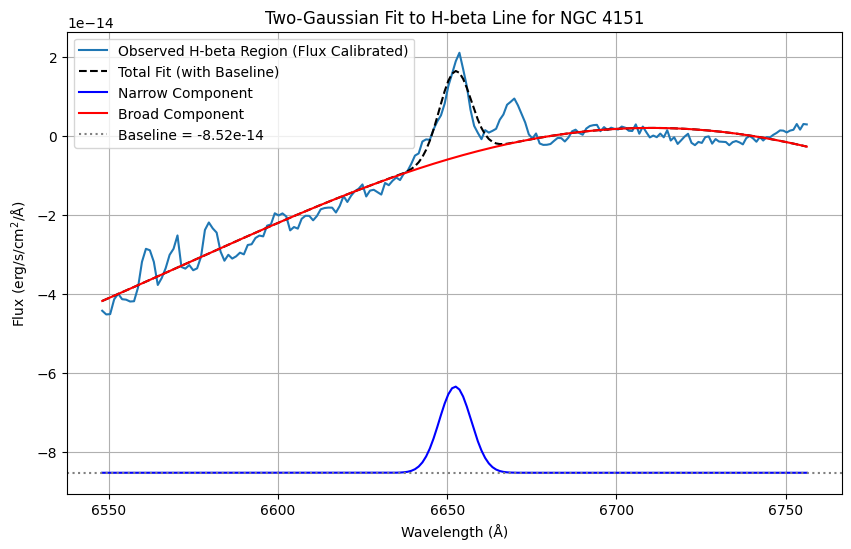

In [133]:
# Initial guesses
amp1_guess = np.max(flux_fit_subtracted)
cen1_guess = hb_obs
sigma1_guess = 2

amp2_guess = np.max(flux_fit_subtracted) / 2
cen2_guess = hb_obs
sigma2_guess = 10

baseline_guess = -0.25

initial_guess = [amp1_guess, cen1_guess, sigma1_guess, amp2_guess, cen2_guess, sigma2_guess, baseline_guess]

# Fit using curve_fit
popt, pcov = curve_fit(two_gaussians_plus_baseline, wave_fit, flux_fit_subtracted, p0=initial_guess)

# Extract fitted parameters
amp1, cen1, sigma1, amp2, cen2, sigma2, baseline = popt

# Make the fitted curves
fit_curve = two_gaussians_plus_baseline(wave_fit, *popt)
gauss_narrow = amp1 * np.exp(-(wave_fit - cen1)**2 / (2 * sigma1**2))
gauss_broad = amp2 * np.exp(-(wave_fit - cen2)**2 / (2 * sigma2**2))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(wave_fit, flux_fit_subtracted, label='Observed H-beta Region (Flux Calibrated)')
plt.plot(wave_fit, fit_curve, label='Total Fit (with Baseline)', color='black', linestyle='--')
plt.plot(wave_fit, gauss_narrow + baseline, label='Narrow Component', color='blue')
plt.plot(wave_fit, gauss_broad + baseline, label='Broad Component', color='red')
plt.axhline(baseline, color='gray', linestyle=':', label=f'Baseline = {baseline:.2e}')
plt.xlabel('Wavelength (Å)')
plt.ylabel(r'Flux (erg/s/cm$^2$/Å)')
plt.title('Two-Gaussian Fit to H-beta Line for NGC 4151')
plt.legend()
plt.grid(True)
plt.show()


In [134]:
# --- Calculate FWHM of the Broad Component (sigma2 comes from the broad Gaussian)

# FWHM in Angstroms (Gaussian relation: FWHM = 2.355 * sigma)
fwhm_angstroms = 2.355 * sigma2

# Rest-frame wavelength of H-beta
hb_rest = 4861  # Angstroms

# Convert FWHM from Angstroms to km/s using Doppler formula
fwhm_kms = (fwhm_angstroms / hb_rest) * 3e5  # 3e5 km/s is speed of light

# Print results
print(f"Broad Component FWHM ≈ {fwhm_angstroms:.2f} Å ≈ {fwhm_kms:.0f} km/s")


Broad Component FWHM ≈ 323.72 Å ≈ 19979 km/s


In [135]:


# 1. Define a window around 5100 Å
window_center = 5100 * (1 + 0.0033)  # Redshifted center
window_width = 50  # +/- 50 Å

mask_5100 = (wavelength_solution_adjusted_science > window_center - window_width) & \
            (wavelength_solution_adjusted_science < window_center + window_width)

wave_5100 = wavelength_solution_adjusted_science[mask_5100]
flux_5100 = science_flux_calibrated[mask_5100]

# 2. Average flux density f_lambda (in erg/s/cm²/Å)
f_lambda_5100 = np.mean(flux_5100)

# 3. Luminosity Distance D_L for NGC 4151
DL_Mpc = 15.8  # Mpc
DL_cm = DL_Mpc * 3.086e24  # convert to cm

# 4. Monochromatic luminosity at 5100 Å
L_5100 = 4 * np.pi * DL_cm**2 * f_lambda_5100  # erg/s/Å

print(f"f_lambda(5100) = {f_lambda_5100:.2e} erg/s/cm^2/Å")
print(f"L_lambda(5100) = {L_5100:.2e} erg/s/Å")


f_lambda(5100) = 1.94e-13 erg/s/cm^2/Å
L_lambda(5100) = 5.79e+39 erg/s/Å


In [136]:
# Black hole mass calculation

# Constants from empirical relation
a = 6.91
b = 0.5

# Compute log values
log_L = np.log10(L_5100 / 1e44)
log_FWHM = np.log10(fwhm_kms / 1000)

# Final formula
log_M_BH = a + b * log_L + 2 * log_FWHM
M_BH = 10**log_M_BH

print(f"Log(M_BH/M_sun) = {log_M_BH:.2f}")
print(f"M_BH ≈ {M_BH:.2e} M_sun")

# Include 0.4 dex uncertainty
dex_uncertainty = 0.4

# Upper and lower limits in log space
log_M_BH_upper = log_M_BH + dex_uncertainty
log_M_BH_lower = log_M_BH - dex_uncertainty

# Convert back to linear space
M_BH_upper = 10**log_M_BH_upper
M_BH_lower = 10**log_M_BH_lower

# Report results
print(f"Log(M_BH/M_sun) = {log_M_BH:.2f} ± {dex_uncertainty:.1f} dex")
print(f"M_BH ≈ ({M_BH:.2e}) M_sun")
print(f"Range: ({M_BH_lower:.2e} - {M_BH_upper:.2e}) M_sun")


Log(M_BH/M_sun) = 7.39
M_BH ≈ 2.47e+07 M_sun
Log(M_BH/M_sun) = 7.39 ± 0.4 dex
M_BH ≈ (2.47e+07) M_sun
Range: (9.83e+06 - 6.20e+07) M_sun


In [137]:
# Constants in CGS
c = 2.998e10  # Speed of light in cm/s
eta = 0.1  # Radiative efficiency
Msun_g = 1.989e33  # Solar mass in grams
sec_per_year = 3.154e7  # Seconds per year

# Given L5100 (in erg/s)
L5100 = 5.8e39  # erg/s

# Bolometric correction
BC = 5  # Typical for Seyferts
L_bol = L5100 * BC  # erg/s

# Accretion rate in g/s
mdot_g_per_s = L_bol / (eta * c**2)

# Convert to solar masses per year
mdot_msun_per_year = (mdot_g_per_s / Msun_g) * sec_per_year

# Print the result
print(f"Accretion Rate ≈ {mdot_msun_per_year:.8f} M_sun/year")



Accretion Rate ≈ 0.00000512 M_sun/year


Reading in the bias frames now
Created the master bias
Reading in the flat frames now


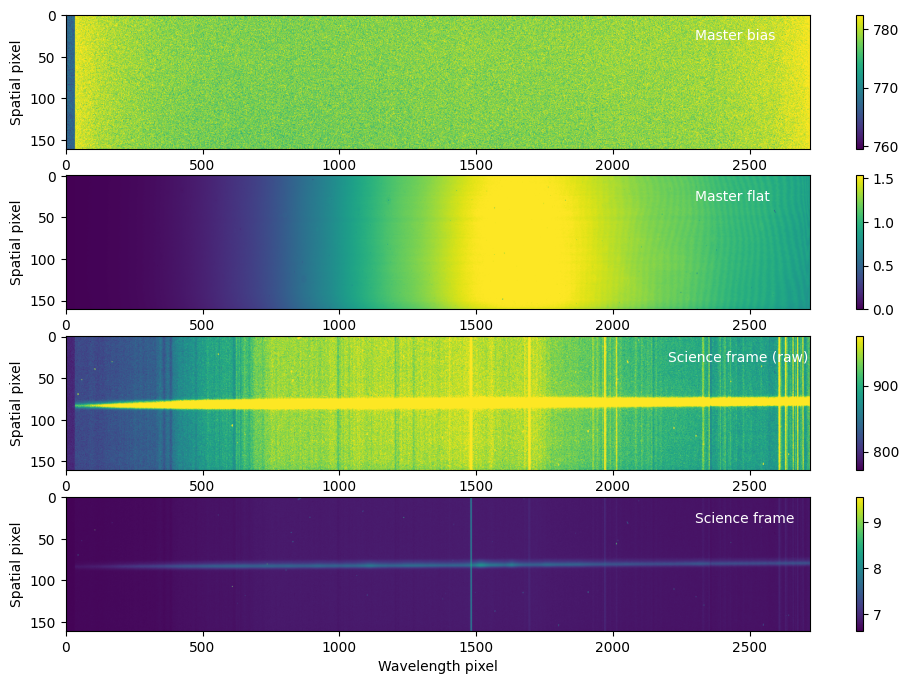

In [138]:
fl = glob.glob('drive/MyDrive/Astro_Data/*BIAS*.fits')

master_bias = []

print("Reading in the bias frames now")
for fn in fl:
  data = fits.getdata(fn)
  master_bias.append(data[None])

master_bias = np.concatenate(master_bias, axis=0)
master_bias = np.median(master_bias, axis=0)
print("Created the master bias")

fl = glob.glob('drive/MyDrive/Astro_Data/*FLAT*.fits')

master_flat = []

print("Reading in the flat frames now")

for fn in fl:
  data = fits.getdata(fn)
  data = data - master_bias
  master_flat.append(data[None])

master_flat = np.concatenate(master_flat, axis=0)
master_flat = np.median(master_flat, axis=0)
master_flat = master_flat / np.median(master_flat)

fig = plt.figure(figsize=(12,8))

plt.subplot(411)
plt.imshow(master_bias, aspect='auto', vmax=np.percentile(master_bias, 90))
plt.colorbar()
plt.text(2300, 30, 'Master bias', color='white')
plt.ylabel('Spatial pixel')

plt.subplot(412)
plt.imshow(master_flat, aspect='auto', vmax=np.percentile(master_flat, 90))
plt.colorbar()
plt.text(2300, 30, 'Master flat', color='white')
plt.ylabel('Spatial pixel')

plt.subplot(413)
fl = glob.glob('drive/MyDrive/Astro_Data/*3C273*.fits')
fn = fl[0]
data = fits.getdata(fn)

plt.imshow(data, aspect='auto', vmax=np.percentile(data, 90))
plt.text(2200, 30, 'Science frame (raw)', color='white')
plt.colorbar()
plt.ylabel('Spatial pixel')

plt.subplot(414)
data2 = data - master_bias
reduced = data / master_flat

plt.imshow(np.log(data), aspect='auto', )
plt.xlabel('Wavelength pixel')
plt.ylabel('Spatial pixel')
plt.text(2300, 30, 'Science frame', color='white')
plt.colorbar()


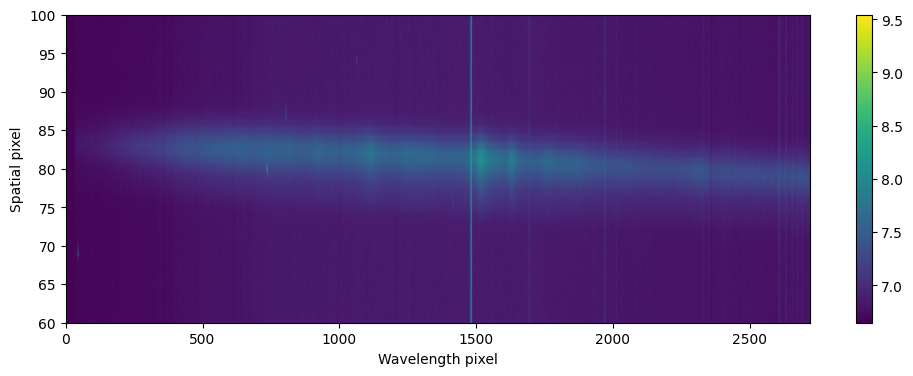

In [139]:
fig = plt.figure(figsize=(12,4))
plt.imshow(np.log(data), aspect='auto', )
plt.ylim(60, 100)
plt.xlabel('Wavelength pixel')
plt.ylabel('Spatial pixel')
plt.colorbar()

[]

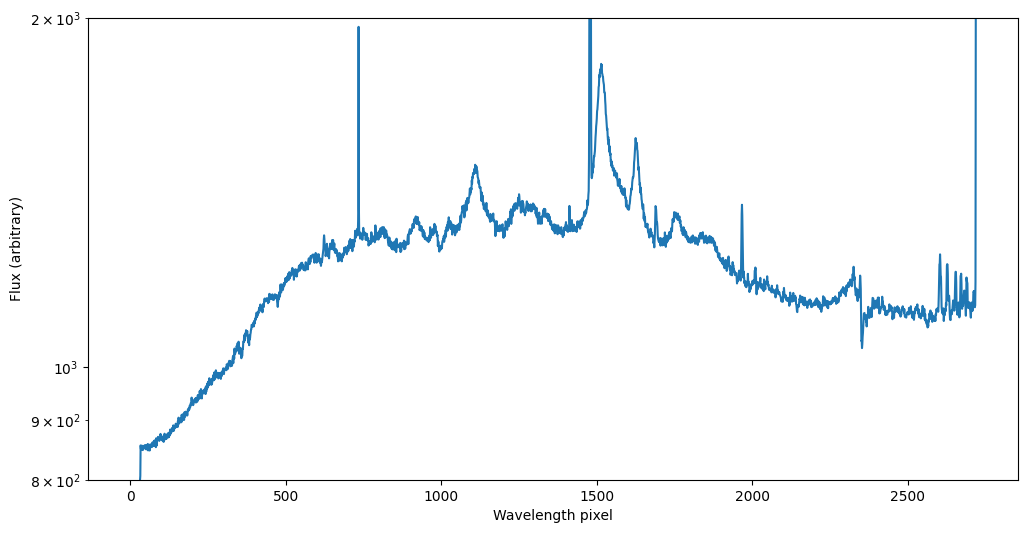

In [140]:
plt.figure(figsize=(12,6))
plt.plot(data[73:87].mean(0))
plt.xlabel('Wavelength pixel')
plt.ylabel('Flux (arbitrary)')
plt.ylim(8e2, 2e3)
plt.semilogy()

Next:

wavelength calibrate,

find broad emission lines,

fit a gaussian to the broad line,

find FWHM (velocity dispersion) $$v=\frac{FWHM_{\lambda}}{\lambda_{0}}\times c$$

measure continuum luminosity,

estimate BLR radius,

measure BH mass,

estimate bolometric luminosity,

calculate Eddington luminosity and Eddington ratio,


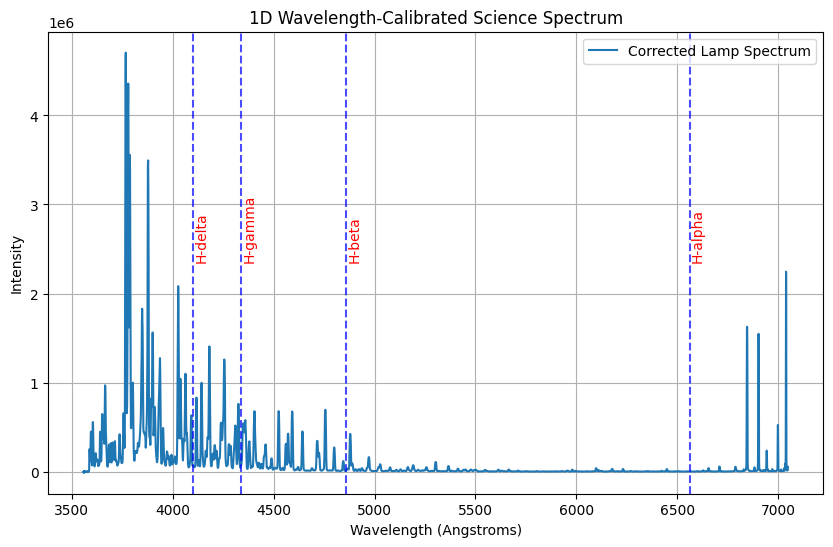

In [141]:
coeffs = [-1.68082148e-07, 6.07623080e-04, 8.74859821e-01, 3.55690968e+03]

def apply_wavelength_solution(pixels, coeffs):
    return np.polyval(coeffs, pixels)



science_file = os.path.join("drive/MyDrive/Astro_Data/0062.3C273.fits")

corrected_science_image, raw_science_image = process_science_image(science_file, combined_bias, combined_flat)
science_spectrum_1d = np.sum(corrected_science_image, axis=0)
pixels = np.arange(len(comp_spectrum_1d))

wavelength_solution_adjusted = apply_wavelength_solution(pixels, coeffs)
wavelength_solution_adjusted_science = apply_wavelength_solution(pixels, coeffs)

# Define only the H-alpha spectral line
lines = {
    'H-alpha': 6563,
    'H-beta': 4861,
    'H-gamma': 4340,
    'H-delta': 4101
}

def plot_1d_spectrum_with_lines(wavelengths, spectrum_1d):
    plt.figure(figsize=(10, 6))

    # Plot the 1D spectrum
    plt.plot(wavelengths, spectrum_1d, label='Corrected Lamp Spectrum')
    plt.xlabel('Wavelength (Angstroms)')
    plt.ylabel('Intensity')
    plt.title('1D Wavelength-Calibrated Science Spectrum')
    plt.grid(True)

    # Plot the vertical line for the H-alpha line
    for line_name, line_wavelength in lines.items():
        plt.axvline(x=line_wavelength, color='blue', linestyle='--', alpha=0.7)
        plt.text(line_wavelength +5, np.max(spectrum_1d) * 0.5, line_name, rotation=90, verticalalignment='bottom', color='red')

    plt.legend()
    plt.show()

# Plot the 1D spectrum with only the H-alpha line using the wavelength solution
plot_1d_spectrum_with_lines(wavelength_solution_adjusted, comp_spectrum_1d)

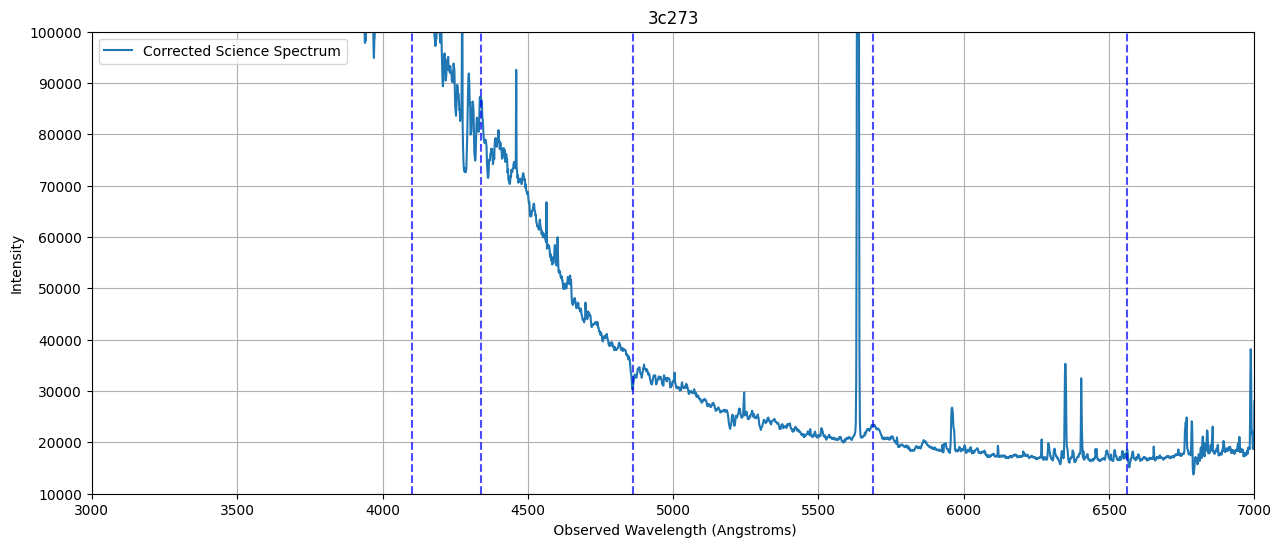

In [142]:
def plot_1d_spectrum_with_lines(wavelengths, spectrum_1d):
    plt.figure(figsize=(15, 6))

    # Plot the 1D spectrum
    plt.plot(wavelengths, spectrum_1d, label='Corrected Science Spectrum')
    plt.xlabel(' Observed Wavelength (Angstroms)')
    plt.ylabel('Intensity')
    plt.title('3c273')
    plt.grid(True)

    # Plot the vertical line for the H-alpha line
    for line_name, line_wavelength in lines.items():
        plt.axvline(x=line_wavelength, color='blue', linestyle='--', alpha=0.7)
        #plt.text(line_wavelength +5, np.max(spectrum_1d) * 0.5, line_name, rotation=90, verticalalignment='bottom', color='red')

        #plt.axvline(color='blue', linestyle='--', alpha=0.7, x=4876)
    plt.axvline(x=5688, color='blue', linestyle='--', alpha=0.7)
    plt.xlim(3000, 7000)
    plt.ylim(10000, 100000)
    plt.legend()
    plt.show()



plot_1d_spectrum_with_lines(wavelength_solution_adjusted_science, science_spectrum_1d)

In [143]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from scipy.interpolate import interp1d


In [144]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.visualization import astropy_mpl_style
from os import listdir
from scipy.ndimage import shift


['0015.FLAT.fits', '0017.FLAT.fits', '0014.FLAT.fits', '0012.FLAT.fits', '0020.FLAT.fits', '0019.FLAT.fits', '0021.FLAT.fits', '0011.FLAT.fits', '0018.FLAT.fits', '0013.FLAT.fits', '0016.FLAT.fits']
Matched bias files: ['0002.BIAS.fits', '0004.BIAS.fits', '0010.BIAS.fits', '0005.BIAS.fits', '0008.BIAS.fits', '0007.BIAS.fits', '0006.BIAS.fits', '0009.BIAS.fits', '0001.BIAS.fits', '0003.BIAS.fits']
Matched flat files: ['0015.FLAT.fits', '0017.FLAT.fits', '0014.FLAT.fits', '0012.FLAT.fits', '0020.FLAT.fits', '0019.FLAT.fits', '0021.FLAT.fits', '0011.FLAT.fits', '0018.FLAT.fits', '0013.FLAT.fits', '0016.FLAT.fits']
Combined bias shape: (161, 2720)
Combined flat shape: (161, 2720)
All files in directory:
0002.BIAS.fits
0004.BIAS.fits
0010.BIAS.fits
0063.COMP.fits
0062.3C273.fits
0005.BIAS.fits
0069.NGC4151.fits
0015.FLAT.fits
0017.FLAT.fits
0070.COMP.fits
0008.BIAS.fits
0014.FLAT.fits
0012.FLAT.fits
0007.BIAS.fits
0006.BIAS.fits
0048.COMP.fits
0020.FLAT.fits
0019.FLAT.fits
0021.FLAT.fits
00

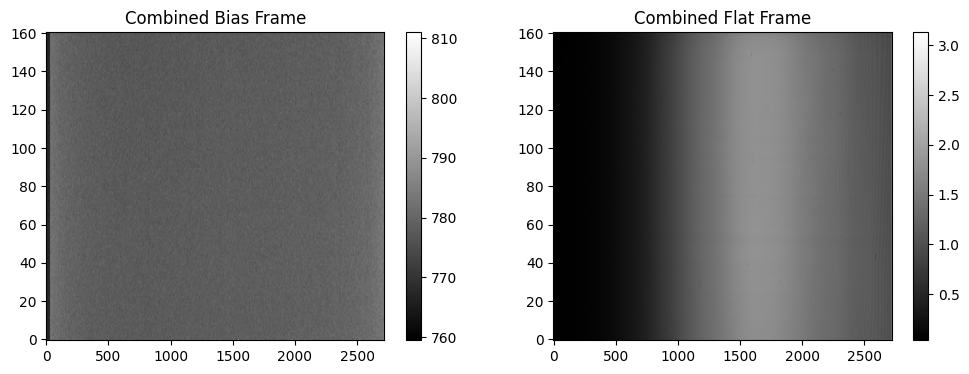

In [145]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Define the directory and file patterns
directory = 'drive/MyDrive/Astro_Data/'
bias_file_pattern = 'BIAS'
flat_file_pattern = 'FLAT'

# Specific file numbers to include
bias_numbers = {'0001','0002','0003', '0004','0005','0006','0007','0008','0009','0010'}
flat_numbers = {'0011','0012','0013','0014', '0015','0016', '0017', '0018','0019','0020','0021'}

# List and filter all files in the directory
all_files = os.listdir(directory)
bias_files = [file for file in all_files if file.split('.')[0] in bias_numbers and 'BIAS' in file]
flat_files = [file for file in all_files if file.split('.')[0] in flat_numbers and 'FLAT' in file]
print(flat_files)

print("Matched bias files:", bias_files)
print("Matched flat files:", flat_files)

# Load and trim the top BIAS files
bias_data = []
for file in bias_files:
    file_path = os.path.join(directory, file)
    with fits.open(file_path) as hdul:
        trimmed_data = hdul[0].data[:, :]  # Trim each bias file
        bias_data.append(trimmed_data)

# Combine all bias data by taking the median
combined_bias = np.median(np.array(bias_data), axis=0)

# Load and combine the top FLAT files, normalized and trimmed
flat_data = []
for file in flat_files:
    file_path = os.path.join(directory, file)
    with fits.open(file_path) as hdul:
        trimmed_flat_data = hdul[0].data[:, :]  # Apply trimming
        flat_data.append(trimmed_flat_data / np.mean(trimmed_flat_data))

# Combine all flat data by taking the median
combined_flat = np.median(np.array(flat_data), axis=0)

# Combine all flat data by taking the median across the array
combined_flat = np.median(np.array(flat_data), axis=0)

# Prepare pixel range for trimmed data
pixels = np.arange(0, combined_flat.shape[-1])

# Calculate the mean flat for polynomial fitting
mean_flat = np.mean(combined_flat, axis=0)

# Iteratively find the best polynomial degree (without weighting)
min_residual = np.inf
best_degree = 0

for degree in range(1, 10):  # Test polynomial degrees from 1 to 9
    p = np.polynomial.Polynomial.fit(pixels, mean_flat, degree)
    poly_fit = p(pixels)
    residual = np.sum((mean_flat - poly_fit) ** 2)  # Sum of squared residuals

    if residual < min_residual:
        min_residual = residual
        best_degree = degree

# Use the best degree found
p_best = np.polynomial.Polynomial.fit(pixels, mean_flat, best_degree)
poly_fit_best = p_best(pixels)

# Normalize the flat field
normalized_flat = combined_flat / (mean_flat / poly_fit_best)


# Function to process science images with bias subtraction, flat correction, and trimming
def process_science_image(science_file, combined_bias, combined_flat):
    with fits.open(science_file) as hdul:
        # Trim the science image to match the bias and flat dimensions
        science_image = hdul[0].data[:, :]

        # Subtract bias and apply flat-field correction
        bias_subtracted_image = science_image - combined_bias
        flat_corrected_image = bias_subtracted_image / combined_flat

        return flat_corrected_image, science_image


# Visualization for combined bias and flat frames
def plot_bias_and_flat(combined_bias, combined_flat):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(combined_bias, cmap='gray', origin='lower', aspect='auto')
    plt.colorbar()
    plt.title('Combined Bias Frame')

    plt.subplot(1, 2, 2)
    plt.imshow(combined_flat, cmap='gray', origin='lower', aspect='auto')
    plt.colorbar()
    plt.title('Combined Flat Frame')

    plt.show()


# Function to raw plot 1D spectrum from a specific region in the image
def plot_1d_spectrum_raw(image_data, y_start=80, y_end=88):
    spectrum_1d = np.sum(image_data[y_start:y_end], axis=0)

    # Plot the extracted 1D spectrum
    plt.figure(figsize=(10, 4))
    plt.plot(np.arange(len(spectrum_1d)), spectrum_1d, color='black')
    plt.title('Extracted 1D Spectrum')
    plt.xlabel('X Pixel')
    plt.ylabel('Summed Intensity')
    plt.show()

# Function to plot 1D spectrum from a specific region in the image
def plot_1d_spectrum(image_data, y_start=80, y_end=88):
    spectrum_1d = np.sum(image_data[y_start:y_end], axis=0)

    # Plot the 2D science image with highlighted region
    plt.figure(figsize=(12, 4))
    plt.imshow(image_data, cmap='gray', origin='lower', aspect='auto')
    plt.colorbar(label='Intensity')
    plt.axhline(y=y_start, color='red', linestyle='--', label='Extraction Start')
    plt.axhline(y=y_end, color='red', linestyle='--', label='Extraction End')
    plt.title('Science Image with Spectrum Extraction Region')
    plt.xlabel('X Pixel')
    plt.ylabel('Y Pixel')
    plt.ylim(78,100)
    plt.legend()
    plt.show()

    # Plot the extracted 1D spectrum
    plt.figure(figsize=(10, 5))
    plt.plot(np.arange(len(spectrum_1d)), spectrum_1d, color='black')
    plt.title('Extracted 1D Spectrum')
    plt.xlabel('X Pixel')
    plt.ylabel('Summed Intensity')
    plt.show()

# Function to visualize raw and corrected science images
def plot_science_images(raw_image, corrected_image):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(raw_image, cmap='gray', origin='lower', aspect='auto')
    plt.colorbar()
    plt.ylim(80,100)
    plt.title('Raw Science Image')

    plt.subplot(1, 2, 2)
    plt.imshow(corrected_image, cmap='gray', origin='lower', aspect='auto')
    plt.colorbar()
    plt.ylim(80,100)
    plt.title('Corrected Science Image')

    plt.show()

science_file = os.path.join("drive/MyDrive/Astro_Data/0047.Markarian421.fits")

print("Combined bias shape:", combined_bias.shape)
print("Combined flat shape:", combined_flat.shape)

print("All files in directory:")
for file in all_files:
    print(file)

plot_bias_and_flat(combined_bias, combined_flat)

# corrected_science_image, raw_science_image = process_science_image(science_file, combined_bias, combined_flat)
# plot_science_images(raw_science_image, corrected_science_image)


Viewing FITS file: drive/MyDrive/Astro_Data/0048.COMP.fits
Header:
SIMPLE  =                    T / Primary FITS image array                       
BITPIX  =                   16                                                  
NAXIS   =                    2 / NUMBER OF AXES                                 
NAXIS1  =                 2720 / CHIP WIDTH                                     
NAXIS2  =                  161 / CHIP HEIGHT                                    
EXTEND  =                    F / Fits standard                                  
OBJECT  = 'COMP              ' / OBJECT NAME                                    
NAMPS   =                    1                                                  
DATE    = '2025-03-19T03:55:12' / UT date/time at start                         
DATE-OBS= '2025-03-19        ' / UT date/time at start                          
RA      = '11:04:27.3141     ' / RA                                             
DEC     = '38:12:32.81       ' / DEC     

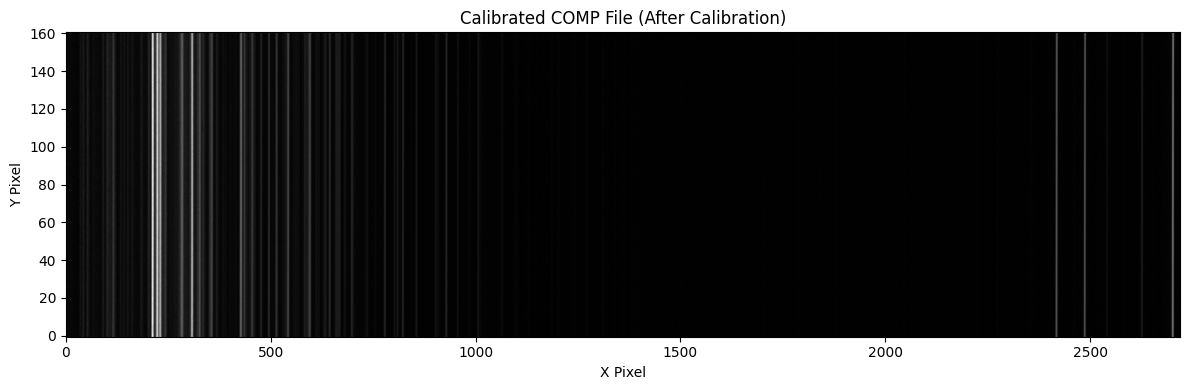

In [146]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.signal import find_peaks

# Define the directory and specific file
directory = 'drive/MyDrive/Astro_Data/'
comp_file = '0048.COMP.fits'  # Specify the COMP file you want to process

# Load the COMP file (before calibration)
comp_file_path = os.path.join(directory, comp_file)
with fits.open(comp_file_path) as hdul:
    comp_data_raw = hdul[0].data

    print(f"\nViewing FITS file: {comp_file_path}")
    print("Header:")
    print(repr(hdul[0].header))
    print("\nData shape:")
    print(hdul[0].data.shape)

# Trim the raw data (same trimming as for bias and flat)
comp_data_trimmed = comp_data_raw[:, :]

# Normalize and subtract bias (using combined bias data)
bias_subtracted_comp = comp_data_trimmed - combined_bias

# Trim both the bias-subtracted COMP data and the normalized flat to match the smaller size
min_width = min(bias_subtracted_comp.shape[1], normalized_flat.shape[1])

bias_subtracted_comp_trimmed = bias_subtracted_comp[:, :min_width]
normalized_flat_trimmed = normalized_flat[:, :min_width]

# Apply flat correction (normalize by combined flat)
calibrated_comp = bias_subtracted_comp_trimmed / normalized_flat_trimmed

# Plot the raw, trimmed, and calibrated COMP image
fig, axs = plt.subplots(1, 1, figsize=(12, 4))

# Display the calibrated COMP file
axs.imshow(calibrated_comp, cmap='gray', origin='lower', aspect='auto')
axs.set_title('Calibrated COMP File (After Calibration)')
axs.set_xlabel('X Pixel')
axs.set_ylabel('Y Pixel')

plt.tight_layout()
plt.show()

# Create a 1D spectrum by summing over the spatial dimension (Y-axis)
comp_spectrum_1d = np.sum(calibrated_comp, axis=0)



30


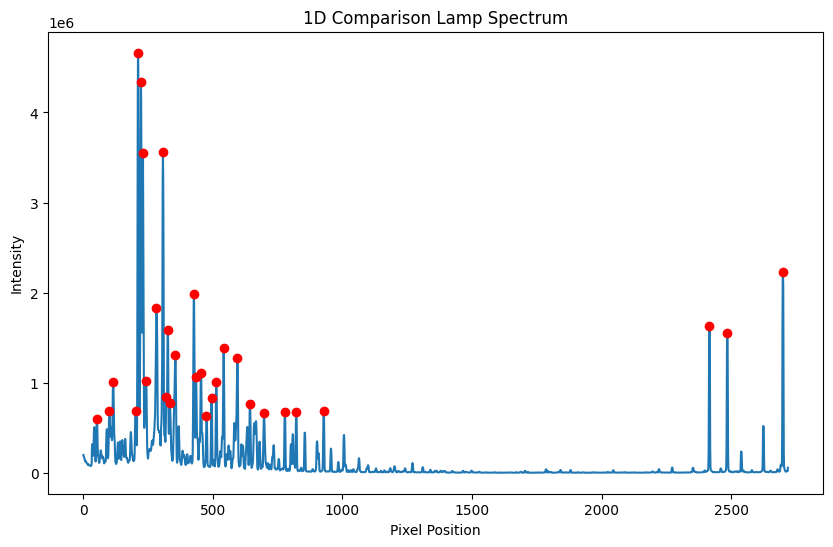

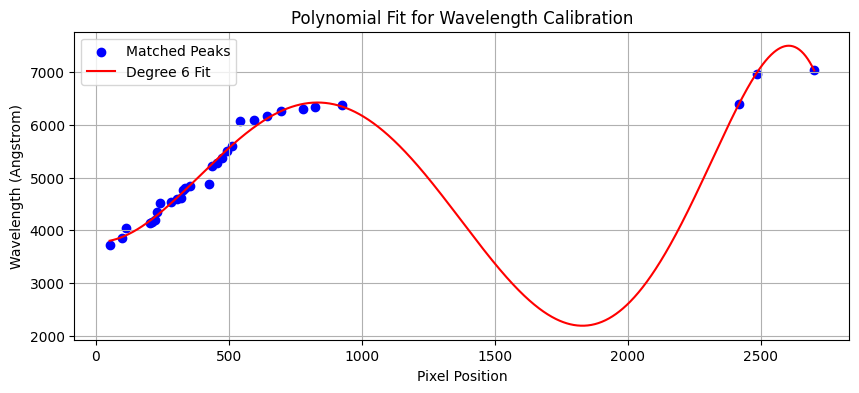

In [147]:
from numpy.polynomial import Polynomial
from scipy.signal import find_peaks

peaks, properties = find_peaks(comp_spectrum_1d)

# Sort peaks by intensity and select the 10 most intense peaks
peak_intensities = properties['peak_heights'] = comp_spectrum_1d[peaks]
top_peaks_idx = np.argsort(peak_intensities)[-30:]  # Indices of the 10 highest peaks
top_peaks = peaks[top_peaks_idx]  # Pixel positions of the 10 highest peaks
top_peaks_intensity = comp_spectrum_1d[top_peaks]  # Intensities of the 10 highest peaks

sorted_peak_pixels = np.sort(top_peaks)

# known wavelengths in Angstroms
wavelengths = np.array([
3719.935, 3859.400, 4045.450,4131.830, 4158.590, 4199.860, 4348.064,4510.733,
4545.080, 4589.900, 4609.560,4764.890, 4806.070,4847.820,4879.900, 5227.300,
5269.650,5371.489,5496.210, 5606.732,6074.338,6096.1630,6163.594,6266.495,
6304.850,6334.428,6382.991 ,6402.246,6965.4300,7032.4127
])

sorted_known_wavelengths = np.sort(wavelengths)

print(len(sorted_peak_pixels))


# Plot the 1D comparison spectrum with the 10 most intense peaks marked
plt.figure(figsize=(10, 6))
plt.plot(comp_spectrum_1d, label='Comparison Spectrum')
plt.plot(top_peaks, top_peaks_intensity, 'ro', label='Top 10 Intense Peaks')
plt.xlabel('Pixel Position')
plt.ylabel('Intensity')
plt.title('1D Comparison Lamp Spectrum')



# 3. Fit a polynomial (linear or quadratic depending on distortion)
fit_poly = Polynomial.fit(sorted_peak_pixels, sorted_known_wavelengths, deg=6)

# 4. Apply the mapping to convert pixels to wavelengths
pixel_indices = np.arange(len(comp_spectrum_1d))
calibrated_wavelengths = fit_poly(pixel_indices)

plt.figure(figsize=(10, 4))

# Scatter of known data points
plt.scatter(sorted_peak_pixels, sorted_known_wavelengths, color='blue', label='Matched Peaks')

# Polynomial fit curve
x_fit = np.linspace(min(sorted_peak_pixels), max(sorted_peak_pixels), 1000)
y_fit = fit_poly(x_fit)
plt.plot(x_fit, y_fit, color='red', label=f'Degree {fit_poly.degree()} Fit')

plt.xlabel("Pixel Position")
plt.ylabel("Wavelength (Angstrom)")
plt.title("Polynomial Fit for Wavelength Calibration")
plt.grid(True)
plt.legend()
plt.show()


In [148]:
def plot_wavelength_pixel_solution(
    spectrum, pixel_positions, wavelength_values, wavelength_labels=None, annotate=True,
    figsize=(12, 5), invert_x=False, xlim=None, ylim=None
):

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(spectrum*150, label='1D Spectrum')
    ax.set_xlabel("Pixel Position")
    ax.set_ylabel("Intensity")
    ax.set_title("1D Spectrum with Known Line Positions")
    ax.grid(True)

    for i, pix in enumerate(pixel_positions):
        wl = wavelength_values[i]
        label = f"{wl:.1f} "
        if wavelength_labels is not None:
            label += f" ({wavelength_labels[i]})"
        ax.axvline(pix, color='red', linestyle='--', alpha=0.5)
        if annotate:
            ax.text(pix, spectrum[int(pix)] -2000000, label,
                    rotation=90, ha='right', va='bottom', fontsize=12, color='red')

    if invert_x:
        ax.invert_xaxis()
    if xlim:
        ax.set_xlim(*xlim)
    if ylim:
        ax.set_ylim(*ylim)

    plt.tight_layout()
    plt.show()


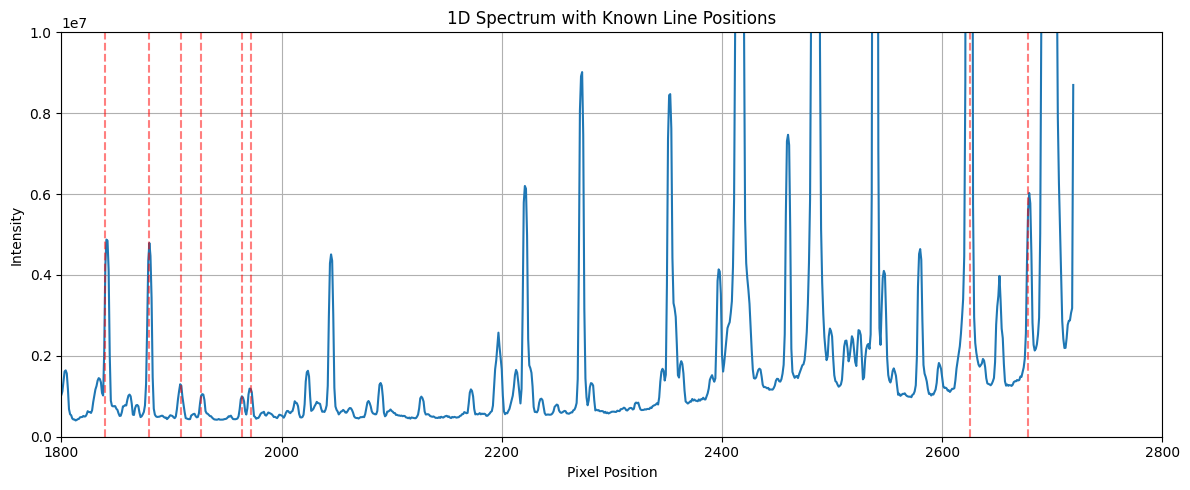

In [149]:
pixels_solution = np.array([210, 306, 435, 495, 512,540, 643,755,777,808,822,927,955,985,1005,1240,1270,1338,1422,
                            1497,1785, 1793,1840,1880,1909,1927,1964,1972,2625,2678])
wavelength_solution = np.array([3719.935, 3859.400, 4045.450,4131.830, 4158.590, 4199.860, 4348.064,4510.733,
                                4545.080, 4589.900, 4609.560,4764.890, 4806.070,4847.820,4879.900, 5227.300,
                                5269.650,5371.489,5496.210, 5606.732,6074.338,6096.1630,6163.594,6266.495,
                               6304.850,6334.428,6382.991 ,6402.246,6965.4300,7032.4127 ])#7383.980, 7514.651])
wavelength_label = np.array(["FeI", "FeI", "FeI" ,"ArII","ArI", "ArI","FeI", "ArII", "ArII", "AII","AII","AII","AII",
                             "AII","AII","AII", "AII","FeI","FeI","FeI", "AI","NeI","NeI","NeI","NeI","NeI","NeI",
                            "NeI","NeI","AI"])

plot_wavelength_pixel_solution(
    comp_spectrum_1d,
    pixels_solution,
    wavelength_solution,
    wavelength_labels=wavelength_label,
    annotate=False,
    invert_x=False,
    xlim=(1800,2800),
    ylim=(0,10e6)
)


Polynomial coefficients: [-1.68082161e-07  6.07623135e-04  8.74859751e-01  3.55690971e+03]


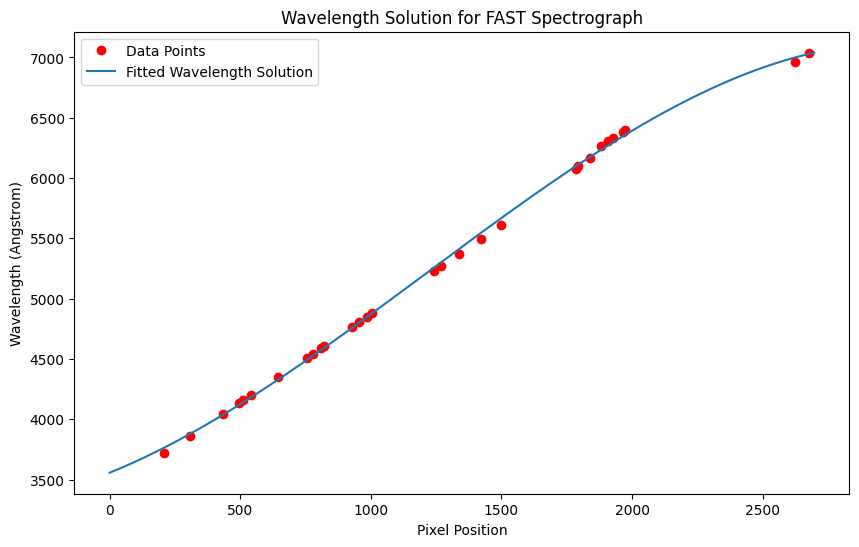

In [150]:
# Define a polynomial function to fit the data
from scipy.optimize import curve_fit

def polynomial(x, a, b, c, d):
    return  a * x**3 + b * x**2 + c * x + d

# Fit the polynomial to the data
popt, pcov = curve_fit(polynomial, pixels_solution, wavelength_solution,)
a, b, c, d = popt

# Print out the polynomial coefficients
print("Polynomial coefficients:", popt)

# Generate wavelengths using the polynomial solution across the full pixel range
pixel_range = np.arange(0, max(pixels_solution) +20)
calibrated_wavelengths = polynomial(pixel_range, *popt)

# Plot the original data points and the fitted polynomial solution
plt.figure(figsize=(10, 6))
plt.plot(pixels_solution, wavelength_solution, 'ro', label='Data Points')
plt.plot(pixel_range, calibrated_wavelengths, label='Fitted Wavelength Solution')
plt.xlabel('Pixel Position')
plt.ylabel('Wavelength (Angstrom)')
plt.title('Wavelength Solution for FAST Spectrograph')
plt.legend()
plt.show()

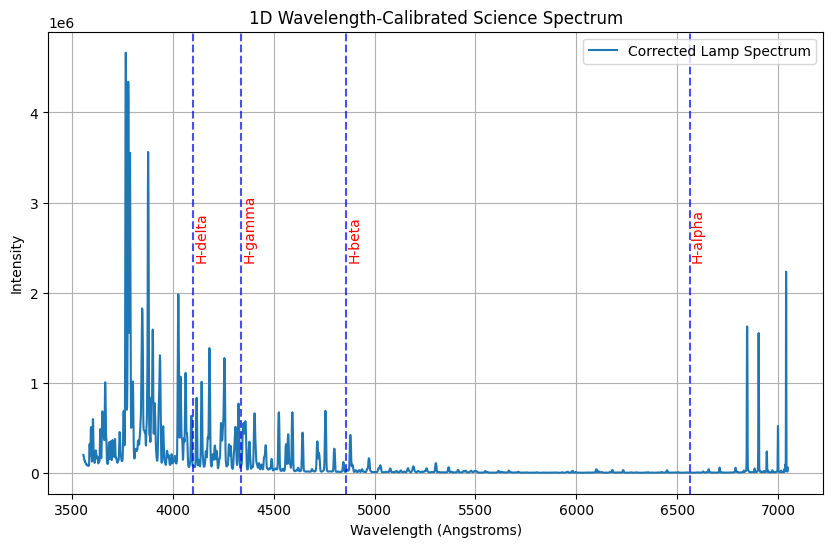

In [151]:
coeffs = [-1.68082148e-07, 6.07623080e-04, 8.74859821e-01, 3.55690968e+03]

def apply_wavelength_solution(pixels, coeffs):
    return np.polyval(coeffs, pixels)



science_file = os.path.join("drive/MyDrive/Astro_Data/0062.3C273.fits")

corrected_science_image, raw_science_image = process_science_image(science_file, combined_bias, combined_flat)
science_spectrum_1d = np.sum(corrected_science_image, axis=0)
pixels = np.arange(len(comp_spectrum_1d))

wavelength_solution_adjusted = apply_wavelength_solution(pixels, coeffs)
wavelength_solution_adjusted_science = apply_wavelength_solution(pixels, coeffs)

# Define only the H-alpha spectral line
lines = {
    'H-alpha': 6563,
    'H-beta': 4861,
    'H-gamma': 4340,
    'H-delta': 4101
}

def plot_1d_spectrum_with_lines(wavelengths, spectrum_1d):
    plt.figure(figsize=(10, 6))

    # Plot the 1D spectrum
    plt.plot(wavelengths, spectrum_1d, label='Corrected Lamp Spectrum')
    plt.xlabel('Wavelength (Angstroms)')
    plt.ylabel('Intensity')
    plt.title('1D Wavelength-Calibrated Science Spectrum')
    plt.grid(True)

    # Plot the vertical line for the H-alpha line
    for line_name, line_wavelength in lines.items():
        plt.axvline(x=line_wavelength, color='blue', linestyle='--', alpha=0.7)
        plt.text(line_wavelength +5, np.max(spectrum_1d) * 0.5, line_name, rotation=90, verticalalignment='bottom', color='red')

    plt.legend()
    plt.show()

# Plot the 1D spectrum with only the H-alpha line using the wavelength solution
plot_1d_spectrum_with_lines(wavelength_solution_adjusted, comp_spectrum_1d)

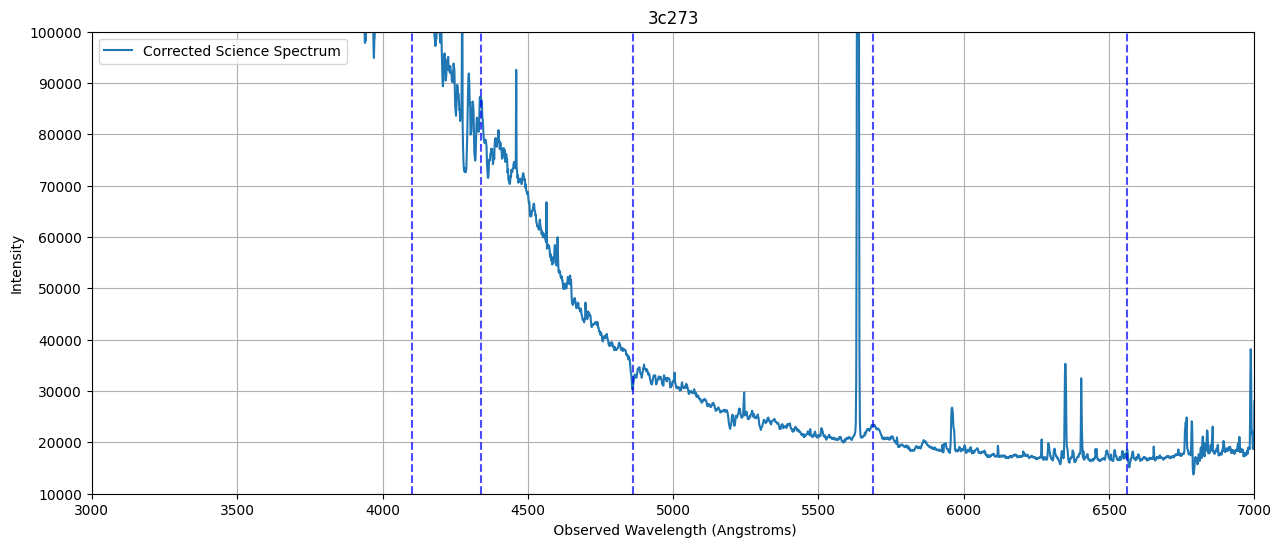

In [152]:
def plot_1d_spectrum_with_lines(wavelengths, spectrum_1d):
    plt.figure(figsize=(15, 6))

    # Plot the 1D spectrum
    plt.plot(wavelengths, spectrum_1d, label='Corrected Science Spectrum')
    plt.xlabel(' Observed Wavelength (Angstroms)')
    plt.ylabel('Intensity')
    plt.title('3c273')
    plt.grid(True)

    # Plot the vertical line for the H-alpha line
    for line_name, line_wavelength in lines.items():
        plt.axvline(x=line_wavelength, color='blue', linestyle='--', alpha=0.7)
        #plt.text(line_wavelength +5, np.max(spectrum_1d) * 0.5, line_name, rotation=90, verticalalignment='bottom', color='red')

        #plt.axvline(color='blue', linestyle='--', alpha=0.7, x=4876)
    plt.axvline(x=5688, color='blue', linestyle='--', alpha=0.7)
    plt.xlim(3000, 7000)
    plt.ylim(10000, 100000)
    plt.legend()
    plt.show()



plot_1d_spectrum_with_lines(wavelength_solution_adjusted_science, science_spectrum_1d)

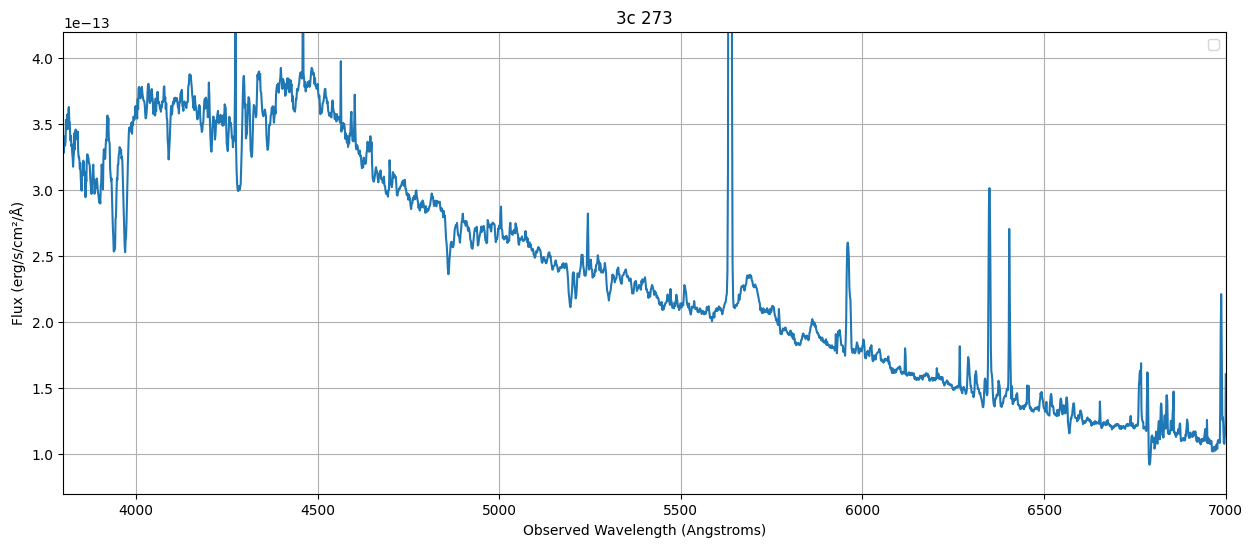

In [153]:
def plot_1d_spectrum_with_lines(wavelengths, spectrum_1d, ylimit=None):
    plt.figure(figsize=(15, 6))

    # Plot the 1D spectrum
    plt.plot(wavelengths, spectrum_1d)
    plt.xlabel('Observed Wavelength (Angstroms)')
    plt.ylabel('Flux (erg/s/cm²/Å)')
    plt.title('3c 273')
    plt.grid(True)

    # Plot the vertical line for the H-alpha line
    #for line_name, line_wavelength in lines.items():
        #plt.axvline(x=line_wavelength, color='red', linestyle='--', alpha=0.7)

    plt.xlim(3800, 7000)

    # If ylimit is provided, use it for the y-axis limits
    if ylimit:
        plt.ylim(ylimit)

    plt.legend()
    plt.show()

    # 1. Apply the same smoothed sensitivity function
science_flux_calibrated = science_spectrum_1d * sensitivity_smoothed

# 2. Plot the flux-calibrated spectrum with custom y-limits
plot_1d_spectrum_with_lines(wavelength_solution_adjusted_science, science_flux_calibrated, ylimit=(0.07e-12, 0.42e-12))

# 3. (Optional) Save to file
np.savetxt('flux_calibrated_3c273.txt',
           np.column_stack((wavelength_solution_adjusted_science, science_flux_calibrated)),
           header='Wavelength (Angstroms)    Flux (erg/s/cm^2/Angstrom)')


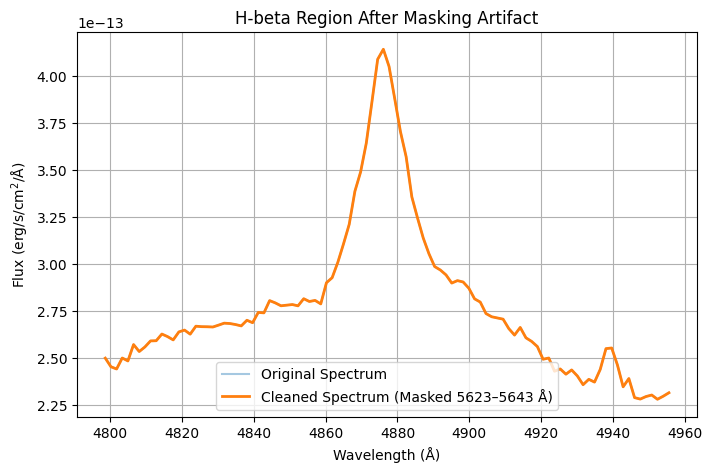

In [154]:
from scipy.interpolate import interp1d

# Define the wavelength range to mask
mask_range_min = 5620
mask_range_max = 5645

# Get indices of wavelengths to mask
bad_mask = (wavelength_hbeta >= mask_range_min) & (wavelength_hbeta <= mask_range_max)
good_mask = ~bad_mask

# Interpolate over the good data points
interpolator = interp1d(wavelength_hbeta[good_mask],
                        spectrum_hbeta[good_mask],
                        kind='linear',
                        fill_value='extrapolate')

# Create cleaned spectrum
spectrum_hbeta_cleaned = spectrum_hbeta.copy()
spectrum_hbeta_cleaned[bad_mask] = interpolator(wavelength_hbeta[bad_mask])

# Plot original and cleaned spectra
plt.figure(figsize=(8, 5))
plt.plot(wavelength_hbeta, spectrum_hbeta, label='Original Spectrum', alpha=0.4)
plt.plot(wavelength_hbeta, spectrum_hbeta_cleaned, label='Cleaned Spectrum (Masked 5623–5643 Å)', linewidth=2)
plt.xlabel('Wavelength (Å)')
plt.ylabel(r'Flux (erg/s/cm$^2$/Å)')
plt.title('H-beta Region After Masking Artifact')
plt.grid(True)
plt.legend()
plt.show()


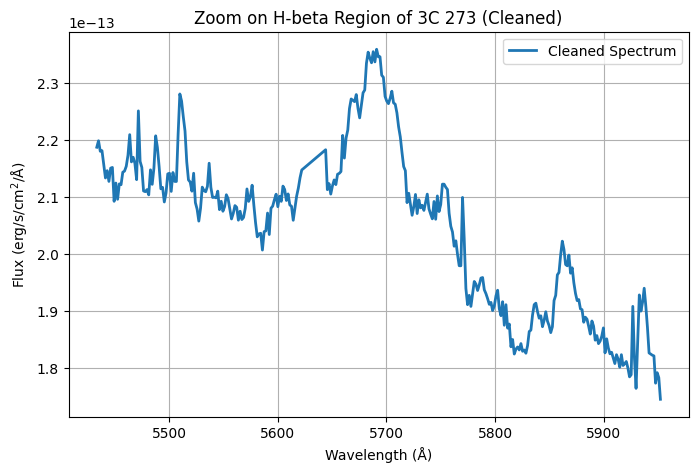

In [155]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# Define the zoom-in region around H-beta
hbeta_center = 4861 * (1 + 0.171)  # Apply redshift correction for 3C 273
window = 260  # +/- 70 Å window

# Find indices corresponding to the H-beta region
mask = (wavelength_solution_adjusted_science > hbeta_center - window) & \
       (wavelength_solution_adjusted_science < hbeta_center + window)

wavelength_hbeta = wavelength_solution_adjusted_science[mask]
spectrum_hbeta = science_flux_calibrated[mask]

# Mask and interpolate over the spike at 5623–5643 Å
bad_mask = (wavelength_hbeta >= 5623) & (wavelength_hbeta <= 5643)
good_mask = ~bad_mask

interpolator = interp1d(wavelength_hbeta[good_mask],
                        spectrum_hbeta[good_mask],
                        kind='linear',
                        fill_value='extrapolate')

spectrum_hbeta_cleaned = spectrum_hbeta.copy()
spectrum_hbeta_cleaned[bad_mask] = interpolator(wavelength_hbeta[bad_mask])

# Plot only the cleaned H-beta region
plt.figure(figsize=(8, 5))
plt.plot(wavelength_hbeta, spectrum_hbeta_cleaned, label='Cleaned Spectrum', linewidth=2)
plt.xlabel('Wavelength (Å)')
plt.ylabel(r'Flux (erg/s/cm$^2$/Å)')
plt.title('Zoom on H-beta Region of 3C 273 (Cleaned)')
plt.grid(True)
plt.legend()
plt.show()



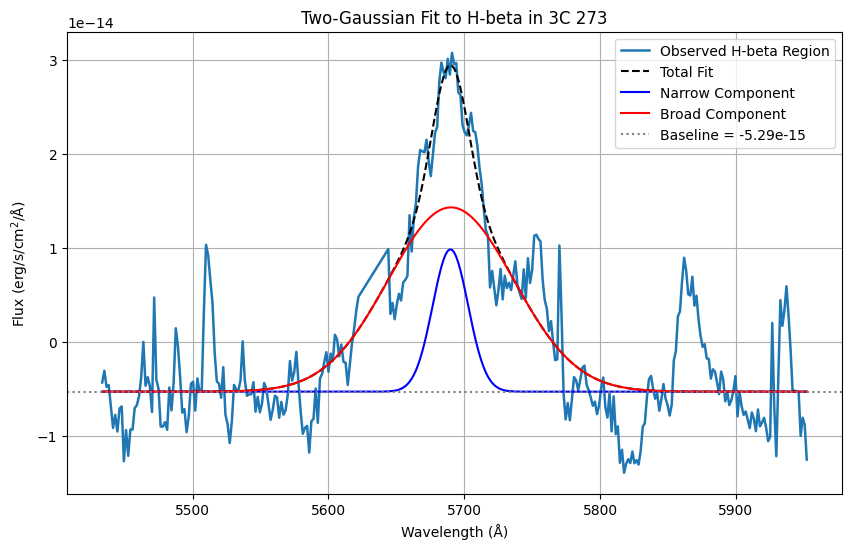

In [156]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

# Define model for emission lines
def two_gaussians_plus_baseline(wavelength, amp1, cen1, sigma1, amp2, cen2, sigma2, baseline):
    gauss1 = amp1 * np.exp(-(wavelength - cen1)**2 / (2 * sigma1**2))  # narrow
    gauss2 = amp2 * np.exp(-(wavelength - cen2)**2 / (2 * sigma2**2))  # broad
    return gauss1 + gauss2 + baseline

# Observed H-beta center for z=0.171
hb_obs = 4861 * (1 + 0.171)

# Set variables for clarity
wave_fit = wavelength_hbeta
flux_fit = spectrum_hbeta_cleaned

# Estimate and subtract the continuum:
def estimate_continuum(wavelength, flux):
    # Fit a linear continuum model to regions away from the emission line
    mask = (wavelength < 4820) | (wavelength > 4900)  # Mask the region around H-beta (assumed)
    continuum_params = np.polyfit(wavelength[mask], flux[mask], 1)  # Fit a linear function
    continuum = np.polyval(continuum_params, wavelength)  # Evaluate the continuum over the entire range
    return continuum

# Estimate and subtract continuum from the spectrum
continuum = estimate_continuum(wave_fit, flux_fit)
flux_fit_subtracted = flux_fit - continuum  # Subtracted spectrum

# Initial parameter guesses for emission line fitting
amp1_guess = np.max(flux_fit_subtracted)
cen1_guess = hb_obs
sigma1_guess = 2

amp2_guess = np.max(flux_fit_subtracted) / 2
cen2_guess = hb_obs
sigma2_guess = 10

baseline_guess = -0.8  # <-- Set baseline guess to -0.8

# Initial guess for parameters
initial_guess = [amp1_guess, cen1_guess, sigma1_guess, amp2_guess, cen2_guess, sigma2_guess, baseline_guess]

# Perform fit with increased maxfev
popt, pcov = curve_fit(two_gaussians_plus_baseline, wave_fit, flux_fit_subtracted, p0=initial_guess, maxfev=5000)

# Extract parameters
amp1, cen1, sigma1, amp2, cen2, sigma2, baseline = popt

# Build fit curves
fit_curve = two_gaussians_plus_baseline(wave_fit, *popt)
gauss_narrow = amp1 * np.exp(-(wave_fit - cen1)**2 / (2 * sigma1**2))
gauss_broad = amp2 * np.exp(-(wave_fit - cen2)**2 / (2 * sigma2**2))

# Plot result
plt.figure(figsize=(10, 6))
plt.plot(wave_fit, flux_fit_subtracted, label='Observed H-beta Region', linewidth=1.8)
plt.plot(wave_fit, fit_curve, '--', color='black', label='Total Fit')
plt.plot(wave_fit, gauss_narrow + baseline, label='Narrow Component', color='blue')
plt.plot(wave_fit, gauss_broad + baseline, label='Broad Component', color='red')
plt.axhline(baseline, color='gray', linestyle=':', label=f'Baseline = {baseline:.2e}')
plt.xlabel('Wavelength (Å)')
plt.ylabel(r'Flux (erg/s/cm$^2$/Å)')
plt.title('Two-Gaussian Fit to H-beta in 3C 273')
plt.legend()
plt.grid(True)
plt.show()





In [157]:
# --- Calculate FWHM of the Broad Component (sigma2 comes from the broad Gaussian)

# FWHM in Angstroms (Gaussian relation: FWHM = 2.355 * sigma)
fwhm_angstroms = 2.355 * sigma2

# Rest-frame wavelength of H-beta
hb_rest = 4861  # Angstroms

# Convert FWHM from Angstroms to km/s using Doppler formula
fwhm_kms = (fwhm_angstroms / hb_rest) * 3e5  # 3e5 km/s is speed of light

# Print results
print(f"Broad Component FWHM ≈ {fwhm_angstroms:.2f} Å ≈ {fwhm_kms:.0f} km/s")

Broad Component FWHM ≈ 108.87 Å ≈ 6719 km/s


In [158]:
# 1. Define a window around 5100 Å rest-frame
window_center = 5100 * (1 + 0.171)  # Redshifted center for 3C 273
window_width = 50  # +/- 50 Å

mask_5100 = (wavelength_solution_adjusted_science > window_center - window_width) & \
            (wavelength_solution_adjusted_science < window_center + window_width)

wave_5100 = wavelength_solution_adjusted_science[mask_5100]
flux_5100 = science_flux_calibrated[mask_5100]

# 2. Average flux density f_lambda (in erg/s/cm²/Å)
f_lambda_5100 = np.mean(flux_5100)

# 3. Luminosity Distance D_L for 3C 273
DL_Mpc = 749  # Mpc
DL_cm = DL_Mpc * 3.086e24  # convert to cm

# 4. Monochromatic luminosity at 5100 Å
L_5100 = 4 * np.pi * DL_cm**2 * f_lambda_5100  # erg/s/Å

print(f"f_lambda(5100) = {f_lambda_5100:.2e} erg/s/cm^2/Å")
print(f"L_lambda(5100) = {L_5100:.2e} erg/s/Å")


f_lambda(5100) = 1.88e-13 erg/s/cm^2/Å
L_lambda(5100) = 1.26e+43 erg/s/Å


In [159]:
# Black hole mass calculation

# Constants from empirical relation
a = 6.91
b = 0.5

# Compute log values
log_L = np.log10(L_5100 / 1e44)
log_FWHM = np.log10(fwhm_kms / 1000)

# Final formula
log_M_BH = a + b * log_L + 2 * log_FWHM
M_BH = 10**log_M_BH

print(f"Log(M_BH/M_sun) = {log_M_BH:.2f}")
print(f"M_BH ≈ {M_BH:.2e} M_sun")

# Include 0.4 dex uncertainty
dex_uncertainty = 0.4

# Upper and lower limits in log space
log_M_BH_upper = log_M_BH + dex_uncertainty
log_M_BH_lower = log_M_BH - dex_uncertainty

# Convert back to linear space
M_BH_upper = 10**log_M_BH_upper
M_BH_lower = 10**log_M_BH_lower

# Report results
print(f"Log(M_BH/M_sun) = {log_M_BH:.2f} ± {dex_uncertainty:.1f} dex")
print(f"M_BH ≈ ({M_BH:.2e}) M_sun")
print(f"Range: ({M_BH_lower:.2e} - {M_BH_upper:.2e}) M_sun")

Log(M_BH/M_sun) = 8.12
M_BH ≈ 1.30e+08 M_sun
Log(M_BH/M_sun) = 8.12 ± 0.4 dex
M_BH ≈ (1.30e+08) M_sun
Range: (5.19e+07 - 3.28e+08) M_sun


In [160]:
# Constants in CGS
c = 2.998e10  # Speed of light in cm/s
eta = 0.1  # Radiative efficiency
Msun_g = 1.989e33  # Solar mass in grams
sec_per_year = 3.154e7  # Seconds per year

# Given L5100 for 3C 273 (in erg/s), from the previous calculation
L5100 = 1.26e43

# Bolometric correction (typical for AGN like 3C 273)
BC = 5  # Bolometric correction factor, often used for Seyferts and quasars
L_bol = L5100 * BC  # Bolometric luminosity in erg/s

# Accretion rate in g/s
mdot_g_per_s = L_bol / (eta * c**2)

# Convert to solar masses per year
mdot_msun_per_year = (mdot_g_per_s / Msun_g) * sec_per_year

# Print the result
print(f"Accretion Rate for 3C 273 ≈ {mdot_msun_per_year:.8f} M_sun/year")


Accretion Rate for 3C 273 ≈ 0.01111487 M_sun/year
